# ROMS River Forcing File  
The purpose of this script it to find the rivers in the Beaufort Sea shelf grid, then load in and format river data for each river, and write all of that information to a river forcing file.

<font color='red'>  This script has been updated to make a river forcing file for 2020. 


For the Alaskan Beaufort Sea shelf, there are the following rivers that should be accounted for in the model if possible (pulled from https://www.openstreetmap.org/search?whereami=1&query=69.62926%2C-141.26456#map=13/69.6293/-141.2646): 
    
    - Kalikpik River (70.4442, -151.9452), 17.6 m
    - Tingmeachsiovik River (70.4096, -151.3608), 9 m
    - Fish Creek (70.3786, -151.3608), 405.9 m
    - Colville River (70.4517, -150.3589), 3500 m
    - Sakonowyak River (70.4452, -149.0206), 733.3 m
    - Kuparik River (splits into two rivers near coast):
        - Kukpuk River (70.4152, -148.8956), 530 m 
        - Kuparuk River (70.3924, -148.8393), 300 m
    - Fawn Creek (70.4099, -148.7271), 300 m
    - Putuligayuk River (70.3113, -148.4792), 409 m
    - Sagavanirktok River (70.2924, -148.1712), 2000 m 
    - Shaviovik River (70.1803, -147.2856), 5 m
    - Canning River (splits into two neat coast):  
        - Staines River (70.1419, -145.9989), 892.9 m
        - Canning River (70.061, -145.5553), 1070 m
    - Katakturuk River (splits into two near coast but keeps the same name):  
        - (69.9814, -145.0489), 4.5 m
        - (69.976, -144.9958), 265 m
    - Marsh Creek (69.9787, -144.7938), 4.5 m
    - Carter Creek (69.9671, -144.7036), 9 m
    - Sadlerochit River (70.0226, -144.4347), 17.6 m
    - Hulahula River (70.0654, -144.085), 790 m
    - Okpilak River (70.0483, -143.9978), 35 m
    - (no name) (), (across from Barter Island)  
    - Jago River (70.1088, -143.2918), 921 m
    - Niguanak River (70.058, -142.997), 4.6 m
    - Siksik River (69.9501, -142.4938), 176.5 m
    - Sikrelurak River (69.9343, -142.4455), 17.6 m
    - Angun River (69.9326, -142.4147), 17.6 m
    - Kogotpak River (69.8621, -142.2647), 17.6 m
    - Ailchilik River (69.8442, -142.1021), 35.3 m
    - Egaksrak River (69.8181, -142.044), 17.6 m
    - Kongakut River (69.7858, -141.7429), 70.6 m
    - (no name) (69.6501, -141.4161), 17.6 m
    - Turner River (69.6404, -141.3945), 17.6 m 
    - (no name) (69.6259, -141.3565), 35.3 m
    - (no name) (69.62926, -141.26456), 4.6 m

    
Our first approach will be to pull this data from the Feng et al. 2021 RADR dataset. Before loading in any river discahrge data, let's use the coordinates above to find where these rivers are in the grid.

Notes:
- Be sure to specify where the rivers are on the grid in terms of u and v points, NOT rho points 
- <font color='red'> Order of rivers in positional indices is based on order they appear in this notebook, NOT the order of the rivers geographically/above </font>
- In all of the plots, land is blue and ocean is green
- <font color='red'> From conversations with Marisa Repasch, it seems like (at least the Canning River) only has suspended mud and not suspended sand. Suspended sand concentrations will be set to zero and mud will be set to half of the total sediment discharge (so both mud classes are equally represented in riverine sediment). </font>
- River discharge values are pulled from the mean discharge from 1984 - 2018 for each day of year from the RADR (Feng et al. 2021) dataset

In [1]:
# Load in the packages
import numpy as np
import xarray as xr
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
from netCDF4 import Dataset
from cftime import num2date, date2num

In [2]:
# Load in the model grid
grid = xr.open_dataset('/Users/brun1463/Desktop/Research_Lab/Kaktovik_Alaska_2019/Code/Grids/KakAKgrd_shelf_big010_smooth006.nc')

In [3]:
# Read in/set some grid dimensions 
# Number of vertical layers
s_rho_len = 20

# Number of river cells 
len_river_cells = 21 # will need to know total up here; took out Fawn Creek since there are no data

In [4]:
# Make a time series to use that matches the time/frequency of the RADR data
# (daily from 1 July 2019 - 2 November 2019)
# Do daily for the period of the model run
time = np.arange(pd.datetime(2020,7,1,1,0,0), pd.datetime(2020,11,3,1,0,0), timedelta(days=1))
time = pd.to_datetime(time)
#print(time)

# Conver this to seconds since 2000-01-01 00:00:00
time_tmp = ((time[:] - datetime(1999,12,31)).total_seconds() - 86400)
#print(time_tmp[-1])

# Find the length 
time_tmp_len = len(time_tmp)
print(time_tmp_len)

125


/var/folders/hb/5f7j400j20j7tz7b15m1ysmh0000gn/T/ipykernel_54930/1600815157.py:4: FutureWarning: The pandas.datetime class is deprecated and will be removed from pandas in a future version. Import from datetime module instead.
  time = np.arange(pd.datetime(2020,7,1,1,0,0), pd.datetime(2020,11,3,1,0,0), timedelta(days=1))


In [5]:
# Calculate river_Vshape beforehand
# This is the fraction of river discharge to put in each vertical cell
# and it should be weighted by the thickness of the cell instead of evenly
# distributed because this may (and did most likely) cause momentum to blow up

# Load in previous model output to read in the thicnkesses
# or ROMS_hplus_zeta if it is in there
model_out = xr.open_dataset('/Users/brun1463/Desktop/Research_Lab/Kaktovik_Alaska_2020/Model_Inputs/Forcing_files/Final_bryclm_conds/Attempt001/ROMS_grid_depth_hpluszeta_2020_003.nc')

# Read in the cell thickness from previous model output (s_rho, eta_rho, xi_rho)
# Use thicknesses from time 0
# First read in z_w
z_w = model_out.z_w[0,:,:,:].values

# Use z_w to get cell thickness
#cell_thick = abs(z_w[1:,:,:]) - abs(z_w[0:-1,:,:])
cell_thick = z_w[1:,:,:] - z_w[0:-1,:,:]

# Check this
print(len(cell_thick[:,200,200]))
print(cell_thick[:,200,200])
print(z_w[1,200,200])
print(z_w[0,200,200])
print(z_w[1,200,200] - z_w[0,200,200])
#print(abs(z_w[1,200,200]) - abs(z_w[0,200,200]))
                            
# Add up the cell thicknesses (eta_rho, xi_rho)
total_thick = np.sum(cell_thick, axis=0)
print(np.shape(total_thick))
                            
# Divide each layer by the total thickness to get the fraction (s_rho, eta_rho, xi_rho)
vshape_all = cell_thick/total_thick

# Is this uniform over the whole grid? If not, need to pull out each location for each river 
print(vshape_all[0,:,:])
#print(vshape_all[10,:,:])
#print(vshape_all[19,:,:])

# No, this is not uniform over space so will need to pull it out for each river

# Check that this adds up to 1
print(np.sum(vshape_all[:,200,200]))
print(np.sum(vshape_all[:,100,150]))
print(np.sum(vshape_all[:,200,80]))

# close enough I hope? They all round to 1

# Print the shape 
print(np.shape(vshape_all))

# Delete this file for memory sake
del(model_out)

20
[65.70848206 72.82378041 70.92791884 67.19657475 62.9259451  58.65596113
 54.74471184 51.51542573 49.26936157 48.23582632 48.50427865 49.98195442
 52.40366954 55.38627721 58.4901931  61.2419827  63.07570574 63.12322434
 59.55679155 44.61849141]
-1092.9880660439737
-1158.696548103701
65.7084820597272
(206, 608)
[[0.05337658 0.05337658 0.05337658 ... 0.05337658 0.05337658 0.05337658]
 [0.05337658 0.05337658 0.05337658 ... 0.05337658 0.05337658 0.05337658]
 [0.05337658 0.05337658 0.05337658 ... 0.05337658 0.05337658 0.05337658]
 ...
 [0.05622787 0.05622878 0.05623429 ... 0.05673282 0.05673214 0.05673163]
 [0.05623551 0.05622717 0.0562304  ... 0.05673321 0.05673262 0.05673212]
 [0.0562343  0.05623307 0.05624342 ... 0.05673341 0.0567331  0.05673245]]
0.9999999999999998
1.0000000000000002
1.0
(20, 206, 608)


In [6]:
# Read in data to use for the river temperature time series
# Use the same time series for all rivers
river_temp = xr.open_dataset('/Users/brun1463/Desktop/Research_Lab/Kaktovik_Alaska_2019/usgs_river_data/daily_mean_river_temp_kup_meade_combined.nc')
print(river_temp)

<xarray.Dataset>
Dimensions:                        (index: 125)
Coordinates:
  * index                          (index) datetime64[ns] 2019-07-01 ... 2019...
Data variables:
    __xarray_dataarray_variable__  (index) float64 ...


In [7]:
# Save the temperatures to use to an array
riv_temp = river_temp.__xarray_dataarray_variable__.values
print(riv_temp[0], riv_temp[-1])

12.513586956521738 0.18


In [8]:
# Set up the equation to use to calculate river sediment load
# Make a function to calculate river suspended sediment load 
# based on river discharge. This is currently set up to use 
# the equation for the Anaktuvuk basin from Lamb and Toniolo 2016.

def calc_river_ssc(Q):
    """
    This function takes river water discharge and
    calculates river suspended sediment load based
    on this discharge. The function is taken from
    equation D-2 of Gary Simoes 2008 'Appendix D: 
    Estimating Sediment Discharge'.
    
    The a and b values in the equation are 
    experimentally determined. For this function,
    the values are taken from the equation for 
    the Anaktuvuk River from Lamb and Toniolo 2016.
    
    Input(s)
    - Q = River water discharge (m3/s)
    
    Output(s)
    - ssc_tmp = suspended sediment discharge ()
    
    # Define some constants 
    # a = the intercept (from a log fit, see Gray Simoes)
    # b = the slope (from a log fit, see Gray Simoes)
    """
    # Define a and b from Lamb and Toniolo 2016
    a = 0.0199 # Change to Chandler
    b = 1.4811 # Change to Chandler
    
    # Calculate the river suspended sediment concentration
    ssc_tmp = a*((Q)**b)
    
    return(ssc_tmp)

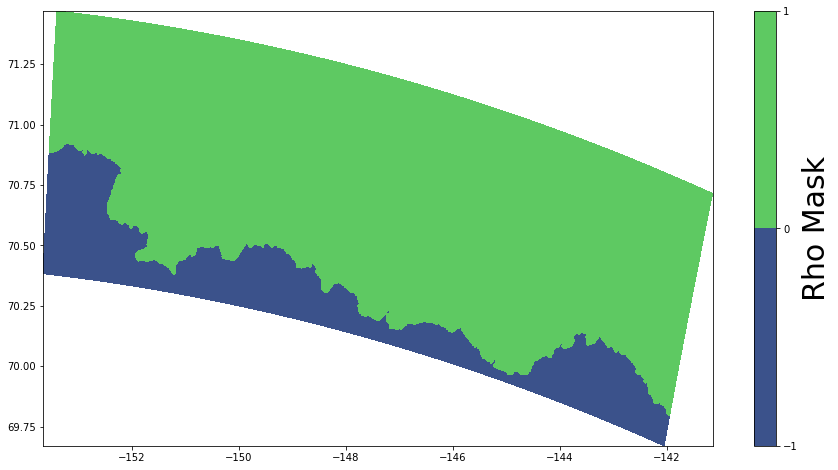

In [9]:
# Plot the grid with the mask to see what we're working with 
fig1, ax1 = plt.subplots(figsize=(15,8))
lev1 = np.arange(-1,2,1)
cs1 = ax1.contourf(grid.lon_rho.values, grid.lat_rho.values, grid.mask_rho.values, lev1)
cbar1 = plt.colorbar(cs1).set_label('Rho Mask', size=30)

In [10]:
# Make lists/arrays to hold the indices for the rivers 
# River identification number (ex: 1 = Kalikpik, 2 = T...)
#riv_id_list = []
riv_id_arr = np.empty((len_river_cells))

# Coordinates of river cells (all of them I think?)
#eta_riv_list = []
#xi_riv_list = []
eta_riv_arr = np.empty((len_river_cells))
xi_riv_arr = np.empty((len_river_cells))

# River transport for each river cell (same size and order as above is the goal)
#riv_transport_list = []
riv_transport_arr = np.empty((time_tmp_len, len_river_cells))

# River direction for each river cell (0 = u face, 1 = v face, 2 = w face)
#riv_direction_list = []
riv_direction_arr = np.empty((len_river_cells))

# River Vshape for each river cell (vertical distribution of water volume transport)
#riv_vshape_list = []
riv_vshape_arr = np.empty((s_rho_len, len_river_cells))

# River potential temperature (river_time, s_rho, river)
#riv_temp_list = []
riv_temp_arr = np.empty((time_tmp_len, s_rho_len, len_river_cells))

# River slainity (river_time, s_rho, river)
#riv_salt_list = []
riv_salt_arr = np.empty((time_tmp_len, s_rho_len, len_river_cells)) 

# River mud class 01 (one for each mud class)
riv_mud_01_arr = np.empty((time_tmp_len, len_river_cells))

# River mud class 02 (one for each mud class)
riv_mud_02_arr = np.empty((time_tmp_len, len_river_cells))

# River sand class 01 (one for each sand class)
riv_sand_01_arr = np.empty((time_tmp_len, len_river_cells))

# River sand class 02 (one for each sand class)
riv_sand_02_arr = np.empty((time_tmp_len, len_river_cells))

# River sand class 03 (one for each sand class)
riv_sand_03_arr = np.empty((time_tmp_len, len_river_cells))

# River flag (which tracers are on; 0 = none, 1 = temp, 2 = salt, 3 = both)
#riv_flag_list = []
riv_flag_arr = np.empty((len_river_cells))

In [11]:
print(riv_transport_arr.shape)

(125, 21)


In [12]:
# Read in the river discahrge data
mean_river_dis = xr.open_dataset('/Users/brun1463/Desktop/Research_Lab/Kaktovik_Alaska_2019/Feng_etal_River_data/radr_mean_rivers_in_grid_01.nc')
print(mean_river_dis)

<xarray.Dataset>
Dimensions:          (time: 366, river: 14)
Coordinates:
  * time             (time) float64 0.0 1.0 2.0 3.0 ... 362.0 363.0 364.0 365.0
  * river            (river) float64 1.0 2.0 3.0 4.0 5.0 ... 11.0 12.0 13.0 14.0
Data variables:
    river_transport  (time, river) float64 ...
Attributes:
    rivers:       (1) Kalikpik, (2) Fish Creek, (3) Colville, (4) Sakonowyak,...
    title:        River Discharge For Rivers in Kaktovik Shelf Grid
    type:         Beaufort Shelf River Discharge
    Institution:  University of Colorado Boulder, Dept. of Atmospheric and Oc...
    Source:       Artifical (for now)
    date:         2023-03-13 15:01:43.139026


In [13]:
# Check time 
print(mean_river_dis.time[182].values)
print(mean_river_dis.time[306].values)

182.0
306.0


## Kalikpik River 
Location: (-151.9452, 70.4442)  
Width: 17.6 m (use one cell)

In [14]:
# Find this river in the mean discharge dataset
print(mean_river_dis.rivers)

(1) Kalikpik, (2) Fish Creek, (3) Colville, (4) Sakonowyak, (5) Kukpuk, (6) Kuparuk, (7) Putuligayuk, (8) Sagavanirktok, (9) Staines (10) Canning, (11) Katakturuk, (12) Hulahula, (13) Jago, (14) Siksik


In [15]:
# Kalikpik River (-151.9452, 70.4442), 17.6 m (use one cell)
# Set the number of cells it will take 
len_river_cells_kal = 1

# Find it manually 
eta_kal_idx = 20
xi_kal_idx = 86

# Needs to be on u or v point, depending what makes sense here
print('Kalikpik Lat u: ', grid.lat_u[eta_kal_idx, xi_kal_idx].values)
print('Kalikpik Lon u: ', grid.lon_u[eta_kal_idx, xi_kal_idx].values)

Kalikpik Lat u:  70.43682485237976
Kalikpik Lon u:  -151.9325754528886


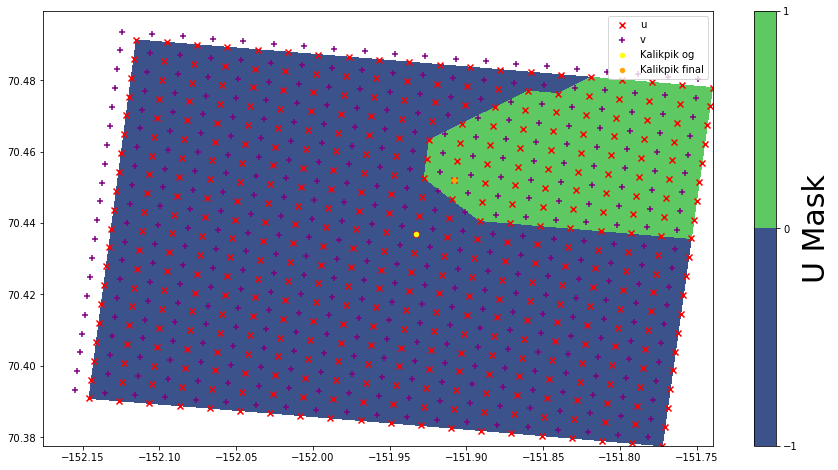

In [16]:
# Make a plot that is a scatter plot of u and v points 
# Plot this point on the grid
# Zoom in to see if we are in the mask
fig2, ax2 = plt.subplots(figsize=(15,8))
cs2 = ax2.contourf(grid.lon_u[eta_kal_idx-10:eta_kal_idx+10, xi_kal_idx-10:xi_kal_idx+10].values, 
                    grid.lat_u[eta_kal_idx-10:eta_kal_idx+10, xi_kal_idx-10:xi_kal_idx+10].values, 
                    grid.mask_u[eta_kal_idx-10:eta_kal_idx+10, xi_kal_idx-10:xi_kal_idx+10].values, lev1)
ax2.scatter(grid.lon_u[eta_kal_idx-10:eta_kal_idx+10, xi_kal_idx-10:xi_kal_idx+10].values, 
            grid.lat_u[eta_kal_idx-10:eta_kal_idx+10, xi_kal_idx-10:xi_kal_idx+10].values,
            color='red', marker='x', label='u')

ax2.scatter(grid.lon_v[eta_kal_idx-10:eta_kal_idx+10, xi_kal_idx-10:xi_kal_idx+10].values, 
            grid.lat_v[eta_kal_idx-10:eta_kal_idx+10, xi_kal_idx-10:xi_kal_idx+10].values,
            color='purple', marker='+', label='v')


# Kalikpik
ax2.scatter(grid.lon_u[eta_kal_idx, xi_kal_idx].values, grid.lat_u[eta_kal_idx, xi_kal_idx].values, 
            marker='.', s=80, color='yellow', label='Kalikpik og')

eta_kal_idx_test = 23 #22
xi_kal_idx_test = 87

ax2.scatter(grid.lon_u[eta_kal_idx_test, xi_kal_idx_test].values, 
            grid.lat_u[eta_kal_idx_test, xi_kal_idx_test].values, 
            marker='.', s=80, color='orange', label='Kalikpik final')
ax2.legend()

cbar2 = plt.colorbar(cs2).set_label('U Mask', size=30)

In [17]:
# Check that this spot is in the mask
print(grid.mask_u[eta_kal_idx_test,xi_kal_idx_test].values)
print(grid.mask_u[eta_kal_idx_test,xi_kal_idx_test+1].values)

# If so, save it to the list of river indices 
eta_riv_arr[0] = eta_kal_idx_test
xi_riv_arr[0] = xi_kal_idx_test

1.0
1.0


In [18]:
# Set the river_direction
# "river runoff grid-cell face flag"
# where river_direction:flag_values = "0, 1, 2" 
# river_direction:flag_meanings = "flow across u-face, flow across v-face, flow across w-face"

# Since the Kalikpik River is set to flow across a u face, make this value 0
riv_dir_kal = 0

# Add this to the array
riv_direction_arr[0] = riv_dir_kal

In [19]:
# Set river_transport which is the direction of the flow across the u or v face
# This is also where we put "river runoff vertically integrated mass transport"
# river_transport(river_time, river)
# ... is that discharge? I think so ...

# For Kalikpik, we want sign to be positive since we are 
# adding water to the cell to the right 
# Make a fake time series
#Q_kal = np.full((time_tmp_len), 1000) # m3/s

# Replace this fake time series with real data
Q_kal = (mean_river_dis.river_transport[182:307,0].values)/len_river_cells_kal


# Add this to the array
riv_transport_arr[:,0] = Q_kal

In [20]:
# print(mean_river_dis.river_transport[182:307,0].values)
# print(time_tmp_len)
# print(mean_river_dis.river_transport[306,0].values)

In [21]:
# Set river_vshape
# "sets the fractional distribution of the river_transport 
# among the vertical cells and must sum to 1.0 over the vertical"
# "If the river source is in shallow water several grid cells up a 
# river tributary then a simple uniform vertical distribution 
# (all river_Vshape values = 1/s_rho) usually works well"

# Since the Kalikpik River is in shallow water and we have no preference,
# do uniform distribution over all depths 
#riv_vshape_kal = np.full((s_rho_len), 1/s_rho_len)

# Read in the vshape for this cell
# Use the indices from above - these are u/v indices but v_shape 
# is n terms of rho indices but hopefully they are close enough 
# that it doesn't matter too much but keep note of this 
riv_vshape_kal = vshape_all[:, eta_kal_idx_test, xi_kal_idx_test]

# Add this to the array
riv_vshape_arr[:,0] = riv_vshape_kal

In [22]:
# Set river runoff potential temperature 
# river_temp(river_time, s_rho, river) 
# river_temp:long_name = "river runoff potential temperature" 
# river_temp:units = "Celsius" 
# river_temp:time = "river_time" 

# This looks like it can vary vertically and can be a timeseries 
#riv_temp_kal = np.full((time_tmp_len, s_rho_len), 11) 
# Make this the same in each layer 
riv_temp_kal = np.empty((time_tmp_len, s_rho_len))
for i in range(s_rho_len):
    riv_temp_kal[:,i] = riv_temp

# Add this to the array
riv_temp_arr[:,:,0] = riv_temp_kal

In [23]:
# Set the river runoff salinity
# river_salt(river_time, s_rho, river) 
# river_salt:long_name = "river runoff salinity" 
# river_salt:time = "river_time"
# units: PSS (nondimensional)

# Just like temp, this can vary vertically and over time
riv_salt_kal = np.full((time_tmp_len, s_rho_len), 0) 

# Add this to the array
riv_salt_arr[:,:,0] = riv_salt_kal

In [24]:
# Set the river mud
# 'river_mud_'                                       ! Input
#   'river runoff suspended sediment concentration'
#   'kilogram meter-3'                               ! [kg/m3]
#   'river_sediment, scalar, series'
#   'river_time'

# --- Guesstimate Version ---
# # 10 kg/s / discharge m3/s = kg/m3, picking 10 as a random average 
# # for all rivers and all sediment classes
# # mud class 01
# riv_mud_01_kal = 10 / Q_kal 
# #riv_mud_01_kal = np.full((time_tmp_len), 0.00001)

# # mud class 02
# riv_mud_02_kal = 10 / Q_kal
# #riv_mud_02_kal = np.full((time_tmp_len), 0.00001)


# ---Lamb and Toniolo 2016 Version---
riv_mud_kal_tmp = calc_river_ssc(Q_kal)
# Convert output from mg/L to kg/m3
riv_mud_kal = riv_mud_kal_tmp/1000

# Divide the total river sediment discharge by two 
# so that half belongs to each mud class
riv_mud_01_kal = riv_mud_kal/2
riv_mud_02_kal = riv_mud_kal/2


# Add these to the arrays
riv_mud_01_arr[:,0] = riv_mud_01_kal
riv_mud_02_arr[:,0] = riv_mud_02_kal

In [25]:
# # Check to see if this worked
# print('Q_kal: ', np.shape(Q_kal))
# print(Q_kal[100])
# print('riv_mud_kal: ', np.shape(riv_mud_kal))
# print(riv_mud_kal_tmp[100])
# print(riv_mud_kal[100])
# print('check math: ', 0.0199*((Q_kal[100])**1.4811))
# print('check division: ', riv_mud_01_kal[100])
# print('check division 02: ', riv_mud_02_kal[100])

# # It worked!

In [26]:
# Set the river sand
# 'river_sand_'                                      ! Input
#   'river runoff suspended sediment concentration'
#   'kilogram meter-3'                               ! [kg/m3]
#   'river_sediment, scalar, series'
#   'river_time'

# --- Guesstimate Version ---
# 10 kg/s / discharge m3/s = kg/m3, picking 10 as a random average 
# for all rivers and all sediment classes
# *Set all of these to 0 since sand might be too big to be carried by the river*

# sand class 01
riv_sand_01_kal = 0 / Q_kal
#riv_sand_01_kal = np.full((time_tmp_len), 0.0001)

# sand class 02
riv_sand_02_kal = 0 / Q_kal
#riv_sand_02_kal = np.full((time_tmp_len), 0.0001)

# sand class 03
riv_sand_03_kal = 0 / Q_kal
#riv_sand_03_kal = np.full((time_tmp_len), 0.0)

# Add this to the array
riv_sand_01_arr[:,0] = riv_sand_01_kal
riv_sand_02_arr[:,0] = riv_sand_02_kal
riv_sand_03_arr[:,0] = riv_sand_03_kal

In [27]:
# Set the river id number
# This number will match the one in the info for the netcdf
# Kailkpik
riv_id_kal = 1

# Add this to the array
riv_id_arr[0] = riv_id_kal

In [28]:
# Set the river flag ('river runoff tracer flag')
# rdir.flag_values = '0, 1, 2, 3'
# rdir.flag_meanings = 'all tracers are off, only temperature is on, 
# only salinity is on, both temperature and salinity are on'
riv_flag_kal = 3

# Add this to the array
riv_flag_arr[0] = riv_flag_kal

### Colville River 
Location: (70.4517, -150.3589)  
Width: 3500 m

In [29]:
# Find this river in the mean discharge dataset
print(mean_river_dis.rivers)

(1) Kalikpik, (2) Fish Creek, (3) Colville, (4) Sakonowyak, (5) Kukpuk, (6) Kuparuk, (7) Putuligayuk, (8) Sagavanirktok, (9) Staines (10) Canning, (11) Katakturuk, (12) Hulahula, (13) Jago, (14) Siksik


In [30]:
# Colville River (70.4517, -150.3589), 3500 m
# Set the number of cells it will take 
# 3500 m / 750 m = 4.66 ~ 5 cells
len_river_cells_col = 6 # 6 cells to help with covering more of the coast 

# Find it manually
eta_col_idx = 34
xi_col_idx = 165

# Needs to be on u or v point, depending what makes sense here
# 
print('Colville Lat u: ', grid.lat_u[eta_col_idx, xi_col_idx].values)
print('Colville Lon u: ', grid.lon_u[eta_col_idx, xi_col_idx].values)

Colville Lat u:  70.44802546881658
Colville Lon u:  -150.35100528871192


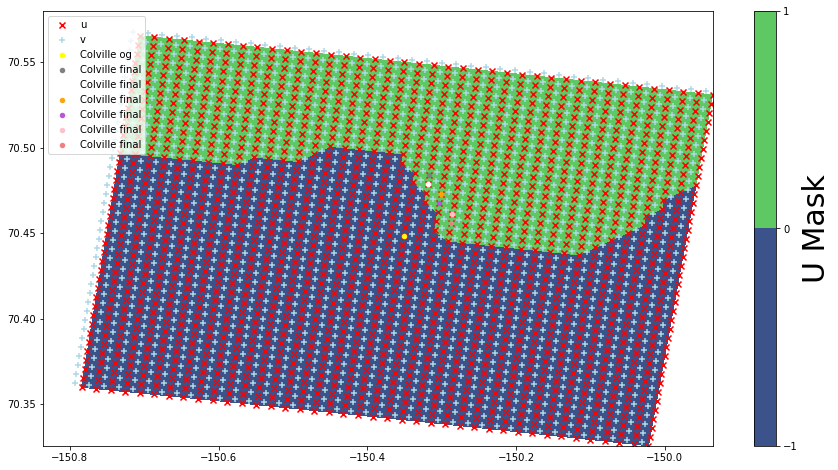

In [31]:
# Make a plot that is a scatter plot of u and v points 
# Plot this point on the grid
# Zoom in to see if we are in the mask
fig2, ax2 = plt.subplots(figsize=(15,8))
cs2 = ax2.contourf(grid.lon_u[eta_col_idx-20:eta_col_idx+20, xi_col_idx-20:xi_col_idx+20].values, 
                    grid.lat_u[eta_col_idx-20:eta_col_idx+20, xi_col_idx-20:xi_col_idx+20].values, 
                    grid.mask_u[eta_col_idx-20:eta_col_idx+20, xi_col_idx-20:xi_col_idx+20].values, lev1)
ax2.scatter(grid.lon_u[eta_col_idx-20:eta_col_idx+20, xi_col_idx-20:xi_col_idx+20].values, 
            grid.lat_u[eta_col_idx-20:eta_col_idx+20, xi_col_idx-20:xi_col_idx+20].values,
            color='red', marker='x', label='u')

ax2.scatter(grid.lon_v[eta_col_idx-20:eta_col_idx+20, xi_col_idx-20:xi_col_idx+20].values, 
            grid.lat_v[eta_col_idx-20:eta_col_idx+20, xi_col_idx-20:xi_col_idx+20].values,
            color='lightblue', marker='+', label='v')


# Colville
ax2.scatter(grid.lon_u[eta_col_idx, xi_col_idx].values, grid.lat_u[eta_col_idx, xi_col_idx].values, 
            marker='.', s=80, color='yellow', label='Colville og')

# Plot all 5 points - combo of u and v cells
# Point 1 - u face
eta_col_idx_test1 = 41
xi_col_idx_test1 = 166 #165

ax2.scatter(grid.lon_u[eta_col_idx_test1, xi_col_idx_test1].values, 
            grid.lat_u[eta_col_idx_test1, xi_col_idx_test1].values, 
            marker='.', s=80, color='gray', label='Colville final')

# Point 2 - u face
eta_col_idx_test2 = 40
xi_col_idx_test2 = 166 #165

ax2.scatter(grid.lon_u[eta_col_idx_test2, xi_col_idx_test2].values, 
            grid.lat_u[eta_col_idx_test2, xi_col_idx_test2].values, 
            marker='.', s=80, color='white', label='Colville final')

# Point 3 - u face
eta_col_idx_test3 = 39
xi_col_idx_test3 = 167 #166

ax2.scatter(grid.lon_u[eta_col_idx_test3, xi_col_idx_test3].values, 
            grid.lat_u[eta_col_idx_test3, xi_col_idx_test3].values, 
            marker='.', s=80, color='orange', label='Colville final')

# Point 4 - u face
eta_col_idx_test4 = 38
xi_col_idx_test4 = 167 #166

ax2.scatter(grid.lon_u[eta_col_idx_test4, xi_col_idx_test4].values, 
            grid.lat_u[eta_col_idx_test4, xi_col_idx_test4].values, 
            marker='.', s=80, color='mediumorchid', label='Colville final')

# Point 5 - u face
eta_col_idx_test5 = 37
xi_col_idx_test5 = 168 #167

ax2.scatter(grid.lon_u[eta_col_idx_test5, xi_col_idx_test5].values, 
            grid.lat_u[eta_col_idx_test5, xi_col_idx_test5].values, 
            marker='.', s=80, color='pink', label='Colville final')

# Point 6 - u face
eta_col_idx_test6 = 36
xi_col_idx_test6 = 168 #167

ax2.scatter(grid.lon_u[eta_col_idx_test6, xi_col_idx_test6].values, 
            grid.lat_u[eta_col_idx_test6, xi_col_idx_test6].values, 
            marker='.', s=80, color='lightcoral', label='Colville final')

ax2.legend()

cbar2 = plt.colorbar(cs2).set_label('U Mask', size=30)

In [32]:
# Check that these spots are in the mask
# Point 1 - u
print(grid.mask_u[eta_col_idx_test1,xi_col_idx_test1].values)
# If so, save it to the list of river indices (these indices are determined by the order in this notebook) = NOT robust
eta_riv_arr[1] = eta_col_idx_test1
xi_riv_arr[1] = xi_col_idx_test1

# Point 2 - u 
print(grid.mask_u[eta_col_idx_test2,xi_col_idx_test2].values)
# If so, save it to the list of river indices (these indices are determined by the order in this notebook) = NOT robust
eta_riv_arr[2] = eta_col_idx_test2
xi_riv_arr[2] = xi_col_idx_test2

# Point 3 - u 
print(grid.mask_u[eta_col_idx_test3,xi_col_idx_test3].values)
# If so, save it to the list of river indices (these indices are determined by the order in this notebook) = NOT robust
eta_riv_arr[3] = eta_col_idx_test3
xi_riv_arr[3] = xi_col_idx_test3

# Point 4 - u
print(grid.mask_u[eta_col_idx_test4,xi_col_idx_test4].values)
# If so, save it to the list of river indices (these indices are determined by the order in this notebook) = NOT robust
eta_riv_arr[4] = eta_col_idx_test4
xi_riv_arr[4] = xi_col_idx_test4

# Point 5 - u
print(grid.mask_u[eta_col_idx_test5,xi_col_idx_test5].values)
# If so, save it to the list of river indices (these indices are determined by the order in this notebook) = NOT robust
eta_riv_arr[5] = eta_col_idx_test5
xi_riv_arr[5] = xi_col_idx_test5

# Point 6 - u
print(grid.mask_u[eta_col_idx_test6,xi_col_idx_test6].values)
# If so, save it to the list of river indices (these indices are determined by the order in this notebook) = NOT robust
eta_riv_arr[6] = eta_col_idx_test6
xi_riv_arr[6] = xi_col_idx_test6

1.0
1.0
1.0
1.0
1.0
1.0


In [33]:
# Set the river_direction
# "river runoff grid-cell face flag"
# where river_direction:flag_values = "0, 1, 2" 
# river_direction:flag_meanings = "flow across u-face, flow across v-face, flow across w-face"
# Set this for each of the 5 points
riv_dir_col1 = 0
riv_dir_col2 = 0
riv_dir_col3 = 0 
riv_dir_col4 = 0
riv_dir_col5 = 0
riv_dir_col6 = 0

# Add this to the list 
riv_direction_arr[1] = riv_dir_col1
riv_direction_arr[2] = riv_dir_col2
riv_direction_arr[3] = riv_dir_col3
riv_direction_arr[4] = riv_dir_col4
riv_direction_arr[5] = riv_dir_col5
riv_direction_arr[6] = riv_dir_col6

In [34]:
# Set river_transport which is the direction of the flow across the u or v face
# This is also where we put "river runoff vertically integrated mass transport"
# river_transport(river_time, river)

# For Colville, we want sign to be positive since we are 
# adding water to the cell to the right and above
# Make a fake time series for each point
# Eventually this will be replaced by the real discharge divided by 5
#Q_col1 = np.full((time_tmp_len), +1000) # m3/s
#Q_col2 = np.full((time_tmp_len), +1000) # m3/s
#Q_col3 = np.full((time_tmp_len), +1000) # m3/s
#Q_col4 = np.full((time_tmp_len), +1000) # m3/s
#Q_col5 = np.full((time_tmp_len), +1000) # m3/s
#Q_col6 = np.full((time_tmp_len), +1000) # m3/s

# Replace this fake time series with real data
Q_col1 = (mean_river_dis.river_transport[182:307,2].values)/len_river_cells_col
Q_col2 = (mean_river_dis.river_transport[182:307,2].values)/len_river_cells_col
Q_col3 = (mean_river_dis.river_transport[182:307,2].values)/len_river_cells_col
Q_col4 = (mean_river_dis.river_transport[182:307,2].values)/len_river_cells_col
Q_col5 = (mean_river_dis.river_transport[182:307,2].values)/len_river_cells_col
Q_col6 = (mean_river_dis.river_transport[182:307,2].values)/len_river_cells_col

# Add this to the list 
#riv_transport_list.append(riv_transport_kal)
riv_transport_arr[:,1] = Q_col1
riv_transport_arr[:,2] = Q_col2
riv_transport_arr[:,3] = Q_col3
riv_transport_arr[:,4] = Q_col4
riv_transport_arr[:,5] = Q_col5
riv_transport_arr[:,6] = Q_col6

In [35]:
# Set river_vshape
# "sets the fractional distribution of the river_transport 
# among the vertical cells and must sum to 1.0 over the vertical"
# "If the river source is in shallow water several grid cells up a 
# river tributary then a simple uniform vertical distribution 
# (all river_Vshape values = 1/s_rho) usually works well"

# Do uniform distribution over all depths 
#riv_vshape_col = np.full((s_rho_len), 1/s_rho_len)

# Read in the vshape for this cell
# Use the indices from above - these are u/v indices but v_shape 
# is n terms of rho indices but hopefully they are close enough 
# that it doesn't matter too much but keep note of this 
riv_vshape_col1 = vshape_all[:, eta_col_idx_test1, xi_col_idx_test1]
riv_vshape_col2 = vshape_all[:, eta_col_idx_test2, xi_col_idx_test2]
riv_vshape_col3 = vshape_all[:, eta_col_idx_test3, xi_col_idx_test3]
riv_vshape_col4 = vshape_all[:, eta_col_idx_test4, xi_col_idx_test4]
riv_vshape_col5 = vshape_all[:, eta_col_idx_test5, xi_col_idx_test5]
riv_vshape_col6 = vshape_all[:, eta_col_idx_test6, xi_col_idx_test6]

# Add this to the array
riv_vshape_arr[:,1] = riv_vshape_col1
riv_vshape_arr[:,2] = riv_vshape_col2
riv_vshape_arr[:,3] = riv_vshape_col3
riv_vshape_arr[:,4] = riv_vshape_col4
riv_vshape_arr[:,5] = riv_vshape_col5
riv_vshape_arr[:,6] = riv_vshape_col6

In [36]:
# Set river runoff potential temperature 
# river_temp(river_time, s_rho, river) 
# river_temp:long_name = "river runoff potential temperature" 
# river_temp:units = "Celsius" 
# river_temp:time = "river_time" 

# This looks like it can vary vertically and can be a timeseries 
#riv_temp_col = np.full((time_tmp_len, s_rho_len), 11)
# Make this the same in each layer 
riv_temp_col = np.empty((time_tmp_len, s_rho_len))
for i in range(s_rho_len):
    riv_temp_col[:,i] = riv_temp

# Add this to the array 
riv_temp_arr[:,:,1] = riv_temp_col
riv_temp_arr[:,:,2] = riv_temp_col
riv_temp_arr[:,:,3] = riv_temp_col
riv_temp_arr[:,:,4] = riv_temp_col
riv_temp_arr[:,:,5] = riv_temp_col
riv_temp_arr[:,:,6] = riv_temp_col

In [37]:
# Set the river runoff salinity
# river_salt(river_time, s_rho, river) 
# river_salt:long_name = "river runoff salinity" 
# river_salt:time = "river_time"
# units: PSS (nondimensional)

# Just like temp, this can vary vertically and over time
riv_salt_col = np.full((time_tmp_len, s_rho_len), 0)

# Add this to the array
riv_salt_arr[:,:,1] = riv_salt_col
riv_salt_arr[:,:,2] = riv_salt_col
riv_salt_arr[:,:,3] = riv_salt_col
riv_salt_arr[:,:,4] = riv_salt_col
riv_salt_arr[:,:,5] = riv_salt_col
riv_salt_arr[:,:,6] = riv_salt_col

In [38]:
# Set the river mud
# 'river_mud_'                                       ! Input
#   'river runoff suspended sediment concentration'
#   'kilogram meter-3'                               ! [kg/m3]
#   'river_sediment, scalar, series'
#   'river_time'

# This is only a time series but maybe can be for different sediment classes?
# (might have a vertical component)

# --- Guesstimate Version ---
# # 10 kg/s / discharge m3/s = kg/m3, picking 10 as a random average 
# # for all rivers and all sediment classes
# # mud class 01
# riv_mud_01_col = 10 / Q_col1 # when there is real data, may need one for each cell
# #riv_mud_01_col = np.full((time_tmp_len), 0.00001)

# # mud class 02
# riv_mud_02_col = 10 / Q_col1 # when there is real data, may need one for each cell
# #riv_mud_02_col = np.full((time_tmp_len), 0.00001)

# ---Lamb and Toniolo 2016 Version---
riv_mud_col_tmp = calc_river_ssc(Q_col1)
# Convert output from mg/L to kg/m3
riv_mud_col = riv_mud_col_tmp/1000

# Divide the total river sediment discharge by two 
# so that half belongs to each mud class
riv_mud_01_col = riv_mud_col/2
riv_mud_02_col = riv_mud_col/2

# Add these to the arrays (can definitely shorten this but oh well)
# mud 01
riv_mud_01_arr[:,1] = riv_mud_01_col
riv_mud_01_arr[:,2] = riv_mud_01_col
riv_mud_01_arr[:,3] = riv_mud_01_col
riv_mud_01_arr[:,4] = riv_mud_01_col
riv_mud_01_arr[:,5] = riv_mud_01_col
riv_mud_01_arr[:,6] = riv_mud_01_col

# mud 02
riv_mud_02_arr[:,1] = riv_mud_02_col
riv_mud_02_arr[:,2] = riv_mud_02_col
riv_mud_02_arr[:,3] = riv_mud_02_col
riv_mud_02_arr[:,4] = riv_mud_02_col
riv_mud_02_arr[:,5] = riv_mud_02_col
riv_mud_02_arr[:,6] = riv_mud_02_col

In [39]:
# Set the river sand
# 'river_sand_'                                      ! Input
#   'river runoff suspended sediment concentration'
#   'kilogram meter-3'                               ! [kg/m3]
#   'river_sediment, scalar, series'
#   'river_time'

# --- Guesstimate Version ---
# 10 kg/s / discharge m3/s = kg/m3, picking 10 as a random average 
# for all rivers and all sediment classes
# *Set all of these to 0 since sand might be too big to be carried by the river*

# sand class 01
riv_sand_01_col = 0 / Q_col1 # when there is real data, may need one for each cell
#riv_sand_01_col = np.full((time_tmp_len), 0.0001)

# sand class 02
riv_sand_02_col = 0 / Q_col1 # when there is real data, may need one for each cell
#riv_sand_02_col = np.full((time_tmp_len), 0.0001)

# sand class 03
riv_sand_03_col = 0 / Q_col1 # when there is real data, may need one for each cell
#riv_sand_03_col = np.full((time_tmp_len), 0.0)

# Add this to the array
# sand 01 
riv_sand_01_arr[:,1] = riv_sand_01_col
riv_sand_01_arr[:,2] = riv_sand_01_col
riv_sand_01_arr[:,3] = riv_sand_01_col
riv_sand_01_arr[:,4] = riv_sand_01_col
riv_sand_01_arr[:,5] = riv_sand_01_col
riv_sand_01_arr[:,6] = riv_sand_01_col

# sand 02
riv_sand_02_arr[:,1] = riv_sand_02_col
riv_sand_02_arr[:,2] = riv_sand_02_col
riv_sand_02_arr[:,3] = riv_sand_02_col
riv_sand_02_arr[:,4] = riv_sand_02_col
riv_sand_02_arr[:,5] = riv_sand_02_col
riv_sand_02_arr[:,6] = riv_sand_02_col

# sand 03
riv_sand_03_arr[:,1] = riv_sand_03_col
riv_sand_03_arr[:,2] = riv_sand_03_col
riv_sand_03_arr[:,3] = riv_sand_03_col
riv_sand_03_arr[:,4] = riv_sand_03_col
riv_sand_03_arr[:,5] = riv_sand_03_col
riv_sand_03_arr[:,6] = riv_sand_03_col

In [40]:
# Set the river id number
# This number will match the one in the info for the netcdf
# Colville
riv_id_col = 2

# Add this to the array
riv_id_arr[1] = riv_id_col
riv_id_arr[2] = riv_id_col
riv_id_arr[3] = riv_id_col
riv_id_arr[4] = riv_id_col
riv_id_arr[5] = riv_id_col
riv_id_arr[6] = riv_id_col

In [41]:
# Set the river flag ('river runoff tracer flag')
# rdir.flag_values = '0, 1, 2, 3'
# rdir.flag_meanings = 'all tracers are off, only temperature is on, 
# only salinity is on, both temperature and salinity are on'
#riv_flag_col = np.full(len_river_cells_kal, 3)
riv_flag_col = 3

# Add this to the array
riv_flag_arr[1] = riv_flag_col
riv_flag_arr[2] = riv_flag_col
riv_flag_arr[3] = riv_flag_col
riv_flag_arr[4] = riv_flag_col
riv_flag_arr[5] = riv_flag_col
riv_flag_arr[6] = riv_flag_col

## Sagavanirktok River 
Location: (70.2924, -148.1712)  
Width: 2000 m  

In [42]:
# Find this river in the mean discharge dataset
print(mean_river_dis.rivers)

(1) Kalikpik, (2) Fish Creek, (3) Colville, (4) Sakonowyak, (5) Kukpuk, (6) Kuparuk, (7) Putuligayuk, (8) Sagavanirktok, (9) Staines (10) Canning, (11) Katakturuk, (12) Hulahula, (13) Jago, (14) Siksik


In [43]:
# Sagavanirktok River (70.2924, -148.1712), 2000 m 
# Set the number of cells it will take 
# 2000 m / 750 m = 2.66 ~ 3 cells
len_river_cells_sag = 3

# Find it manually
eta_sag_idx = 26
xi_sag_idx = 278

# Needs to be on u or v point, depending what makes sense here
print('Sagavanirktok Lat v: ', grid.lat_v[eta_sag_idx, xi_sag_idx].values)
print('Sagavanirktok Lon v: ', grid.lon_v[eta_sag_idx, xi_sag_idx].values)

Sagavanirktok Lat v:  70.29447461133175
Sagavanirktok Lon v:  -148.17284730899166


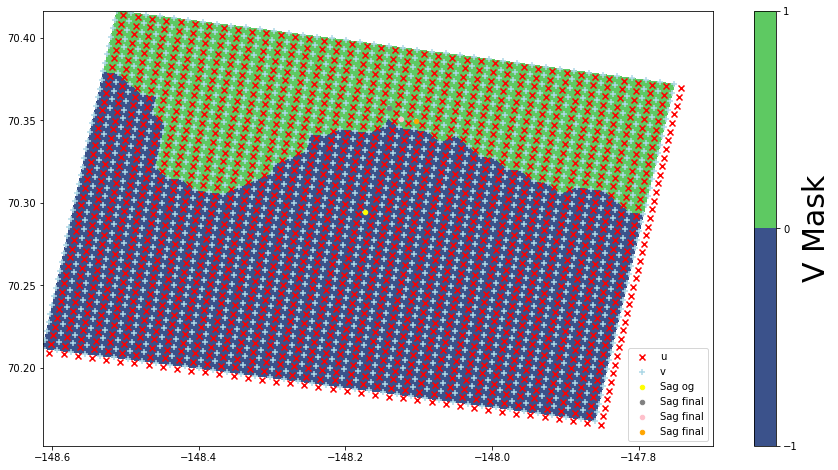

In [44]:
# Make a plot that is a scatter plot of u and v points
# Plot this point on the grid
# Zoom in to see if we are in the mask
fig2, ax2 = plt.subplots(figsize=(15,8))
# Plot the mask
cs2 = ax2.contourf(grid.lon_v[eta_sag_idx-20:eta_sag_idx+20, xi_sag_idx-20:xi_sag_idx+20].values, 
                    grid.lat_v[eta_sag_idx-20:eta_sag_idx+20, xi_sag_idx-20:xi_sag_idx+20].values, 
                    grid.mask_v[eta_sag_idx-20:eta_sag_idx+20, xi_sag_idx-20:xi_sag_idx+20].values, lev1)

# Plot the u points
ax2.scatter(grid.lon_u[eta_sag_idx-20:eta_sag_idx+20, xi_sag_idx-20:xi_sag_idx+20].values, 
            grid.lat_u[eta_sag_idx-20:eta_sag_idx+20, xi_sag_idx-20:xi_sag_idx+20].values,
            color='red', marker='x', label='u')

# Plot the v points
ax2.scatter(grid.lon_v[eta_sag_idx-20:eta_sag_idx+20, xi_sag_idx-20:xi_sag_idx+20].values, 
            grid.lat_v[eta_sag_idx-20:eta_sag_idx+20, xi_sag_idx-20:xi_sag_idx+20].values,
            color='lightblue', marker='+', label='v')


# Sagavanirktok
ax2.scatter(grid.lon_v[eta_sag_idx, xi_sag_idx].values, grid.lat_v[eta_sag_idx, xi_sag_idx].values, 
            marker='.', s=80, color='yellow', label='Sag og')

# Plot all 3 points - combo of u and v cells
# Point 1 - v face
eta_sag_idx_test1 = 38 #37
xi_sag_idx_test1 = 278

ax2.scatter(grid.lon_v[eta_sag_idx_test1, xi_sag_idx_test1].values, 
            grid.lat_v[eta_sag_idx_test1, xi_sag_idx_test1].values, 
            marker='.', s=80, color='gray', label='Sag final')

# Point 2 - v face
eta_sag_idx_test2 = 37 #36
xi_sag_idx_test2 = 279

ax2.scatter(grid.lon_v[eta_sag_idx_test2, xi_sag_idx_test2].values, 
            grid.lat_v[eta_sag_idx_test2, xi_sag_idx_test2].values, 
            marker='.', s=80, color='pink', label='Sag final')

# Point 3 - v face
eta_sag_idx_test3 = 37 #36
xi_sag_idx_test3 = 280

ax2.scatter(grid.lon_v[eta_sag_idx_test3, xi_sag_idx_test3].values, 
            grid.lat_v[eta_sag_idx_test3, xi_sag_idx_test3].values, 
            marker='.', s=80, color='orange', label='Sag final')

ax2.legend()

cbar2 = plt.colorbar(cs2).set_label('V Mask', size=30)

In [45]:
# Check that these spots are in the mask
# Point 1 - v
print(grid.mask_v[eta_sag_idx_test1,xi_sag_idx_test1].values)
# If so, save it to the list of river indices (these indices are determined by the order in this notebook) = NOT robust
eta_riv_arr[7] = eta_sag_idx_test1
xi_riv_arr[7] = xi_sag_idx_test1

# Point 2 - v 
print(grid.mask_v[eta_sag_idx_test2,xi_sag_idx_test2].values)
# If so, save it to the list of river indices (these indices are determined by the order in this notebook) = NOT robust
eta_riv_arr[8] = eta_sag_idx_test2
xi_riv_arr[9] = xi_sag_idx_test2

# Point 3 - v 
print(grid.mask_v[eta_sag_idx_test3,xi_sag_idx_test3].values)
# If so, save it to the list of river indices (these indices are determined by the order in this notebook) = NOT robust
eta_riv_arr[9] = eta_sag_idx_test3
xi_riv_arr[9] = xi_sag_idx_test3

1.0
1.0
1.0


In [46]:
# Set the river_direction
# "river runoff grid-cell face flag"
# where river_direction:flag_values = "0, 1, 2" 
# river_direction:flag_meanings = "flow across u-face, flow across v-face, flow across w-face"
# Set this for each of the 5 points
riv_dir_sag1 = 1
riv_dir_sag2 = 1
riv_dir_sag3 = 1 

# Add this to the list 
riv_direction_arr[7] = riv_dir_sag1
riv_direction_arr[8] = riv_dir_sag2
riv_direction_arr[9] = riv_dir_sag3

In [47]:
# Set river_transport which is the direction of the flow across the u or v face
# This is also where we put "river runoff vertically integrated mass transport"
# river_transport(river_time, river)

# Make a fake time series for each point
# Eventually this will be replaced by the real discharge divided by 3
#Q_sag1 = np.full((time_tmp_len), 1000) # m3/s
#Q_sag2 = np.full((time_tmp_len), 1000) # m3/s
#Q_sag3 = np.full((time_tmp_len), 1000) # m3/s

# Replace this fake time series with real data
Q_sag1 = (mean_river_dis.river_transport[182:307,7].values)/len_river_cells_sag
Q_sag2 = (mean_river_dis.river_transport[182:307,7].values)/len_river_cells_sag
Q_sag3 = (mean_river_dis.river_transport[182:307,7].values)/len_river_cells_sag

# Add this to the list 
#riv_transport_list.append(riv_transport_kal)
riv_transport_arr[:,7] = Q_sag1
riv_transport_arr[:,8] = Q_sag2
riv_transport_arr[:,9] = Q_sag3

In [48]:
# Set river_vshape
# "sets the fractional distribution of the river_transport 
# among the vertical cells and must sum to 1.0 over the vertical"
# "If the river source is in shallow water several grid cells up a 
# river tributary then a simple uniform vertical distribution 
# (all river_Vshape values = 1/s_rho) usually works well"

# Do uniform distribution over all depths 
#riv_vshape_sag = np.full((s_rho_len), 1/s_rho_len)

# Read in the vshape for this cell
# Use the indices from above - these are u/v indices but v_shape 
# is n terms of rho indices but hopefully they are close enough 
# that it doesn't matter too much but keep note of this 
riv_vshape_sag1 = vshape_all[:, eta_sag_idx_test1, xi_sag_idx_test1]
riv_vshape_sag2 = vshape_all[:, eta_sag_idx_test2, xi_sag_idx_test2]
riv_vshape_sag3 = vshape_all[:, eta_sag_idx_test3, xi_sag_idx_test3]

# Add this to the array
riv_vshape_arr[:,7] = riv_vshape_sag1
riv_vshape_arr[:,8] = riv_vshape_sag2
riv_vshape_arr[:,9] = riv_vshape_sag3

In [49]:
# Set river runoff potential temperature 
# river_temp(river_time, s_rho, river) 
# river_temp:long_name = "river runoff potential temperature" 
# river_temp:units = "Celsius" 
# river_temp:time = "river_time" 

# This looks like it can vary vertically and can be a timeseries 
#riv_temp_sag = np.full((time_tmp_len, s_rho_len), 11)
# Make this the same in each layer 
riv_temp_sag = np.empty((time_tmp_len, s_rho_len))
for i in range(s_rho_len):
    riv_temp_sag[:,i] = riv_temp

# Add this to the array 
riv_temp_arr[:,:,7] = riv_temp_sag
riv_temp_arr[:,:,8] = riv_temp_sag
riv_temp_arr[:,:,9] = riv_temp_sag

In [50]:
# Set the river runoff salinity
# river_salt(river_time, s_rho, river) 
# river_salt:long_name = "river runoff salinity" 
# river_salt:time = "river_time"
# units: PSS (nondimensional)

# Just like temp, this can vary vertically and over time
riv_salt_sag = np.full((time_tmp_len, s_rho_len), 0)

# Add this to the array
riv_salt_arr[:,:,7] = riv_salt_sag
riv_salt_arr[:,:,8] = riv_salt_sag
riv_salt_arr[:,:,9] = riv_salt_sag

In [51]:
# Set the river mud
# 'river_mud_'                                       ! Input
#   'river runoff suspended sediment concentration'
#   'kilogram meter-3'                               ! [kg/m3]
#   'river_sediment, scalar, series'
#   'river_time'

# --- Guesstimate Version ---
# # 10 kg/s / discharge m3/s = kg/m3, picking 10 as a random average 
# # for all rivers and all sediment classes
# # mud class 01
# riv_mud_01_sag = 10 / Q_sag1 # when there is real data, may need one for each cell
# #riv_mud_01_sag = np.full((time_tmp_len), 0.00001)

# # mud class 02
# riv_mud_02_sag = 10 / Q_sag1 # when there is real data, may need one for each cell
# #riv_mud_02_sag = np.full((time_tmp_len), 0.00001)

# --- Lamb and Toniolo 2016 Version ---
riv_mud_sag_tmp = calc_river_ssc(Q_sag1)
# Convert output from mg/L to kg/m3
riv_mud_sag = riv_mud_sag_tmp/1000

# Divide the total river sediment discharge by two 
# so that half belongs to each mud class
riv_mud_01_sag = riv_mud_sag/2
riv_mud_02_sag = riv_mud_sag/2

# Add these to the arrays (can definitely shorten this but oh well)
# mud 01
riv_mud_01_arr[:,7] = riv_mud_01_sag
riv_mud_01_arr[:,8] = riv_mud_01_sag
riv_mud_01_arr[:,9] = riv_mud_01_sag

# mud 02
riv_mud_02_arr[:,7] = riv_mud_02_sag
riv_mud_02_arr[:,8] = riv_mud_02_sag
riv_mud_02_arr[:,9] = riv_mud_02_sag

In [52]:
# Set the river sand
# 'river_sand_'                                      ! Input
#   'river runoff suspended sediment concentration'
#   'kilogram meter-3'                               ! [kg/m3]
#   'river_sediment, scalar, series'
#   'river_time'

# --- Guesstimate Version ---
# 10 kg/s / discharge m3/s = kg/m3, picking 10 as a random average 
# for all rivers and all sediment classes
# *Set all of these to 0 since sand might be too big to be carried by the river*

# sand class 01
riv_sand_01_sag = 0 / Q_sag1 # when there is real data, may need one for each cell
#riv_sand_01_sag = np.full((time_tmp_len), 0.0001)

# sand class 02
riv_sand_02_sag = 0 / Q_sag1 # when there is real data, may need one for each cell
#riv_sand_02_sag = np.full((time_tmp_len), 0.0001)

# sand class 03
riv_sand_03_sag = 0 / Q_sag1 # when there is real data, may need one for each cell
#riv_sand_03_sag = np.full((time_tmp_len), 0.0)

# Add this to the array
# sand 01 
riv_sand_01_arr[:,7] = riv_sand_01_sag
riv_sand_01_arr[:,8] = riv_sand_01_sag
riv_sand_01_arr[:,9] = riv_sand_01_sag

# sand 02
riv_sand_02_arr[:,7] = riv_sand_02_sag
riv_sand_02_arr[:,8] = riv_sand_02_sag
riv_sand_02_arr[:,9] = riv_sand_02_sag

# sand 03
riv_sand_03_arr[:,7] = riv_sand_03_sag
riv_sand_03_arr[:,8] = riv_sand_03_sag
riv_sand_03_arr[:,9] = riv_sand_03_sag

In [53]:
# Set the river id number
# This number will match the one in the info for the netcdf
# Sagavanirktok
riv_id_sag = 3

# Add this to the array
riv_id_arr[7] = riv_id_sag
riv_id_arr[8] = riv_id_sag
riv_id_arr[9] = riv_id_sag

In [54]:
# Set the river flag ('river runoff tracer flag')
# rdir.flag_values = '0, 1, 2, 3'
# rdir.flag_meanings = 'all tracers are off, only temperature is on, 
# only salinity is on, both temperature and salinity are on'
#riv_flag_sag = np.full(len_river_cells_sag, 3)
riv_flag_sag = 3

# Add this to the array
riv_flag_arr[7] = riv_flag_sag
riv_flag_arr[8] = riv_flag_sag
riv_flag_arr[9] = riv_flag_sag

## Fish Creek 
Location: 70.3786, -151.3608  
Width: 405.9 m  

In [55]:
# Find this river in the mean discharge dataset
print(mean_river_dis.rivers)

(1) Kalikpik, (2) Fish Creek, (3) Colville, (4) Sakonowyak, (5) Kukpuk, (6) Kuparuk, (7) Putuligayuk, (8) Sagavanirktok, (9) Staines (10) Canning, (11) Katakturuk, (12) Hulahula, (13) Jago, (14) Siksik


In [56]:
# Fish Creek (70.3786, -151.3608), 405.9 m
# Set the number of cells it will take 
# 405.9 m / 750 m = 0.5412 ~ 1 cell
len_river_cells_fis = 1

# Find it manually
eta_fis_idx = 12
xi_fis_idx = 115

# Needs to be on u or v point, depending what makes sense here
print('Fish Creek Lat u: ', grid.lat_u[eta_fis_idx, xi_fis_idx].values)
print('Fish Creek Lon u: ', grid.lon_u[eta_fis_idx, xi_fis_idx].values)

Fish Creek Lat u:  70.37329673013637
Fish Creek Lon u:  -151.3762640291327


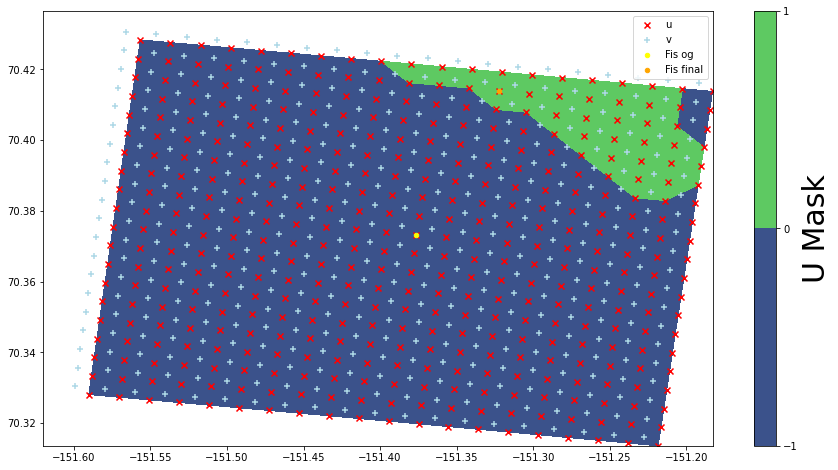

In [57]:
# Make a plot that is a scatter plot of u and v points
# Plot this point on the grid
# Zoom in to see if we are in the mask
fig2, ax2 = plt.subplots(figsize=(15,8))
# Plot the mask
cs2 = ax2.contourf(grid.lon_u[eta_fis_idx-10:eta_fis_idx+10, xi_fis_idx-10:xi_fis_idx+10].values, 
                    grid.lat_u[eta_fis_idx-10:eta_fis_idx+10, xi_fis_idx-10:xi_fis_idx+10].values, 
                    grid.mask_u[eta_fis_idx-10:eta_fis_idx+10, xi_fis_idx-10:xi_fis_idx+10].values, lev1)

# Plot the u points
ax2.scatter(grid.lon_u[eta_fis_idx-10:eta_fis_idx+10, xi_fis_idx-10:xi_fis_idx+10].values, 
            grid.lat_u[eta_fis_idx-10:eta_fis_idx+10, xi_fis_idx-10:xi_fis_idx+10].values,
            color='red', marker='x', label='u')

# Plot the v points
ax2.scatter(grid.lon_v[eta_fis_idx-10:eta_fis_idx+10, xi_fis_idx-10:xi_fis_idx+10].values, 
            grid.lat_v[eta_fis_idx-10:eta_fis_idx+10, xi_fis_idx-10:xi_fis_idx+10].values,
            color='lightblue', marker='+', label='v')


# Fish Creek
ax2.scatter(grid.lon_u[eta_fis_idx, xi_fis_idx].values, grid.lat_u[eta_fis_idx, xi_fis_idx].values, 
            marker='.', s=80, color='yellow', label='Fis og')

# Point 1 - u face
eta_fis_idx_test1 = 20
xi_fis_idx_test1 = 117 #116

ax2.scatter(grid.lon_u[eta_fis_idx_test1, xi_fis_idx_test1].values, 
            grid.lat_u[eta_fis_idx_test1, xi_fis_idx_test1].values, 
            marker='.', s=80, color='orange', label='Fis final')


ax2.legend()

cbar2 = plt.colorbar(cs2).set_label('U Mask', size=30)

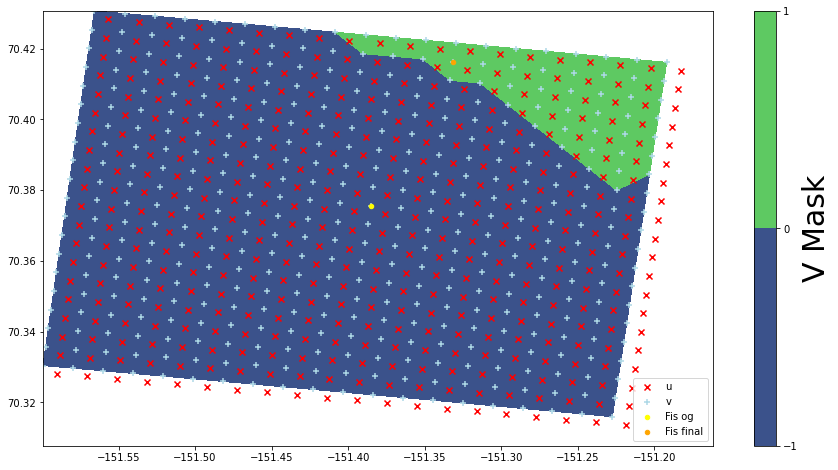

In [58]:
# CHECK V VERSION 
# Make a plot that is a scatter plot of u and v points
# Plot this point on the grid
# Zoom in to see if we are in the mask
fig2, ax2 = plt.subplots(figsize=(15,8))
# Plot the mask
cs2 = ax2.contourf(grid.lon_v[eta_fis_idx-10:eta_fis_idx+10, xi_fis_idx-10:xi_fis_idx+10].values, 
                    grid.lat_v[eta_fis_idx-10:eta_fis_idx+10, xi_fis_idx-10:xi_fis_idx+10].values, 
                    grid.mask_v[eta_fis_idx-10:eta_fis_idx+10, xi_fis_idx-10:xi_fis_idx+10].values, lev1)

# Plot the u points
ax2.scatter(grid.lon_u[eta_fis_idx-10:eta_fis_idx+10, xi_fis_idx-10:xi_fis_idx+10].values, 
            grid.lat_u[eta_fis_idx-10:eta_fis_idx+10, xi_fis_idx-10:xi_fis_idx+10].values,
            color='red', marker='x', label='u')

# Plot the v points
ax2.scatter(grid.lon_v[eta_fis_idx-10:eta_fis_idx+10, xi_fis_idx-10:xi_fis_idx+10].values, 
            grid.lat_v[eta_fis_idx-10:eta_fis_idx+10, xi_fis_idx-10:xi_fis_idx+10].values,
            color='lightblue', marker='+', label='v')


# Fish Creek
ax2.scatter(grid.lon_v[eta_fis_idx, xi_fis_idx].values, grid.lat_v[eta_fis_idx, xi_fis_idx].values, 
            marker='.', s=80, color='yellow', label='Fis og')

# Point 1 - u face
eta_fis_idx_test1 = 20
xi_fis_idx_test1 = 117 #116

ax2.scatter(grid.lon_v[eta_fis_idx_test1, xi_fis_idx_test1].values, 
            grid.lat_v[eta_fis_idx_test1, xi_fis_idx_test1].values, 
            marker='.', s=80, color='orange', label='Fis final')


ax2.legend()

cbar2 = plt.colorbar(cs2).set_label('V Mask', size=30)

In [59]:
# Check that these spots are in the mask
# Point 1 - u
print(grid.mask_u[eta_fis_idx_test1,xi_fis_idx_test1].values)
# If so, save it to the list of river indices (these indices are determined by the order in this notebook) = NOT robust
#eta_riv_arr[10] = eta_fis_idx_test1
#xi_riv_arr[10] = xi_fis_idx_test1

1.0


In [60]:
# CHECK V VERSION
# Check that these spots are in the mask
# Point 1 - v
print(grid.mask_v[eta_fis_idx_test1,xi_fis_idx_test1].values)
# If so, save it to the list of river indices (these indices are determined by the order in this notebook) = NOT robust
eta_riv_arr[10] = eta_fis_idx_test1
xi_riv_arr[10] = xi_fis_idx_test1

1.0


In [61]:
# Set the river_direction
# "river runoff grid-cell face flag"
# where river_direction:flag_values = "0, 1, 2" 
# river_direction:flag_meanings = "flow across u-face, flow across v-face, flow across w-face"
# Set this for each of the 5 points
#riv_dir_fis1 = 0
riv_dir_fis1 = 1 # IF V VERSION

# Add this to the list 
riv_direction_arr[10] = riv_dir_fis1

In [62]:
# Set river_transport which is the direction of the flow across the u or v face
# This is also where we put "river runoff vertically integrated mass transport"
# river_transport(river_time, river)

# Make a fake time series for each point
#Q_fis1 = np.full((time_tmp_len), 1000) # m3/s

# Replace this fake time series with real data
Q_fis1 = (mean_river_dis.river_transport[182:307,1].values)/len_river_cells_fis

# Add this to the list 
#riv_transport_list.append(riv_transport_kal)
riv_transport_arr[:,10] = Q_fis1

In [63]:
# Set river_vshape
# "sets the fractional distribution of the river_transport 
# among the vertical cells and must sum to 1.0 over the vertical"
# "If the river source is in shallow water several grid cells up a 
# river tributary then a simple uniform vertical distribution 
# (all river_Vshape values = 1/s_rho) usually works well"

# Do uniform distribution over all depths 
#riv_vshape_fis = np.full((s_rho_len), 1/s_rho_len)

# Read in the vshape for this cell
# Use the indices from above - these are u/v indices but v_shape 
# is n terms of rho indices but hopefully they are close enough 
# that it doesn't matter too much but keep note of this 
riv_vshape_fis = vshape_all[:, eta_fis_idx_test1, xi_fis_idx_test1]

# Add this to the array
riv_vshape_arr[:,10] = riv_vshape_fis

In [64]:
# Set river runoff potential temperature 
# river_temp(river_time, s_rho, river) 
# river_temp:long_name = "river runoff potential temperature" 
# river_temp:units = "Celsius" 
# river_temp:time = "river_time" 

# This looks like it can vary vertically and can be a timeseries 
#riv_temp_fis = np.full((time_tmp_len, s_rho_len), 11)
# Make this the same in each layer 
riv_temp_fis = np.empty((time_tmp_len, s_rho_len))
for i in range(s_rho_len):
    riv_temp_fis[:,i] = riv_temp

# Add this to the array 
riv_temp_arr[:,:,10] = riv_temp_fis

In [65]:
# Set the river runoff salinity
# river_salt(river_time, s_rho, river) 
# river_salt:long_name = "river runoff salinity" 
# river_salt:time = "river_time"
# units: PSS (nondimensional)

# Just like temp, this can vary vertically and over time
riv_salt_fis = np.full((time_tmp_len, s_rho_len), 0)

# Add this to the array
riv_salt_arr[:,:,10] = riv_salt_fis

In [66]:
# Set the river mud
# 'river_mud_'                                       ! Input
#   'river runoff suspended sediment concentration'
#   'kilogram meter-3'                               ! [kg/m3]
#   'river_sediment, scalar, series'
#   'river_time'

# --- Guesstimate Version ---
# # 10 kg/s / discharge m3/s = kg/m3, picking 10 as a random average 
# # for all rivers and all sediment classes
# # mud class 01
# riv_mud_01_fis = 10 / Q_fis1 # when there is real data, may need one for each cell
# #riv_mud_01_fis = np.full((time_tmp_len), 0.00001)

# # mud class 02
# riv_mud_02_fis = 10 / Q_fis1 # when there is real data, may need one for each cell
# #riv_mud_02_fis = np.full((time_tmp_len), 0.00001)

# --- Lamb and Toniolo 2016 Version ---
riv_mud_fis_tmp = calc_river_ssc(Q_fis1)
# Convert output from mg/L to kg/m3
riv_mud_fis = riv_mud_fis_tmp/1000

# Divide the total river sediment discharge by two 
# so that half belongs to each mud class
riv_mud_01_fis = riv_mud_fis/2
riv_mud_02_fis = riv_mud_fis/2

# Add these to the arrays (can definitely shorten this but oh well)
# mud 01
riv_mud_01_arr[:,10] = riv_mud_01_fis

# mud 02
riv_mud_02_arr[:,10] = riv_mud_02_fis

In [67]:
# Set the river sand
# 'river_sand_'                                      ! Input
#   'river runoff suspended sediment concentration'
#   'kilogram meter-3'                               ! [kg/m3]
#   'river_sediment, scalar, series'
#   'river_time'

# --- Guesstimate Version ---
# 10 kg/s / discharge m3/s = kg/m3, picking 10 as a random average 
# for all rivers and all sediment classes
# *Set all of these to 0 since sand might be too big to be carried by the river*

# sand class 01
riv_sand_01_fis = 0 / Q_fis1 # when there is real data, may need one for each cell
#riv_sand_01_fis = np.full((time_tmp_len), 0.0001)

# sand class 02
riv_sand_02_fis = 0 / Q_fis1 # when there is real data, may need one for each cell
#riv_sand_02_fis = np.full((time_tmp_len), 0.0001)

# sand class 03
riv_sand_03_fis = 0 / Q_fis1 # when there is real data, may need one for each cell
#riv_sand_03_fis = np.full((time_tmp_len), 0.0)

# Add this to the array
# sand 01 
riv_sand_01_arr[:,10] = riv_sand_01_fis

# sand 02
riv_sand_02_arr[:,10] = riv_sand_02_fis

# sand 03
riv_sand_03_arr[:,10] = riv_sand_03_fis

In [68]:
# Set the river id number
# This number will match the one in the info for the netcdf
# Fish Creek
riv_id_fis = 4

# Add this to the array
riv_id_arr[10] = riv_id_fis

In [69]:
# Set the river flag ('river runoff tracer flag')
# rdir.flag_values = '0, 1, 2, 3'
# rdir.flag_meanings = 'all tracers are off, only temperature is on, 
# only salinity is on, both temperature and salinity are on'
riv_flag_fis = 3

# Add this to the array
riv_flag_arr[10] = riv_flag_fis

## Sakonowyak River 
Location: 70.4452, -149.0206  
Width: 733.3 m

In [70]:
# Find this river in the mean discharge dataset
print(mean_river_dis.rivers)

(1) Kalikpik, (2) Fish Creek, (3) Colville, (4) Sakonowyak, (5) Kukpuk, (6) Kuparuk, (7) Putuligayuk, (8) Sagavanirktok, (9) Staines (10) Canning, (11) Katakturuk, (12) Hulahula, (13) Jago, (14) Siksik


In [71]:
# Sakonowyak River (70.4452, -149.0206), 733.3 m
# Set the number of cells it will take 
# 733.3 m / 750 m = 0.98 ~ 1 cells
len_river_cells_sak = 1

# Find it manually
eta_sak_idx = 26
xi_sak_idx = 234

# Needs to be on u or v point, depending what makes sense here
print('Sakonowyak Lat v: ', grid.lat_v[eta_sak_idx, xi_sak_idx].values)
print('Sakonowyak Lon v: ', grid.lon_v[eta_sak_idx, xi_sak_idx].values)

Sakonowyak Lat v:  70.34218604811143
Sakonowyak Lon v:  -149.02793401854387


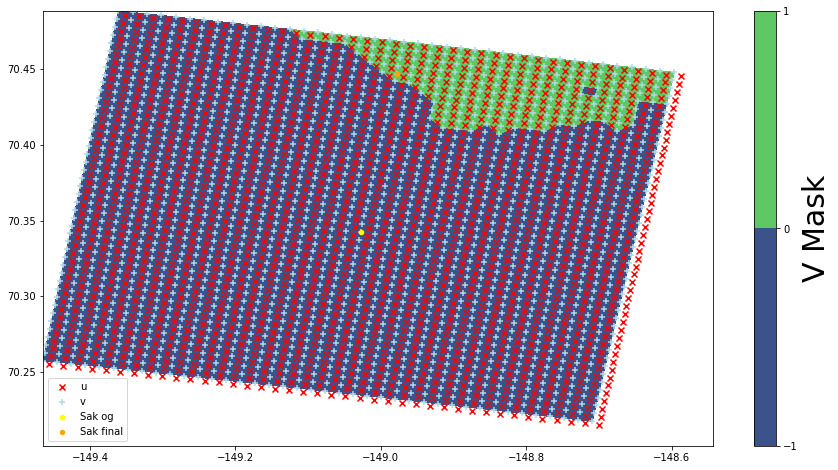

In [72]:
# Make a plot that is a scatter plot of u and v points
# Plot this point on the grid
# Zoom in to see if we are in the mask
fig2, ax2 = plt.subplots(figsize=(15,8))
# Plot the mask
cs2 = ax2.contourf(grid.lon_v[eta_sak_idx-20:eta_sak_idx+25, xi_sak_idx-20:xi_sak_idx+20].values, 
                    grid.lat_v[eta_sak_idx-20:eta_sak_idx+25, xi_sak_idx-20:xi_sak_idx+20].values, 
                    grid.mask_v[eta_sak_idx-20:eta_sak_idx+25, xi_sak_idx-20:xi_sak_idx+20].values, lev1)

# Plot the u points
ax2.scatter(grid.lon_u[eta_sak_idx-20:eta_sak_idx+25, xi_sak_idx-20:xi_sak_idx+20].values, 
            grid.lat_u[eta_sak_idx-20:eta_sak_idx+25, xi_sak_idx-20:xi_sak_idx+20].values,
            color='red', marker='x', label='u')

# Plot the v points
ax2.scatter(grid.lon_v[eta_sak_idx-20:eta_sak_idx+25, xi_sak_idx-20:xi_sak_idx+20].values, 
            grid.lat_v[eta_sak_idx-20:eta_sak_idx+25, xi_sak_idx-20:xi_sak_idx+20].values,
            color='lightblue', marker='+', label='v')


# Sakonowyak
ax2.scatter(grid.lon_v[eta_sak_idx, xi_sak_idx].values, grid.lat_v[eta_sak_idx, xi_sak_idx].values, 
            marker='.', s=80, color='yellow', label='Sak og')

# Point 1 - v face
eta_sak_idx_test1 = 46 #45
xi_sak_idx_test1 = 234

ax2.scatter(grid.lon_v[eta_sak_idx_test1, xi_sak_idx_test1].values, 
            grid.lat_v[eta_sak_idx_test1, xi_sak_idx_test1].values, 
            marker='.', s=80, color='orange', label='Sak final')

ax2.legend()

cbar2 = plt.colorbar(cs2).set_label('V Mask', size=30)

In [73]:
# Check that these spots are in the mask
# Point 1 - v
print(grid.mask_v[eta_sak_idx_test1,xi_sak_idx_test1].values)
# If so, save it to the list of river indices (these indices are determined by the order in this notebook) = NOT robust
eta_riv_arr[11] = eta_sak_idx_test1
xi_riv_arr[11] = xi_sak_idx_test1

1.0


In [74]:
# Set the river_direction
# "river runoff grid-cell face flag"
# where river_direction:flag_values = "0, 1, 2" 
# river_direction:flag_meanings = "flow across u-face, flow across v-face, flow across w-face"
# Set this for each of the 5 points
riv_dir_sak1 = 1

# Add this to the list 
riv_direction_arr[11] = riv_dir_sak1

In [75]:
# Set river_transport which is the direction of the flow across the u or v face
# This is also where we put "river runoff vertically integrated mass transport"
# river_transport(river_time, river)

# Make a fake time series for each point
#Q_sak1 = np.full((time_tmp_len), 1000) # m3/s # 50


# Replace this fake time series with real data
Q_sak1 = (mean_river_dis.river_transport[182:307,3].values)/len_river_cells_sak


# Add this to the list 
riv_transport_arr[:,11] = Q_sak1

In [76]:
# Set river_vshape
# "sets the fractional distribution of the river_transport 
# among the vertical cells and must sum to 1.0 over the vertical"
# "If the river source is in shallow water several grid cells up a 
# river tributary then a simple uniform vertical distribution 
# (all river_Vshape values = 1/s_rho) usually works well"

# Do uniform distribution over all depths 
#riv_vshape_sak = np.full((s_rho_len), 1/s_rho_len)

# Read in the vshape for this cell
# Use the indices from above - these are u/v indices but v_shape 
# is n terms of rho indices but hopefully they are close enough 
# that it doesn't matter too much but keep note of this 
riv_vshape_sak = vshape_all[:, eta_sak_idx_test1, xi_sak_idx_test1]

# Add this to the array
riv_vshape_arr[:,11] = riv_vshape_sak

In [77]:
# Set river runoff potential temperature 
# river_temp(river_time, s_rho, river) 
# river_temp:long_name = "river runoff potential temperature" 
# river_temp:units = "Celsius" 
# river_temp:time = "river_time" 

# This looks like it can vary vertically and can be a timeseries 
#riv_temp_sak = np.full((time_tmp_len, s_rho_len), 11)
# Make this the same in each layer 
riv_temp_sak = np.empty((time_tmp_len, s_rho_len))
for i in range(s_rho_len):
    riv_temp_sak[:,i] = riv_temp

# Add this to the array 
riv_temp_arr[:,:,11] = riv_temp_sak

In [78]:
# Set the river runoff salinity
# river_salt(river_time, s_rho, river) 
# river_salt:long_name = "river runoff salinity" 
# river_salt:time = "river_time"
# units: PSS (nondimensional)

# Just like temp, this can vary vertically and over time
riv_salt_sak = np.full((time_tmp_len, s_rho_len), 0)

# Add this to the array
riv_salt_arr[:,:,11] = riv_salt_sak

In [79]:
# Set the river mud
# 'river_mud_'                                       ! Input
#   'river runoff suspended sediment concentration'
#   'kilogram meter-3'                               ! [kg/m3]
#   'river_sediment, scalar, series'
#   'river_time'

# --- Guesstimate Version ---
# # 10 kg/s / discharge m3/s = kg/m3, picking 10 as a random average 
# # for all rivers and all sediment classes
# # mud class 01
# riv_mud_01_sak = 10 / Q_sak1 # when there is real data, may need one for each cell
# #riv_mud_01_sak = np.full((time_tmp_len), 0.00001)

# # mud class 02
# riv_mud_02_sak = 10 / Q_sak1 # when there is real data, may need one for each cell
# #riv_mud_02_sak = np.full((time_tmp_len), 0.00001)

# --- Lamb and Toniolo 2016 Version ---
riv_mud_sak_tmp = calc_river_ssc(Q_sak1)
# Convert output from mg/L to kg/m3
riv_mud_sak = riv_mud_sak_tmp/1000

# Divide the total river sediment discharge by two 
# so that half belongs to each mud class
riv_mud_01_sak = riv_mud_sak/2
riv_mud_02_sak = riv_mud_sak/2

# Add these to the arrays (can definitely shorten this but oh well)
# mud 01
riv_mud_01_arr[:,11] = riv_mud_01_sak

# mud 02
riv_mud_02_arr[:,11] = riv_mud_02_sak

In [80]:
# Set the river sand
# 'river_sand_'                                      ! Input
#   'river runoff suspended sediment concentration'
#   'kilogram meter-3'                               ! [kg/m3]
#   'river_sediment, scalar, series'
#   'river_time'

# --- Guesstimate Verison ---
# 10 kg/s / discharge m3/s = kg/m3, picking 10 as a random average 
# for all rivers and all sediment classes
# *Set all of these to 0 since sand might be too big to be carried by the river*

# sand class 01
riv_sand_01_sak = 0 / Q_sak1 # when there is real data, may need one for each cell
#riv_sand_01_sak = np.full((time_tmp_len), 0.0001)

# sand class 02
riv_sand_02_sak = 0 / Q_sak1 # when there is real data, may need one for each cell
#riv_sand_02_sak = np.full((time_tmp_len), 0.0001)

# sand class 03
riv_sand_03_sak = 0 / Q_sak1 # when there is real data, may need one for each cell
#riv_sand_03_sak = np.full((time_tmp_len), 0.0)

# Add this to the array
# sand 01 
riv_sand_01_arr[:,11] = riv_sand_01_sak

# sand 02
riv_sand_02_arr[:,11] = riv_sand_02_sak

# sand 03
riv_sand_03_arr[:,11] = riv_sand_03_sak

In [81]:
# Set the river id number
# This number will match the one in the info for the netcdf
# Fish Creek
riv_id_sak = 5

# Add this to the array
riv_id_arr[11] = riv_id_sak

In [82]:
# Set the river flag ('river runoff tracer flag')
# rdir.flag_values = '0, 1, 2, 3'
# rdir.flag_meanings = 'all tracers are off, only temperature is on, 
# only salinity is on, both temperature and salinity are on'
riv_flag_sak = 3

# Add this to the array
riv_flag_arr[11] = riv_flag_sak

## Kuparik River (splits into two rivers near coast): 
### Kukpuk River 
Location: 70.4152, -148.8956  
Width: 530 m

In [83]:
# Find this river in the mean discharge dataset
print(mean_river_dis.rivers)

(1) Kalikpik, (2) Fish Creek, (3) Colville, (4) Sakonowyak, (5) Kukpuk, (6) Kuparuk, (7) Putuligayuk, (8) Sagavanirktok, (9) Staines (10) Canning, (11) Katakturuk, (12) Hulahula, (13) Jago, (14) Siksik


In [84]:
# Kukpuk River (70.4152, -148.8956), 530 m
# Set the number of cells it will take 
# 530 m / 750 m = ~ 1 cells
len_river_cells_kuk = 1

# Find it manually
eta_kuk_idx = 41
xi_kuk_idx = 239

# Needs to be on u or v point, depending what makes sense here
print('Kukpuk Lat v: ', grid.lat_v[eta_kuk_idx, xi_kuk_idx].values)
print('Kukpuk Lon v: ', grid.lon_v[eta_kuk_idx, xi_kuk_idx].values)

Kukpuk Lat v:  70.4156651609859
Kukpuk Lon v:  -148.89310536150845


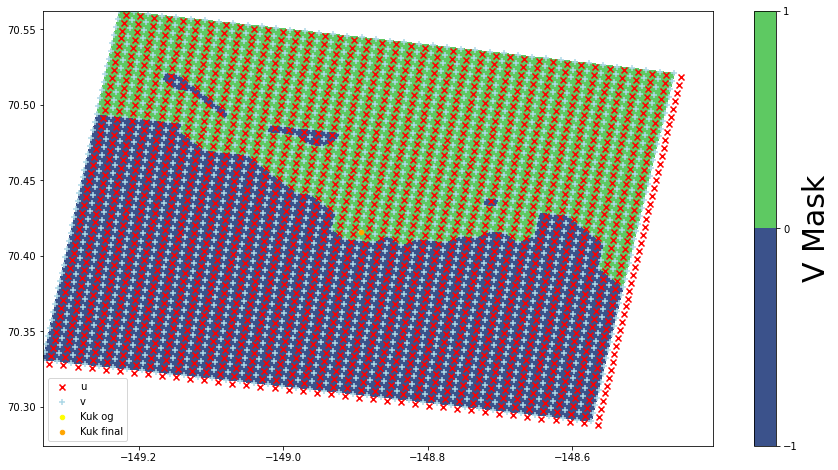

In [85]:
# Make a plot that is a scatter plot of u and v points
# Plot this point on the grid
# Zoom in to see if we are in the mask
fig2, ax2 = plt.subplots(figsize=(15,8))
# Plot the mask
cs2 = ax2.contourf(grid.lon_v[eta_kuk_idx-20:eta_kuk_idx+25, xi_kuk_idx-20:xi_kuk_idx+20].values, 
                    grid.lat_v[eta_kuk_idx-20:eta_kuk_idx+25, xi_kuk_idx-20:xi_kuk_idx+20].values, 
                    grid.mask_v[eta_kuk_idx-20:eta_kuk_idx+25, xi_kuk_idx-20:xi_kuk_idx+20].values, lev1)

# Plot the u points
ax2.scatter(grid.lon_u[eta_kuk_idx-20:eta_kuk_idx+25, xi_kuk_idx-20:xi_kuk_idx+20].values, 
            grid.lat_u[eta_kuk_idx-20:eta_kuk_idx+25, xi_kuk_idx-20:xi_kuk_idx+20].values,
            color='red', marker='x', label='u')

# Plot the v points
ax2.scatter(grid.lon_v[eta_kuk_idx-20:eta_kuk_idx+25, xi_kuk_idx-20:xi_kuk_idx+20].values, 
            grid.lat_v[eta_kuk_idx-20:eta_kuk_idx+25, xi_kuk_idx-20:xi_kuk_idx+20].values,
            color='lightblue', marker='+', label='v')


# Kukpuk
ax2.scatter(grid.lon_v[eta_kuk_idx, xi_kuk_idx].values, grid.lat_v[eta_kuk_idx, xi_kuk_idx].values, 
            marker='.', s=80, color='yellow', label='Kuk og')

# Point 1 - v face
eta_kuk_idx_test1 = 41 #40
xi_kuk_idx_test1 = 239

ax2.scatter(grid.lon_v[eta_kuk_idx_test1, xi_kuk_idx_test1].values, 
            grid.lat_v[eta_kuk_idx_test1, xi_kuk_idx_test1].values, 
            marker='.', s=80, color='orange', label='Kuk final')

ax2.legend()

cbar2 = plt.colorbar(cs2).set_label('V Mask', size=30)

In [86]:
# Check that these spots are in the mask
# Point 1 - v
print(grid.mask_v[eta_kuk_idx_test1,xi_kuk_idx_test1].values)
# If so, save it to the list of river indices (these indices are determined by the order in this notebook) = NOT robust
eta_riv_arr[12] = eta_kuk_idx_test1
xi_riv_arr[12] = xi_kuk_idx_test1

1.0


In [87]:
# Set the river_direction
# "river runoff grid-cell face flag"
# where river_direction:flag_values = "0, 1, 2" 
# river_direction:flag_meanings = "flow across u-face, flow across v-face, flow across w-face"
# Set this for each of the 5 points
riv_dir_kuk1 = 1

# Add this to the list 
riv_direction_arr[12] = riv_dir_kuk1

In [88]:
# Set river_transport which is the direction of the flow across the u or v face
# This is also where we put "river runoff vertically integrated mass transport"
# river_transport(river_time, river)

# Make a fake time series for each point
#Q_kuk1 = np.full((time_tmp_len), 1000) # m3/s # 10

# Replace this fake time series with real data
Q_kuk1 = (mean_river_dis.river_transport[182:307,4].values)/len_river_cells_kuk

# Add this to the list 
riv_transport_arr[:,12] = Q_kuk1

In [89]:
# Set river_vshape
# "sets the fractional distribution of the river_transport 
# among the vertical cells and must sum to 1.0 over the vertical"
# "If the river source is in shallow water several grid cells up a 
# river tributary then a simple uniform vertical distribution 
# (all river_Vshape values = 1/s_rho) usually works well"

# Do uniform distribution over all depths 
#riv_vshape_kuk = np.full((s_rho_len), 1/s_rho_len)

# Read in the vshape for this cell
# Use the indices from above - these are u/v indices but v_shape 
# is n terms of rho indices but hopefully they are close enough 
# that it doesn't matter too much but keep note of this 
riv_vshape_kuk = vshape_all[:, eta_kuk_idx_test1, xi_kuk_idx_test1]

# Add this to the array
riv_vshape_arr[:,12] = riv_vshape_kuk

In [90]:
# Set river runoff potential temperature 
# river_temp(river_time, s_rho, river) 
# river_temp:long_name = "river runoff potential temperature" 
# river_temp:units = "Celsius" 
# river_temp:time = "river_time" 

# This looks like it can vary vertically and can be a timeseries 
#riv_temp_kuk = np.full((time_tmp_len, s_rho_len), 11)
# Make this the same in each layer 
riv_temp_kuk = np.empty((time_tmp_len, s_rho_len))
for i in range(s_rho_len):
    riv_temp_kuk[:,i] = riv_temp

# Add this to the array 
riv_temp_arr[:,:,12] = riv_temp_kuk

In [91]:
# Set the river runoff salinity
# river_salt(river_time, s_rho, river) 
# river_salt:long_name = "river runoff salinity" 
# river_salt:time = "river_time"
# units: PSS (nondimensional)

# Just like temp, this can vary vertically and over time
riv_salt_kuk = np.full((time_tmp_len, s_rho_len), 0)

# Add this to the array
riv_salt_arr[:,:,12] = riv_salt_kuk

In [92]:
# Set the river mud
# 'river_mud_'                                       ! Input
#   'river runoff suspended sediment concentration'
#   'kilogram meter-3'                               ! [kg/m3]
#   'river_sediment, scalar, series'
#   'river_time'

# --- Guesstimate Version ---
# # 10 kg/s / discharge m3/s = kg/m3, picking 10 as a random average 
# # for all rivers and all sediment classes
# # mud class 01
# riv_mud_01_kuk = 10 / Q_kuk1 # when there is real data, may need one for each cell
# #riv_mud_01_kuk = np.full((time_tmp_len), 0.00001)

# # mud class 02
# riv_mud_02_kuk = 10 / Q_kuk1 # when there is real data, may need one for each cell
# #riv_mud_02_kuk = np.full((time_tmp_len), 0.00001)

# --- Lamb and Toniolo 2016 Version ---
riv_mud_kuk_tmp = calc_river_ssc(Q_kuk1)
# Convert output from mg/L to kg/m3
riv_mud_kuk = riv_mud_kuk_tmp/1000

# Divide the total river sediment discharge by two 
# so that half belongs to each mud class
riv_mud_01_kuk = riv_mud_kuk/2
riv_mud_02_kuk = riv_mud_kuk/2

# Add these to the arrays (can definitely shorten this but oh well)
# mud 01
riv_mud_01_arr[:,12] = riv_mud_01_kuk

# mud 02
riv_mud_02_arr[:,12] = riv_mud_02_kuk

In [93]:
# Set the river sand
# 'river_sand_'                                      ! Input
#   'river runoff suspended sediment concentration'
#   'kilogram meter-3'                               ! [kg/m3]
#   'river_sediment, scalar, series'
#   'river_time'

# --- Guesstimate Version ---
# 10 kg/s / discharge m3/s = kg/m3, picking 10 as a random average 
# for all rivers and all sediment classes
# *Set all of these to 0 since sand might be too big to be carried by the river*

# sand class 01
riv_sand_01_kuk = 0 / Q_kuk1 # when there is real data, may need one for each cell
#riv_sand_01_kuk = np.full((time_tmp_len), 0.0001)

# sand class 02
riv_sand_02_kuk = 0 / Q_kuk1 # when there is real data, may need one for each cell
#riv_sand_02_kuk = np.full((time_tmp_len), 0.0001)

# sand class 03
riv_sand_03_kuk = 0 / Q_kuk1 # when there is real data, may need one for each cell
#riv_sand_03_kuk = np.full((time_tmp_len), 0.0)

# Add this to the array
# sand 01 
riv_sand_01_arr[:,12] = riv_sand_01_kuk

# sand 02
riv_sand_02_arr[:,12] = riv_sand_02_kuk

# sand 03
riv_sand_03_arr[:,12] = riv_sand_03_kuk

In [94]:
# Set the river id number
# This number will match the one in the info for the netcdf
# Kukpuk
riv_id_kuk = 6

# Add this to the array
riv_id_arr[12] = riv_id_kuk

In [95]:
# Set the river flag ('river runoff tracer flag')
# rdir.flag_values = '0, 1, 2, 3'
# rdir.flag_meanings = 'all tracers are off, only temperature is on, 
# only salinity is on, both temperature and salinity are on'
riv_flag_kuk = 3

# Add this to the array
riv_flag_arr[12] = riv_flag_kuk

### Kuparuk River 
Location: 70.3924, -148.8393  
Width: 300 m

In [96]:
# Find this river in the mean discharge dataset
print(mean_river_dis.rivers)

(1) Kalikpik, (2) Fish Creek, (3) Colville, (4) Sakonowyak, (5) Kukpuk, (6) Kuparuk, (7) Putuligayuk, (8) Sagavanirktok, (9) Staines (10) Canning, (11) Katakturuk, (12) Hulahula, (13) Jago, (14) Siksik


In [97]:
# Kuparuk River (70.3924, -148.8393), 300 m
# Set the number of cells it will take 
# 300 m / 750 m = ~ 1 cells
len_river_cells_kup = 1

# Find it manually
eta_kup_idx = 37
xi_kup_idx = 242

# Needs to be on u or v point, depending what makes sense here
print('Kuparuk Lat v: ', grid.lat_v[eta_kup_idx, xi_kup_idx].values)
print('Kuparuk Lon v: ', grid.lon_v[eta_kup_idx, xi_kup_idx].values)

Kuparuk Lat v:  70.39152187918879
Kuparuk Lon v:  -148.84454877872736


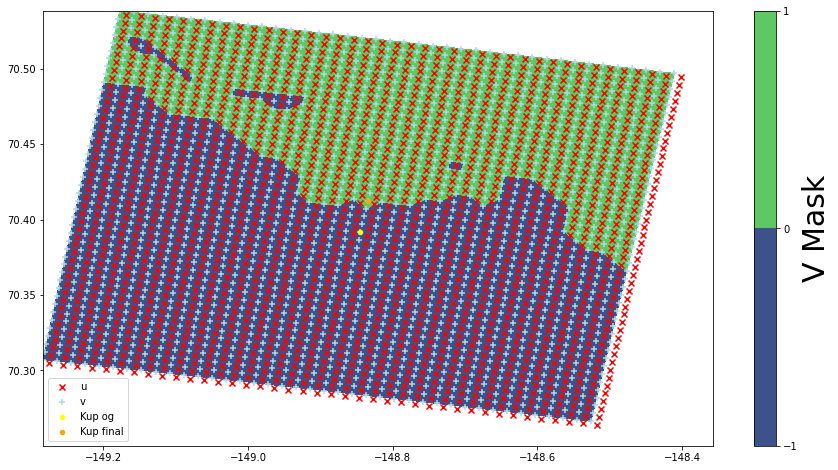

In [98]:
# Make a plot that is a scatter plot of u and v points
# Plot this point on the grid
# Zoom in to see if we are in the mask
fig2, ax2 = plt.subplots(figsize=(15,8))
# Plot the mask
cs2 = ax2.contourf(grid.lon_v[eta_kup_idx-20:eta_kup_idx+25, xi_kup_idx-20:xi_kup_idx+20].values, 
                    grid.lat_v[eta_kup_idx-20:eta_kup_idx+25, xi_kup_idx-20:xi_kup_idx+20].values, 
                    grid.mask_v[eta_kup_idx-20:eta_kup_idx+25, xi_kup_idx-20:xi_kup_idx+20].values, lev1)

# Plot the u points
ax2.scatter(grid.lon_u[eta_kup_idx-20:eta_kup_idx+25, xi_kup_idx-20:xi_kup_idx+20].values, 
            grid.lat_u[eta_kup_idx-20:eta_kup_idx+25, xi_kup_idx-20:xi_kup_idx+20].values,
            color='red', marker='x', label='u')

# Plot the v points
ax2.scatter(grid.lon_v[eta_kup_idx-20:eta_kup_idx+25, xi_kup_idx-20:xi_kup_idx+20].values, 
            grid.lat_v[eta_kup_idx-20:eta_kup_idx+25, xi_kup_idx-20:xi_kup_idx+20].values,
            color='lightblue', marker='+', label='v')


# Kuparuk
ax2.scatter(grid.lon_v[eta_kup_idx, xi_kup_idx].values, grid.lat_v[eta_kup_idx, xi_kup_idx].values, 
            marker='.', s=80, color='yellow', label='Kup og')

# Point 1 - v face
eta_kup_idx_test1 = 41 #40
xi_kup_idx_test1 = 242

ax2.scatter(grid.lon_v[eta_kup_idx_test1, xi_kup_idx_test1].values, 
            grid.lat_v[eta_kup_idx_test1, xi_kup_idx_test1].values, 
            marker='.', s=80, color='orange', label='Kup final')

ax2.legend()

cbar2 = plt.colorbar(cs2).set_label('V Mask', size=30)

In [99]:
# Check that these spots are in the mask
# Point 1 - v
print(grid.mask_v[eta_kup_idx_test1,xi_kup_idx_test1].values)
# If so, save it to the list of river indices (these indices are determined by the order in this notebook) = NOT robust
eta_riv_arr[13] = eta_kup_idx_test1
xi_riv_arr[13] = xi_kup_idx_test1

1.0


In [100]:
# Set the river_direction
# "river runoff grid-cell face flag"
# where river_direction:flag_values = "0, 1, 2" 
# river_direction:flag_meanings = "flow across u-face, flow across v-face, flow across w-face"
# Set this for each of the 5 points
riv_dir_kup1 = 1

# Add this to the list 
riv_direction_arr[13] = riv_dir_kup1

In [101]:
# Set river_transport which is the direction of the flow across the u or v face
# This is also where we put "river runoff vertically integrated mass transport"
# river_transport(river_time, river)

# Make a fake time series for each point
#Q_kup1 = np.full((time_tmp_len), 1000) # m3/s # 10

# Replace this fake time series with real data
Q_kup1 = (mean_river_dis.river_transport[182:307,5].values)/len_river_cells_kup

# Add this to the list 
riv_transport_arr[:,13] = Q_kup1

In [102]:
# Set river_vshape
# "sets the fractional distribution of the river_transport 
# among the vertical cells and must sum to 1.0 over the vertical"
# "If the river source is in shallow water several grid cells up a 
# river tributary then a simple uniform vertical distribution 
# (all river_Vshape values = 1/s_rho) usually works well"

# Do uniform distribution over all depths 
#riv_vshape_kup = np.full((s_rho_len), 1/s_rho_len)

# Read in the vshape for this cell
# Use the indices from above - these are u/v indices but v_shape 
# is n terms of rho indices but hopefully they are close enough 
# that it doesn't matter too much but keep note of this 
riv_vshape_kup = vshape_all[:, eta_kup_idx_test1, xi_kup_idx_test1]

# Add this to the array
riv_vshape_arr[:,13] = riv_vshape_kup

In [103]:
# Set river runoff potential temperature 
# river_temp(river_time, s_rho, river) 
# river_temp:long_name = "river runoff potential temperature" 
# river_temp:units = "Celsius" 
# river_temp:time = "river_time" 

# This looks like it can vary vertically and can be a timeseries 
#riv_temp_kup = np.full((time_tmp_len, s_rho_len), 11)
# Make this the same in each layer 
riv_temp_kup = np.empty((time_tmp_len, s_rho_len))
for i in range(s_rho_len):
    riv_temp_kup[:,i] = riv_temp

# Add this to the array 
riv_temp_arr[:,:,13] = riv_temp_kup

In [104]:
# Set the river runoff salinity
# river_salt(river_time, s_rho, river) 
# river_salt:long_name = "river runoff salinity" 
# river_salt:time = "river_time"
# units: PSS (nondimensional)

# Just like temp, this can vary vertically and over time
riv_salt_kup = np.full((time_tmp_len, s_rho_len), 0)

# Add this to the array
riv_salt_arr[:,:,13] = riv_salt_kup

In [105]:
# Set the river mud
# 'river_mud_'                                       ! Input
#   'river runoff suspended sediment concentration'
#   'kilogram meter-3'                               ! [kg/m3]
#   'river_sediment, scalar, series'
#   'river_time'

# --- Guesstimate Version ---
# # 10 kg/s / discharge m3/s = kg/m3, picking 10 as a random average 
# # for all rivers and all sediment classes
# # mud class 01
# riv_mud_01_kup = 10 / Q_kup1 # when there is real data, may need one for each cell
# #riv_mud_01_kup = np.full((time_tmp_len), 0.00001)

# # mud class 02
# riv_mud_02_kup = 10 / Q_kup1 # when there is real data, may need one for each cell
# #riv_mud_02_kup = np.full((time_tmp_len), 0.00001)

# --- Lamb and Toniolo 2016 Version ---
riv_mud_kup_tmp = calc_river_ssc(Q_kup1)
# Convert output from mg/L to kg/m3
riv_mud_kup = riv_mud_kup_tmp/1000

# Divide the total river sediment discharge by two 
# so that half belongs to each mud class
riv_mud_01_kup = riv_mud_kup/2
riv_mud_02_kup = riv_mud_kup/2

# Add these to the arrays (can definitely shorten this but oh well)
# mud 01
riv_mud_01_arr[:,13] = riv_mud_01_kup

# mud 02
riv_mud_02_arr[:,13] = riv_mud_02_kup

In [106]:
# Set the river sand
# 'river_sand_'                                      ! Input
#   'river runoff suspended sediment concentration'
#   'kilogram meter-3'                               ! [kg/m3]
#   'river_sediment, scalar, series'
#   'river_time'

# --- Guesstimate Version ---
# 10 kg/s / discharge m3/s = kg/m3, picking 10 as a random average 
# for all rivers and all sediment classes
# *Set all of these to 0 since sand might be too big to be carried by the river*

# sand class 01
riv_sand_01_kup = 0 / Q_kup1 # when there is real data, may need one for each cell
#riv_sand_01_kup = np.full((time_tmp_len), 0.0001)

# sand class 02
riv_sand_02_kup = 0 / Q_kup1 # when there is real data, may need one for each cell
#riv_sand_02_kup = np.full((time_tmp_len), 0.0001)

# sand class 03
riv_sand_03_kup = 0 / Q_kup1 # when there is real data, may need one for each cell
#riv_sand_03_kup = np.full((time_tmp_len), 0.0)

# Add this to the array
# sand 01 
riv_sand_01_arr[:,13] = riv_sand_01_kup

# sand 02
riv_sand_02_arr[:,13] = riv_sand_02_kup

# sand 03
riv_sand_03_arr[:,13] = riv_sand_03_kup

In [107]:
# Set the river id number
# This number will match the one in the info for the netcdf
# Kukpuk
riv_id_kup = 7

# Add this to the array
riv_id_arr[13] = riv_id_kup

In [108]:
# Set the river flag ('river runoff tracer flag')
# rdir.flag_values = '0, 1, 2, 3'
# rdir.flag_meanings = 'all tracers are off, only temperature is on, 
# only salinity is on, both temperature and salinity are on'
riv_flag_kup = 3

# Add this to the array
riv_flag_arr[13] = riv_flag_kup

## Fawn Creek 
Location: 70.4099, -148.7271  
Width: 300 m  
**This river did not have data in the RADR dataset so we are ignoring this one for now**

In [109]:
# Find this river in the mean discharge dataset - not in it since there are not data for Fawn Creek
print(mean_river_dis.rivers)

(1) Kalikpik, (2) Fish Creek, (3) Colville, (4) Sakonowyak, (5) Kukpuk, (6) Kuparuk, (7) Putuligayuk, (8) Sagavanirktok, (9) Staines (10) Canning, (11) Katakturuk, (12) Hulahula, (13) Jago, (14) Siksik


In [110]:
# # Fawn Creek (70.4099, -148.7271), 300 m
# # Set the number of cells it will take 
# # 300 m / 750 m = ~ 1 cells
# len_river_cells_faw = 1

# # Find it manually
# eta_faw_idx = 41
# xi_faw_idx = 248

# # Needs to be on u or v point, depending what makes sense here
# print('Fawn Lat v: ', grid.lat_v[eta_faw_idx, xi_faw_idx].values)
# print('Fawn Lon v: ', grid.lon_v[eta_faw_idx, xi_faw_idx].values)

In [111]:
# # Make a plot that is a scatter plot of u and v points
# # Plot this point on the grid
# # Zoom in to see if we are in the mask
# fig2, ax2 = plt.subplots(figsize=(15,8))
# # Plot the mask
# cs2 = ax2.contourf(grid.lon_v[eta_faw_idx-20:eta_faw_idx+25, xi_faw_idx-20:xi_faw_idx+20].values, 
#                     grid.lat_v[eta_faw_idx-20:eta_faw_idx+25, xi_faw_idx-20:xi_faw_idx+20].values, 
#                     grid.mask_v[eta_faw_idx-20:eta_faw_idx+25, xi_faw_idx-20:xi_faw_idx+20].values, lev1)

# # Plot the u points
# ax2.scatter(grid.lon_u[eta_faw_idx-20:eta_faw_idx+25, xi_faw_idx-20:xi_faw_idx+20].values, 
#             grid.lat_u[eta_faw_idx-20:eta_faw_idx+25, xi_faw_idx-20:xi_faw_idx+20].values,
#             color='red', marker='x', label='u')

# # Plot the v points
# ax2.scatter(grid.lon_v[eta_faw_idx-20:eta_faw_idx+25, xi_faw_idx-20:xi_faw_idx+20].values, 
#             grid.lat_v[eta_faw_idx-20:eta_faw_idx+25, xi_faw_idx-20:xi_faw_idx+20].values,
#             color='lightblue', marker='+', label='v')


# # Fawn
# ax2.scatter(grid.lon_v[eta_faw_idx, xi_faw_idx].values, grid.lat_v[eta_faw_idx, xi_faw_idx].values, 
#             marker='.', s=80, color='yellow', label='Faw og')

# # Point 1 - v face
# eta_faw_idx_test1 = 44 #43
# xi_faw_idx_test1 = 249

# ax2.scatter(grid.lon_v[eta_faw_idx_test1, xi_faw_idx_test1].values, 
#             grid.lat_v[eta_faw_idx_test1, xi_faw_idx_test1].values, 
#             marker='.', s=80, color='orange', label='Faw final')

# ax2.legend()

# cbar2 = plt.colorbar(cs2).set_label('V Mask', size=30)

In [112]:
# # Check that these spots are in the mask
# # Point 1 - v
# print(grid.mask_v[eta_faw_idx_test1,xi_faw_idx_test1].values)
# # If so, save it to the list of river indices (these indices are determined by the order in this notebook) = NOT robust
# eta_riv_arr[14] = eta_faw_idx_test1
# xi_riv_arr[14] = xi_faw_idx_test1

In [113]:
# # Set the river_direction
# # "river runoff grid-cell face flag"
# # where river_direction:flag_values = "0, 1, 2" 
# # river_direction:flag_meanings = "flow across u-face, flow across v-face, flow across w-face"
# # Set this for each of the 5 points
# riv_dir_faw1 = 1

# # Add this to the list 
# riv_direction_arr[14] = riv_dir_faw1

In [114]:
# # Set river_transport which is the direction of the flow across the u or v face
# # This is also where we put "river runoff vertically integrated mass transport"
# # river_transport(river_time, river)

# # Make a fake time series for each point
# Q_faw1 = np.full((time_tmp_len), 1000) # m3/s


# # Add this to the list 
# riv_transport_arr[:,14] = Q_faw1

In [115]:
# # Set river_vshape
# # "sets the fractional distribution of the river_transport 
# # among the vertical cells and must sum to 1.0 over the vertical"
# # "If the river source is in shallow water several grid cells up a 
# # river tributary then a simple uniform vertical distribution 
# # (all river_Vshape values = 1/s_rho) usually works well"

# # Do uniform distribution over all depths 
# riv_vshape_faw = np.full((s_rho_len), 1/s_rho_len)

# # Add this to the array
# riv_vshape_arr[:,14] = riv_vshape_faw

In [116]:
# # Set river runoff potential temperature 
# # river_temp(river_time, s_rho, river) 
# # river_temp:long_name = "river runoff potential temperature" 
# # river_temp:units = "Celsius" 
# # river_temp:time = "river_time" 

# # This looks like it can vary vertically and can be a timeseries 
# riv_temp_faw = np.full((time_tmp_len, s_rho_len), 11)

# # Add this to the array 
# riv_temp_arr[:,:,14] = riv_temp_faw

In [117]:
# # Set the river runoff salinity
# # river_salt(river_time, s_rho, river) 
# # river_salt:long_name = "river runoff salinity" 
# # river_salt:time = "river_time"
# # units: PSS (nondimensional)

# # Just like temp, this can vary vertically and over time
# riv_salt_faw = np.full((time_tmp_len, s_rho_len), 0)

# # Add this to the array
# riv_salt_arr[:,:,14] = riv_salt_faw

In [118]:
# # Set the river mud
# # 'river_mud_'                                       ! Input
# #   'river runoff suspended sediment concentration'
# #   'kilogram meter-3'                               ! [kg/m3]
# #   'river_sediment, scalar, series'
# #   'river_time'

# # --- Guesstimate Version ---
# # # 10 kg/s / discharge m3/s = kg/m3, picking 10 as a random average 
# # # for all rivers and all sediment classes
# # # mud class 01
# # riv_mud_01_faw = 10 / Q_faw1 # when there is real data, may need one for each cell
# # #riv_mud_01_faw = np.full((time_tmp_len), 0.00001)

# # # mud class 02
# # riv_mud_02_faw = 10 / Q_faw1 # when there is real data, may need one for each cell
# # #riv_mud_02_faw = np.full((time_tmp_len), 0.00001)

# # --- Lamb and Toniolo 2016 Version ---
# riv_mud_faw_tmp = calc_river_ssc(Q_faw1)
# # Convert output from mg/L to kg/m3
# riv_mud_faw = riv_mud_faw_tmp/1000

# # Divide the total river sediment discharge by two 
# # so that half belongs to each mud class
# riv_mud_01_faw = riv_mud_faw/2
# riv_mud_02_faw = riv_mud_faw/2

# # Add these to the arrays (can definitely shorten this but oh well)
# # mud 01
# riv_mud_01_arr[:,14] = riv_mud_01_faw

# # mud 02
# riv_mud_02_arr[:,14] = riv_mud_02_faw

In [119]:
# # Set the river sand
# # 'river_sand_'                                      ! Input
# #   'river runoff suspended sediment concentration'
# #   'kilogram meter-3'                               ! [kg/m3]
# #   'river_sediment, scalar, series'
# #   'river_time'

# # --- Guesstimate Version ---
# # 10 kg/s / discharge m3/s = kg/m3, picking 10 as a random average 
# # for all rivers and all sediment classes
# # *Set all of these to 0 since sand might be too big to be carried by the river*

# # sand class 01
# riv_sand_01_faw = 0 / Q_faw1 # when there is real data, may need one for each cell
# #riv_sand_01_faw = np.full((time_tmp_len), 0.0001)

# # sand class 02
# riv_sand_02_faw = 0 / Q_faw1 # when there is real data, may need one for each cell
# #riv_sand_02_faw = np.full((time_tmp_len), 0.0001)

# # Add this to the array
# # sand 01 
# riv_sand_01_arr[:,14] = riv_sand_01_faw

# # sand 02
# riv_sand_02_arr[:,14] = riv_sand_02_faw

In [120]:
# # Set the river id number
# # This number will match the one in the info for the netcdf
# # Fawn
# riv_id_faw = 8

# # Add this to the array
# riv_id_arr[14] = riv_id_faw

In [121]:
# # Set the river flag ('river runoff tracer flag')
# # rdir.flag_values = '0, 1, 2, 3'
# # rdir.flag_meanings = 'all tracers are off, only temperature is on, 
# # only salinity is on, both temperature and salinity are on'
# riv_flag_faw = 3

# # Add this to the array
# riv_flag_arr[14] = riv_flag_faw

## Putuligayuk River 
Location: 70.3113, -148.4792  
Width: 409 m

In [122]:
# Find this river in the mean discharge dataset
print(mean_river_dis.rivers)

(1) Kalikpik, (2) Fish Creek, (3) Colville, (4) Sakonowyak, (5) Kukpuk, (6) Kuparuk, (7) Putuligayuk, (8) Sagavanirktok, (9) Staines (10) Canning, (11) Katakturuk, (12) Hulahula, (13) Jago, (14) Siksik


In [123]:
# Putuligayuk River (70.3113, -148.4792), 409 m
# Set the number of cells it will take 
# 409 m / 750 m = ~ 1 cells
len_river_cells_put = 1

# Find it manually
eta_put_idx = 26
xi_put_idx = 263

# Needs to be on u or v point, depending what makes sense here
print('Putuligayuk Lat v: ', grid.lat_v[eta_put_idx, xi_put_idx].values)
print('Putuligayuk Lon v: ', grid.lon_v[eta_put_idx, xi_put_idx].values)

Putuligayuk Lat v:  70.31122214816405
Putuligayuk Lon v:  -148.46387737642374


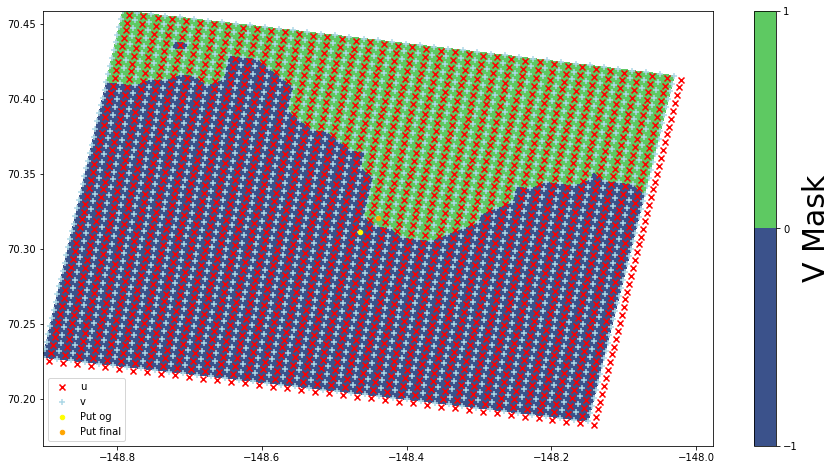

In [124]:
# Make a plot that is a scatter plot of u and v points
# Plot this point on the grid
# Zoom in to see if we are in the mask
fig2, ax2 = plt.subplots(figsize=(15,8))
# Plot the mask
cs2 = ax2.contourf(grid.lon_v[eta_put_idx-20:eta_put_idx+25, xi_put_idx-20:xi_put_idx+20].values, 
                    grid.lat_v[eta_put_idx-20:eta_put_idx+25, xi_put_idx-20:xi_put_idx+20].values, 
                    grid.mask_v[eta_put_idx-20:eta_put_idx+25, xi_put_idx-20:xi_put_idx+20].values, lev1)

# Plot the u points
ax2.scatter(grid.lon_u[eta_put_idx-20:eta_put_idx+25, xi_put_idx-20:xi_put_idx+20].values, 
            grid.lat_u[eta_put_idx-20:eta_put_idx+25, xi_put_idx-20:xi_put_idx+20].values,
            color='red', marker='x', label='u')

# Plot the v points
ax2.scatter(grid.lon_v[eta_put_idx-20:eta_put_idx+25, xi_put_idx-20:xi_put_idx+20].values, 
            grid.lat_v[eta_put_idx-20:eta_put_idx+25, xi_put_idx-20:xi_put_idx+20].values,
            color='lightblue', marker='+', label='v')


# Putuligayuk
ax2.scatter(grid.lon_v[eta_put_idx, xi_put_idx].values, grid.lat_v[eta_put_idx, xi_put_idx].values, 
            marker='.', s=80, color='yellow', label='Put og')

# Point 1 - v face
eta_put_idx_test1 = 28 #27
xi_put_idx_test1 = 264

ax2.scatter(grid.lon_v[eta_put_idx_test1, xi_put_idx_test1].values, 
            grid.lat_v[eta_put_idx_test1, xi_put_idx_test1].values, 
            marker='.', s=80, color='orange', label='Put final')

ax2.legend()

cbar2 = plt.colorbar(cs2).set_label('V Mask', size=30)

In [125]:
# Check that these spots are in the mask
# Point 1 - v
print(grid.mask_v[eta_put_idx_test1,xi_put_idx_test1].values)
# If so, save it to the list of river indices (these indices are determined by the order in this notebook) = NOT robust
eta_riv_arr[14] = eta_put_idx_test1
xi_riv_arr[14] = xi_put_idx_test1

1.0


In [126]:
# Set the river_direction
# "river runoff grid-cell face flag"
# where river_direction:flag_values = "0, 1, 2" 
# river_direction:flag_meanings = "flow across u-face, flow across v-face, flow across w-face"
# Set this for each of the 5 points
riv_dir_put1 = 1

# Add this to the list 
riv_direction_arr[14] = riv_dir_put1

In [127]:
# Set river_transport which is the direction of the flow across the u or v face
# This is also where we put "river runoff vertically integrated mass transport"
# river_transport(river_time, river)

# Make a fake time series for each point
#Q_put1 = np.full((time_tmp_len), 1000) # m3/s

# Replace this fake time series with real data
Q_put1 = (mean_river_dis.river_transport[182:307,6].values)/len_river_cells_put

# Add this to the list 
riv_transport_arr[:,14] = Q_put1

In [128]:
# Set river_vshape
# "sets the fractional distribution of the river_transport 
# among the vertical cells and must sum to 1.0 over the vertical"
# "If the river source is in shallow water several grid cells up a 
# river tributary then a simple uniform vertical distribution 
# (all river_Vshape values = 1/s_rho) usually works well"

# Do uniform distribution over all depths 
#riv_vshape_put = np.full((s_rho_len), 1/s_rho_len)

# Read in the vshape for this cell
# Use the indices from above - these are u/v indices but v_shape 
# is n terms of rho indices but hopefully they are close enough 
# that it doesn't matter too much but keep note of this 
riv_vshape_put = vshape_all[:, eta_put_idx_test1, xi_put_idx_test1]

# Add this to the array
riv_vshape_arr[:,14] = riv_vshape_put

In [129]:
# Set river runoff potential temperature 
# river_temp(river_time, s_rho, river) 
# river_temp:long_name = "river runoff potential temperature" 
# river_temp:units = "Celsius" 
# river_temp:time = "river_time" 

# This looks like it can vary vertically and can be a timeseries 
#riv_temp_put = np.full((time_tmp_len, s_rho_len), 11)
# Make this the same in each layer 
riv_temp_put = np.empty((time_tmp_len, s_rho_len))
for i in range(s_rho_len):
    riv_temp_put[:,i] = riv_temp

# Add this to the array 
riv_temp_arr[:,:,14] = riv_temp_put

In [130]:
# Set the river runoff salinity
# river_salt(river_time, s_rho, river) 
# river_salt:long_name = "river runoff salinity" 
# river_salt:time = "river_time"
# units: PSS (nondimensional)

# Just like temp, this can vary vertically and over time
riv_salt_put = np.full((time_tmp_len, s_rho_len), 0)

# Add this to the array
riv_salt_arr[:,:,14] = riv_salt_put

In [131]:
# Set the river mud
# 'river_mud_'                                       ! Input
#   'river runoff suspended sediment concentration'
#   'kilogram meter-3'                               ! [kg/m3]
#   'river_sediment, scalar, series'
#   'river_time'

# --- Guesstimate Version ---
# # 10 kg/s / discharge m3/s = kg/m3, picking 10 as a random average 
# # for all rivers and all sediment classes
# # mud class 01
# riv_mud_01_put = 10 / Q_put1 # when there is real data, may need one for each cell
# #riv_mud_01_put = np.full((time_tmp_len), 0.00001)

# # mud class 02
# riv_mud_02_put = 10 / Q_put1 # when there is real data, may need one for each cell
# #riv_mud_02_put = np.full((time_tmp_len), 0.00001)

# --- Lamb and Toniolo 2016 Version ---
riv_mud_put_tmp = calc_river_ssc(Q_put1)
# Convert output from mg/L to kg/m3
riv_mud_put = riv_mud_put_tmp/1000

# Divide the total river sediment discharge by two 
# so that half belongs to each mud class
riv_mud_01_put = riv_mud_put/2
riv_mud_02_put = riv_mud_put/2

# Add these to the arrays (can definitely shorten this but oh well)
# mud 01
riv_mud_01_arr[:,14] = riv_mud_01_put

# mud 02
riv_mud_02_arr[:,14] = riv_mud_02_put

In [132]:
# Set the river sand
# 'river_sand_'                                      ! Input
#   'river runoff suspended sediment concentration'
#   'kilogram meter-3'                               ! [kg/m3]
#   'river_sediment, scalar, series'
#   'river_time'

# --- Guesstimate Version ---
# 10 kg/s / discharge m3/s = kg/m3, picking 10 as a random average 
# for all rivers and all sediment classes
# *Set all of these to 0 since sand might be too big to be carried by the river*

# sand class 01
riv_sand_01_put = 0 / Q_put1 # when there is real data, may need one for each cell
#riv_sand_01_put = np.full((time_tmp_len), 0.0001)

# sand class 02
riv_sand_02_put = 0 / Q_put1 # when there is real data, may need one for each cell
#riv_sand_02_put = np.full((time_tmp_len), 0.0001)

# sand class 03
riv_sand_03_put = 0 / Q_put1 # when there is real data, may need one for each cell
#riv_sand_03_put = np.full((time_tmp_len), 0.0)

# Add this to the array
# sand 01 
riv_sand_01_arr[:,14] = riv_sand_01_put

# sand 02
riv_sand_02_arr[:,14] = riv_sand_02_put

# sand 03
riv_sand_03_arr[:,14] = riv_sand_03_put

In [133]:
# Set the river id number
# This number will match the one in the info for the netcdf
# Fawn
riv_id_put = 8 #9

# Add this to the array
riv_id_arr[14] = riv_id_put

In [134]:
# Set the river flag ('river runoff tracer flag')
# rdir.flag_values = '0, 1, 2, 3'
# rdir.flag_meanings = 'all tracers are off, only temperature is on, 
# only salinity is on, both temperature and salinity are on'
riv_flag_put = 3

# Add this to the array
riv_flag_arr[14] = riv_flag_put

## Canning River (splits into two neat coast):  
### Staines River   
Location: 70.1419, -145.9989  
Width: 892.9 m

In [135]:
# Find this river in the mean discharge dataset
print(mean_river_dis.rivers)

(1) Kalikpik, (2) Fish Creek, (3) Colville, (4) Sakonowyak, (5) Kukpuk, (6) Kuparuk, (7) Putuligayuk, (8) Sagavanirktok, (9) Staines (10) Canning, (11) Katakturuk, (12) Hulahula, (13) Jago, (14) Siksik


In [136]:
# Staines River (70.1419, -145.9989), 892.9 m
# Set the number of cells it will take 
# 892.9 m / 750 m = ~ 1 cells
len_river_cells_sta = 1

# Find it manually
eta_sta_idx = 24
xi_sta_idx = 392

# Needs to be on u or v point, depending what makes sense here
print('Staines Lat v: ', grid.lat_v[eta_sta_idx, xi_sta_idx].values)
print('Staines Lon v: ', grid.lon_v[eta_sta_idx, xi_sta_idx].values)

Staines Lat v:  70.14066729098846
Staines Lon v:  -145.98518822035305


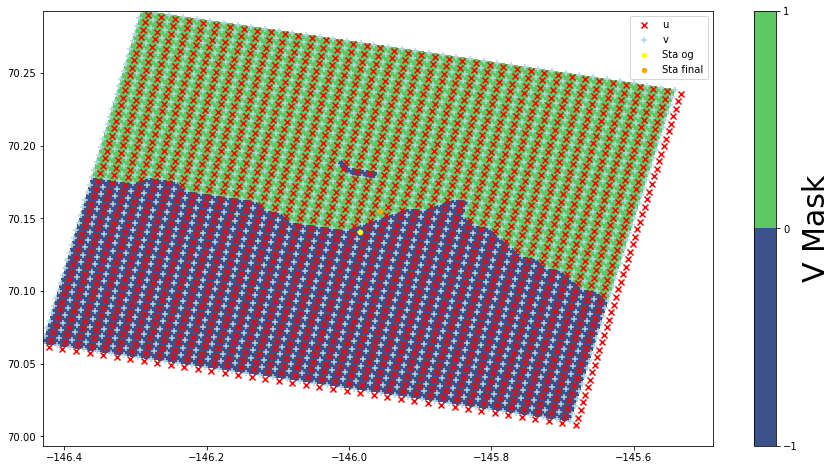

In [137]:
# Make a plot that is a scatter plot of u and v points
# Plot this point on the grid
# Zoom in to see if we are in the mask
fig2, ax2 = plt.subplots(figsize=(15,8))
# Plot the mask
cs2 = ax2.contourf(grid.lon_v[eta_sta_idx-20:eta_sta_idx+25, xi_sta_idx-20:xi_sta_idx+20].values, 
                    grid.lat_v[eta_sta_idx-20:eta_sta_idx+25, xi_sta_idx-20:xi_sta_idx+20].values, 
                    grid.mask_v[eta_sta_idx-20:eta_sta_idx+25, xi_sta_idx-20:xi_sta_idx+20].values, lev1)

# Plot the u points
ax2.scatter(grid.lon_u[eta_sta_idx-20:eta_sta_idx+25, xi_sta_idx-20:xi_sta_idx+20].values, 
            grid.lat_u[eta_sta_idx-20:eta_sta_idx+25, xi_sta_idx-20:xi_sta_idx+20].values,
            color='red', marker='x', label='u')

# Plot the v points
ax2.scatter(grid.lon_v[eta_sta_idx-20:eta_sta_idx+25, xi_sta_idx-20:xi_sta_idx+20].values, 
            grid.lat_v[eta_sta_idx-20:eta_sta_idx+25, xi_sta_idx-20:xi_sta_idx+20].values,
            color='lightblue', marker='+', label='v')


# Staines
ax2.scatter(grid.lon_v[eta_sta_idx, xi_sta_idx].values, grid.lat_v[eta_sta_idx, xi_sta_idx].values, 
            marker='.', s=80, color='yellow', label='Sta og')

# Point 1 - v face
eta_sta_idx_test1 = 27 #26
xi_sta_idx_test1 = 393

ax2.scatter(grid.lon_v[eta_sta_idx_test1, xi_sta_idx_test1].values, 
            grid.lat_v[eta_sta_idx_test1, xi_sta_idx_test1].values, 
            marker='.', s=80, color='orange', label='Sta final')

ax2.legend()

cbar2 = plt.colorbar(cs2).set_label('V Mask', size=30)

In [138]:
# Check that these spots are in the mask
# Point 1 - v
print(grid.mask_v[eta_sta_idx_test1,xi_sta_idx_test1].values)
# If so, save it to the list of river indices (these indices are determined by the order in this notebook) = NOT robust
eta_riv_arr[15] = eta_sta_idx_test1
xi_riv_arr[15] = xi_sta_idx_test1

1.0


In [139]:
# Set the river_direction
# "river runoff grid-cell face flag"
# where river_direction:flag_values = "0, 1, 2" 
# river_direction:flag_meanings = "flow across u-face, flow across v-face, flow across w-face"
# Set this for each of the 5 points
riv_dir_sta1 = 1

# Add this to the list 
riv_direction_arr[15] = riv_dir_sta1

In [140]:
# Set river_transport which is the direction of the flow across the u or v face
# This is also where we put "river runoff vertically integrated mass transport"
# river_transport(river_time, river)

# Make a fake time series for each point
#Q_sta1 = np.full((time_tmp_len), 1000) # m3/s # 15

# Replace this fake time series with real data
Q_sta1 = (mean_river_dis.river_transport[182:307,8].values)/len_river_cells_sta

# Add this to the list 
riv_transport_arr[:,15] = Q_sta1

In [141]:
# Set river_vshape
# "sets the fractional distribution of the river_transport 
# among the vertical cells and must sum to 1.0 over the vertical"
# "If the river source is in shallow water several grid cells up a 
# river tributary then a simple uniform vertical distribution 
# (all river_Vshape values = 1/s_rho) usually works well"

# Do uniform distribution over all depths 
#riv_vshape_sta = np.full((s_rho_len), 1/s_rho_len)

# Read in the vshape for this cell
# Use the indices from above - these are u/v indices but v_shape 
# is n terms of rho indices but hopefully they are close enough 
# that it doesn't matter too much but keep note of this 
riv_vshape_sta = vshape_all[:, eta_sta_idx_test1, xi_sta_idx_test1]

# Add this to the array
riv_vshape_arr[:,15] = riv_vshape_sta

In [142]:
# Set river runoff potential temperature 
# river_temp(river_time, s_rho, river) 
# river_temp:long_name = "river runoff potential temperature" 
# river_temp:units = "Celsius" 
# river_temp:time = "river_time" 

# This looks like it can vary vertically and can be a timeseries 
#riv_temp_sta = np.full((time_tmp_len, s_rho_len), 11)
# Make this the same in each layer 
riv_temp_sta = np.empty((time_tmp_len, s_rho_len))
for i in range(s_rho_len):
    riv_temp_sta[:,i] = riv_temp

# Add this to the array 
riv_temp_arr[:,:,15] = riv_temp_sta

In [143]:
# Set the river runoff salinity
# river_salt(river_time, s_rho, river) 
# river_salt:long_name = "river runoff salinity" 
# river_salt:time = "river_time"
# units: PSS (nondimensional)

# Just like temp, this can vary vertically and over time
riv_salt_sta = np.full((time_tmp_len, s_rho_len), 0)

# Add this to the array
riv_salt_arr[:,:,15] = riv_salt_sta

In [144]:
# Set the river mud
# 'river_mud_'                                       ! Input
#   'river runoff suspended sediment concentration'
#   'kilogram meter-3'                               ! [kg/m3]
#   'river_sediment, scalar, series'
#   'river_time'

# --- Guesstimate Version ---
# # 10 kg/s / discharge m3/s = kg/m3, picking 10 as a random average 
# # for all rivers and all sediment classes
# # mud class 01
# riv_mud_01_sta = 10 / Q_sta1 # when there is real data, may need one for each cell
# #riv_mud_01_sta = np.full((time_tmp_len), 0.00001)

# # mud class 02
# riv_mud_02_sta = 10 / Q_sta1 # when there is real data, may need one for each cell
# #riv_mud_02_sta = np.full((time_tmp_len), 0.00001)

# --- Lamb and Toniolo 2016 Version ---
riv_mud_sta_tmp = calc_river_ssc(Q_sta1)
# Convert output from mg/L to kg/m3
riv_mud_sta = riv_mud_sta_tmp/1000

# Divide the total river sediment discharge by two 
# so that half belongs to each mud class
riv_mud_01_sta = riv_mud_sta/2
riv_mud_02_sta = riv_mud_sta/2

# Add these to the arrays (can definitely shorten this but oh well)
# mud 01
riv_mud_01_arr[:,15] = riv_mud_01_sta

# mud 02
riv_mud_02_arr[:,15] = riv_mud_02_sta

In [145]:
# Set the river sand
# 'river_sand_'                                      ! Input
#   'river runoff suspended sediment concentration'
#   'kilogram meter-3'                               ! [kg/m3]
#   'river_sediment, scalar, series'
#   'river_time'

# --- Guesstimate Version ---
# 10 kg/s / discharge m3/s = kg/m3, picking 10 as a random average 
# for all rivers and all sediment classes
# *Set all of these to 0 since sand might be too big to be carried by the river*

# sand class 01
riv_sand_01_sta = 0 / Q_sta1 # when there is real data, may need one for each cell
#riv_sand_01_sta = np.full((time_tmp_len), 0.0001)

# sand class 02
riv_sand_02_sta = 0 / Q_sta1 # when there is real data, may need one for each cell
#riv_sand_02_sta = np.full((time_tmp_len), 0.0001)

# sand class 03
riv_sand_03_sta = 0 / Q_sta1 # when there is real data, may need one for each cell
#riv_sand_03_sta = np.full((time_tmp_len), 0.0)

# Add this to the array
# sand 01 
riv_sand_01_arr[:,15] = riv_sand_01_sta

# sand 02
riv_sand_02_arr[:,15] = riv_sand_02_sta

# sand 03
riv_sand_03_arr[:,15] = riv_sand_03_sta

In [146]:
# Set the river id number
# This number will match the one in the info for the netcdf
# Fawn
riv_id_sta = 9 #10

# Add this to the array
riv_id_arr[15] = riv_id_sta

In [147]:
# Set the river flag ('river runoff tracer flag')
# rdir.flag_values = '0, 1, 2, 3'
# rdir.flag_meanings = 'all tracers are off, only temperature is on, 
# only salinity is on, both temperature and salinity are on'
riv_flag_sta = 3

# Add this to the array
riv_flag_arr[15] = riv_flag_sta

### Canning River  
Location: 70.061, -145.5553  
Width: 1070 m

In [148]:
# Find this river in the mean discharge dataset
print(mean_river_dis.rivers)

(1) Kalikpik, (2) Fish Creek, (3) Colville, (4) Sakonowyak, (5) Kukpuk, (6) Kuparuk, (7) Putuligayuk, (8) Sagavanirktok, (9) Staines (10) Canning, (11) Katakturuk, (12) Hulahula, (13) Jago, (14) Siksik


In [149]:
# Canning River (70.061, -145.5553), 1070 m
# Set the number of cells it will take 
# 1070 m / 750 m = 1.43 ~ 1 cells
len_river_cells_can = 1

# Find it manually
eta_can_idx = 15
xi_can_idx = 416

# Needs to be on u or v point, depending what makes sense here
print('Canning Lat v: ', grid.lat_v[eta_can_idx, xi_can_idx].values)
print('Canning Lon v: ', grid.lon_v[eta_can_idx, xi_can_idx].values)

Canning Lat v:  70.06024972504456
Canning Lon v:  -145.55802030929465


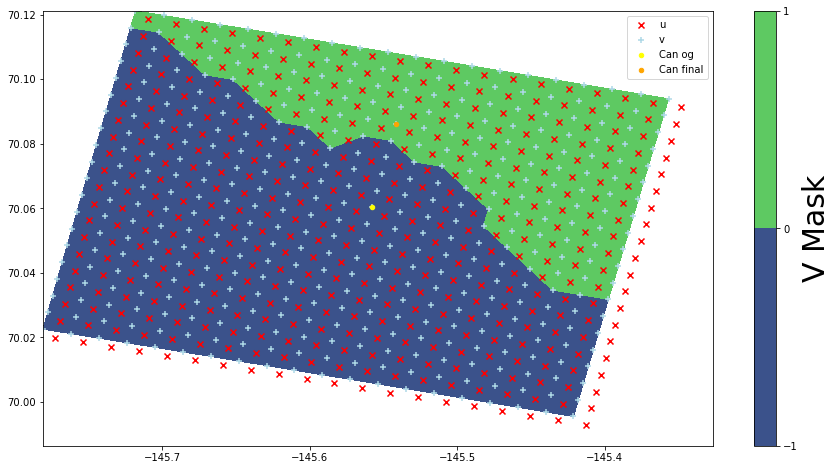

In [150]:
# Make a plot that is a scatter plot of u and v points
# Plot this point on the grid
# Zoom in to see if we are in the mask
fig2, ax2 = plt.subplots(figsize=(15,8))
# Plot the mask
cs2 = ax2.contourf(grid.lon_v[eta_can_idx-10:eta_can_idx+10, xi_can_idx-10:xi_can_idx+10].values, 
                    grid.lat_v[eta_can_idx-10:eta_can_idx+10, xi_can_idx-10:xi_can_idx+10].values, 
                    grid.mask_v[eta_can_idx-10:eta_can_idx+10, xi_can_idx-10:xi_can_idx+10].values, lev1)

# Plot the u points
ax2.scatter(grid.lon_u[eta_can_idx-10:eta_can_idx+10, xi_can_idx-10:xi_can_idx+10].values, 
            grid.lat_u[eta_can_idx-10:eta_can_idx+10, xi_can_idx-10:xi_can_idx+10].values,
            color='red', marker='x', label='u')

# Plot the v points
ax2.scatter(grid.lon_v[eta_can_idx-10:eta_can_idx+10, xi_can_idx-10:xi_can_idx+10].values, 
            grid.lat_v[eta_can_idx-10:eta_can_idx+10, xi_can_idx-10:xi_can_idx+10].values,
            color='lightblue', marker='+', label='v')


# Canning
ax2.scatter(grid.lon_v[eta_can_idx, xi_can_idx].values, grid.lat_v[eta_can_idx, xi_can_idx].values, 
            marker='.', s=80, color='yellow', label='Can og')

# Point 1 - v face
eta_can_idx_test1 = 20 #19
xi_can_idx_test1 = 416

ax2.scatter(grid.lon_v[eta_can_idx_test1, xi_can_idx_test1].values, 
            grid.lat_v[eta_can_idx_test1, xi_can_idx_test1].values, 
            marker='.', s=80, color='orange', label='Can final')

ax2.legend()

cbar2 = plt.colorbar(cs2).set_label('V Mask', size=30)

In [151]:
# Check that these spots are in the mask
# Point 1 - v
print(grid.mask_v[eta_can_idx_test1,xi_can_idx_test1].values)
# If so, save it to the list of river indices (these indices are determined by the order in this notebook) = NOT robust
eta_riv_arr[16] = eta_can_idx_test1
xi_riv_arr[16] = xi_can_idx_test1

1.0


In [152]:
# Set the river_direction
# "river runoff grid-cell face flag"
# where river_direction:flag_values = "0, 1, 2" 
# river_direction:flag_meanings = "flow across u-face, flow across v-face, flow across w-face"
# Set this for each of the 5 points
riv_dir_can1 = 1

# Add this to the list 
riv_direction_arr[16] = riv_dir_can1

In [153]:
# Set river_transport which is the direction of the flow across the u or v face
# This is also where we put "river runoff vertically integrated mass transport"
# river_transport(river_time, river)

# Make a fake time series for each point
#Q_can1 = np.full((time_tmp_len), 1000) # m3/s # 100

# Replace this fake time series with real data
Q_can1 = (mean_river_dis.river_transport[182:307,9].values)/len_river_cells_can

# Add this to the list 
riv_transport_arr[:,16] = Q_can1

In [154]:
# Set river_vshape
# "sets the fractional distribution of the river_transport 
# among the vertical cells and must sum to 1.0 over the vertical"
# "If the river source is in shallow water several grid cells up a 
# river tributary then a simple uniform vertical distribution 
# (all river_Vshape values = 1/s_rho) usually works well"

# Do uniform distribution over all depths 
#riv_vshape_can = np.full((s_rho_len), 1/s_rho_len)

# Read in the vshape for this cell
# Use the indices from above - these are u/v indices but v_shape 
# is n terms of rho indices but hopefully they are close enough 
# that it doesn't matter too much but keep note of this 
riv_vshape_can = vshape_all[:, eta_can_idx_test1, xi_can_idx_test1]

# Add this to the array
riv_vshape_arr[:,16] = riv_vshape_can

In [155]:
# Set river runoff potential temperature 
# river_temp(river_time, s_rho, river) 
# river_temp:long_name = "river runoff potential temperature" 
# river_temp:units = "Celsius" 
# river_temp:time = "river_time" 

# This looks like it can vary vertically and can be a timeseries 
#riv_temp_can = np.full((time_tmp_len, s_rho_len), 11)
# Make this the same in each layer 
riv_temp_can = np.empty((time_tmp_len, s_rho_len))
for i in range(s_rho_len):
    riv_temp_can[:,i] = riv_temp

# Add this to the array 
riv_temp_arr[:,:,16] = riv_temp_can

In [156]:
# Set the river runoff salinity
# river_salt(river_time, s_rho, river) 
# river_salt:long_name = "river runoff salinity" 
# river_salt:time = "river_time"
# units: PSS (nondimensional)

# Just like temp, this can vary vertically and over time
riv_salt_can = np.full((time_tmp_len, s_rho_len), 0)

# Add this to the array
riv_salt_arr[:,:,16] = riv_salt_can

In [157]:
# Set the river mud
# 'river_mud_'                                       ! Input
#   'river runoff suspended sediment concentration'
#   'kilogram meter-3'                               ! [kg/m3]
#   'river_sediment, scalar, series'
#   'river_time'

# --- Guesstimate Version ---
# # 10 kg/s / discharge m3/s = kg/m3, picking 10 as a random average 
# # for all rivers and all sediment classes
# # mud class 01
# riv_mud_01_can = 10 / Q_can1 # when there is real data, may need one for each cell
# #riv_mud_01_can = np.full((time_tmp_len), 0.00001)

# # mud class 02
# riv_mud_02_can = 10 / Q_can1 # when there is real data, may need one for each cell
# #riv_mud_02_can = np.full((time_tmp_len), 0.00001)

# --- Lamb and Toniolo 2016 Version ---
riv_mud_can_tmp = calc_river_ssc(Q_can1)
# Convert output from mg/L to kg/m3
riv_mud_can = riv_mud_can_tmp/1000

# Divide the total river sediment discharge by two 
# so that half belongs to each mud class
riv_mud_01_can = riv_mud_can/2
riv_mud_02_can = riv_mud_can/2

# Add these to the arrays (can definitely shorten this but oh well)
# mud 01
riv_mud_01_arr[:,16] = riv_mud_01_can

# mud 02
riv_mud_02_arr[:,16] = riv_mud_02_can

In [158]:
# Set the river sand
# 'river_sand_'                                      ! Input
#   'river runoff suspended sediment concentration'
#   'kilogram meter-3'                               ! [kg/m3]
#   'river_sediment, scalar, series'
#   'river_time'

# --- Guesstimate Version ---
# 10 kg/s / discharge m3/s = kg/m3, picking 10 as a random average 
# for all rivers and all sediment classes
# *Set all of these to 0 since sand might be too big to be carried by the river*

# sand class 01
riv_sand_01_can = 0 / Q_can1 # when there is real data, may need one for each cell
#riv_sand_01_can = np.full((time_tmp_len), 0.0001)

# sand class 02
riv_sand_02_can = 0 / Q_can1 # when there is real data, may need one for each cell
#riv_sand_02_can = np.full((time_tmp_len), 0.0001)

# sand class 03
riv_sand_03_can = 0 / Q_can1 # when there is real data, may need one for each cell
#riv_sand_03_can = np.full((time_tmp_len), 0.0)

# Add this to the array
# sand 01 
riv_sand_01_arr[:,16] = riv_sand_01_can

# sand 02
riv_sand_02_arr[:,16] = riv_sand_02_can

# sand 03
riv_sand_03_arr[:,16] = riv_sand_03_can

In [159]:
# Set the river id number
# This number will match the one in the info for the netcdf
# Fawn
riv_id_can = 10 #11

# Add this to the array
riv_id_arr[16] = riv_id_can

In [160]:
# Set the river flag ('river runoff tracer flag')
# rdir.flag_values = '0, 1, 2, 3'
# rdir.flag_meanings = 'all tracers are off, only temperature is on, 
# only salinity is on, both temperature and salinity are on'
riv_flag_can = 3

# Add this to the array
riv_flag_arr[16] = riv_flag_can

## Katakturuk River (splits into two near coast but keeps the same name; using only the larger one):  
Location: 69.976, -144.9958  
Width: 265 m

In [161]:
# Find this river in the mean discharge dataset
print(mean_river_dis.rivers)

(1) Kalikpik, (2) Fish Creek, (3) Colville, (4) Sakonowyak, (5) Kukpuk, (6) Kuparuk, (7) Putuligayuk, (8) Sagavanirktok, (9) Staines (10) Canning, (11) Katakturuk, (12) Hulahula, (13) Jago, (14) Siksik


In [162]:
# Katakturuk River (69.976, -144.9958), 265 m
# Set the number of cells it will take 
# 265 m / 750 m = ~ 1 cells
len_river_cells_kat = 1

# Find it manually
eta_kat_idx = 7
xi_kat_idx = 447

# Needs to be on u or v point, depending what makes sense here
print('Katakturuk Lat v: ', grid.lat_v[eta_kat_idx, xi_kat_idx].values)
print('Katakturuk Lon v: ', grid.lon_v[eta_kat_idx, xi_kat_idx].values)

Katakturuk Lat v:  69.9735534947528
Katakturuk Lon v:  -144.99886088516104


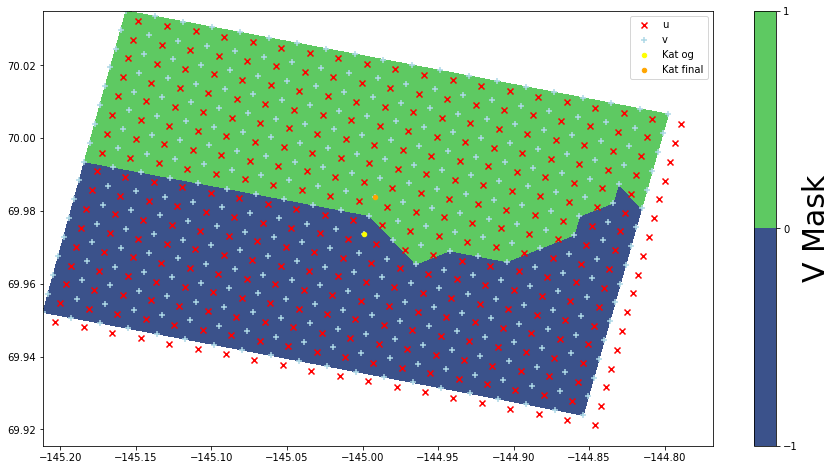

In [163]:
# Make a plot that is a scatter plot of u and v points
# Plot this point on the grid
# Zoom in to see if we are in the mask
fig2, ax2 = plt.subplots(figsize=(15,8))
# Plot the mask
cs2 = ax2.contourf(grid.lon_v[eta_kat_idx-7:eta_kat_idx+10, xi_kat_idx-10:xi_kat_idx+10].values, 
                    grid.lat_v[eta_kat_idx-7:eta_kat_idx+10, xi_kat_idx-10:xi_kat_idx+10].values, 
                    grid.mask_v[eta_kat_idx-7:eta_kat_idx+10, xi_kat_idx-10:xi_kat_idx+10].values, lev1)

# Plot the u points
ax2.scatter(grid.lon_u[eta_kat_idx-7:eta_kat_idx+10, xi_kat_idx-10:xi_kat_idx+10].values, 
            grid.lat_u[eta_kat_idx-7:eta_kat_idx+10, xi_kat_idx-10:xi_kat_idx+10].values,
            color='red', marker='x', label='u')

# Plot the v points
ax2.scatter(grid.lon_v[eta_kat_idx-7:eta_kat_idx+10, xi_kat_idx-10:xi_kat_idx+10].values, 
            grid.lat_v[eta_kat_idx-7:eta_kat_idx+10, xi_kat_idx-10:xi_kat_idx+10].values,
            color='lightblue', marker='+', label='v')


# Katakturuk
ax2.scatter(grid.lon_v[eta_kat_idx, xi_kat_idx].values, grid.lat_v[eta_kat_idx, xi_kat_idx].values, 
            marker='.', s=80, color='yellow', label='Kat og')

# Point 1 - v face
eta_kat_idx_test1 = 9 #8
xi_kat_idx_test1 = 447

ax2.scatter(grid.lon_v[eta_kat_idx_test1, xi_kat_idx_test1].values, 
            grid.lat_v[eta_kat_idx_test1, xi_kat_idx_test1].values, 
            marker='.', s=80, color='orange', label='Kat final')

ax2.legend()

cbar2 = plt.colorbar(cs2).set_label('V Mask', size=30)

In [164]:
# Check that these spots are in the mask
# Point 1 - v
print(grid.mask_v[eta_kat_idx_test1,xi_kat_idx_test1].values)
# If so, save it to the list of river indices (these indices are determined by the order in this notebook) = NOT robust
eta_riv_arr[17] = eta_kat_idx_test1
xi_riv_arr[17] = xi_kat_idx_test1

1.0


In [165]:
# Set the river_direction
# "river runoff grid-cell face flag"
# where river_direction:flag_values = "0, 1, 2" 
# river_direction:flag_meanings = "flow across u-face, flow across v-face, flow across w-face"
# Set this for each of the 5 points
riv_dir_kat1 = 1

# Add this to the list 
riv_direction_arr[17] = riv_dir_kat1

In [166]:
# Set river_transport which is the direction of the flow across the u or v face
# This is also where we put "river runoff vertically integrated mass transport"
# river_transport(river_time, river)

# Make a fake time series for each point
#Q_kat1 = np.full((time_tmp_len), 1000) # m3/s # 30

# Replace this fake time series with real data
Q_kat1 = (mean_river_dis.river_transport[182:307,10].values)/len_river_cells_kat

# Add this to the list 
riv_transport_arr[:,17] = Q_kat1

In [167]:
# Set river_vshape
# "sets the fractional distribution of the river_transport 
# among the vertical cells and must sum to 1.0 over the vertical"
# "If the river source is in shallow water several grid cells up a 
# river tributary then a simple uniform vertical distribution 
# (all river_Vshape values = 1/s_rho) usually works well"

# Do uniform distribution over all depths 
#riv_vshape_kat = np.full((s_rho_len), 1/s_rho_len)

# Read in the vshape for this cell
# Use the indices from above - these are u/v indices but v_shape 
# is n terms of rho indices but hopefully they are close enough 
# that it doesn't matter too much but keep note of this 
riv_vshape_kat = vshape_all[:, eta_kat_idx_test1, xi_kat_idx_test1]

# Add this to the array
riv_vshape_arr[:,17] = riv_vshape_kat

In [168]:
# Set river runoff potential temperature 
# river_temp(river_time, s_rho, river) 
# river_temp:long_name = "river runoff potential temperature" 
# river_temp:units = "Celsius" 
# river_temp:time = "river_time" 

# This looks like it can vary vertically and can be a timeseries 
#riv_temp_kat = np.full((time_tmp_len, s_rho_len), 11)
# Make this the same in each layer 
riv_temp_kat = np.empty((time_tmp_len, s_rho_len))
for i in range(s_rho_len):
    riv_temp_kat[:,i] = riv_temp

# Add this to the array 
riv_temp_arr[:,:,17] = riv_temp_kat

In [169]:
# Set the river runoff salinity
# river_salt(river_time, s_rho, river) 
# river_salt:long_name = "river runoff salinity" 
# river_salt:time = "river_time"
# units: PSS (nondimensional)

# Just like temp, this can vary vertically and over time
riv_salt_kat = np.full((time_tmp_len, s_rho_len), 0)

# Add this to the array
riv_salt_arr[:,:,17] = riv_salt_kat

In [170]:
# Set the river mud
# 'river_mud_'                                       ! Input
#   'river runoff suspended sediment concentration'
#   'kilogram meter-3'                               ! [kg/m3]
#   'river_sediment, scalar, series'
#   'river_time'

# --- Guesstimate Version ---
# # 10 kg/s / discharge m3/s = kg/m3, picking 10 as a random average 
# # for all rivers and all sediment classes
# # mud class 01
# riv_mud_01_kat = 10 / Q_kat1 # when there is real data, may need one for each cell
# #riv_mud_01_kat = np.full((time_tmp_len), 0.00001)

# # mud class 02
# riv_mud_02_kat = 10 / Q_kat1 # when there is real data, may need one for each cell
# #riv_mud_02_kat = np.full((time_tmp_len), 0.00001)

# --- Lamb and Toniolo 2016 Version ---
riv_mud_kat_tmp = calc_river_ssc(Q_kat1)
# Convert output from mg/L to kg/m3
riv_mud_kat = riv_mud_kat_tmp/1000

# Divide the total river sediment discharge by two 
# so that half belongs to each mud class
riv_mud_01_kat = riv_mud_kat/2
riv_mud_02_kat = riv_mud_kat/2

# Add these to the arrays (can definitely shorten this but oh well)
# mud 01
riv_mud_01_arr[:,17] = riv_mud_01_kat

# mud 02
riv_mud_02_arr[:,17] = riv_mud_02_kat

In [171]:
# Set the river sand
# 'river_sand_'                                      ! Input
#   'river runoff suspended sediment concentration'
#   'kilogram meter-3'                               ! [kg/m3]
#   'river_sediment, scalar, series'
#   'river_time'

# --- Guesstimate Version ---
# 10 kg/s / discharge m3/s = kg/m3, picking 10 as a random average 
# for all rivers and all sediment classes
# *Set all of these to 0 since sand might be too big to be carried by the river*

# sand class 01
riv_sand_01_kat = 0 / Q_kat1 # when there is real data, may need one for each cell
#riv_sand_01_kat = np.full((time_tmp_len), 0.0001)

# sand class 02
riv_sand_02_kat = 0 / Q_kat1 # when there is real data, may need one for each cell
#riv_sand_02_kat = np.full((time_tmp_len), 0.0001)

# sand class 03
riv_sand_03_kat = 0 / Q_kat1 # when there is real data, may need one for each cell
#riv_sand_03_kat = np.full((time_tmp_len), 0.0)

# Add this to the array
# sand 01 
riv_sand_01_arr[:,17] = riv_sand_01_kat

# sand 02
riv_sand_02_arr[:,17] = riv_sand_02_kat

# sand 03
riv_sand_03_arr[:,17] = riv_sand_03_kat

In [172]:
# Set the river id number
# This number will match the one in the info for the netcdf
# Fawn
riv_id_kat = 11 #12

# Add this to the array
riv_id_arr[17] = riv_id_kat

In [173]:
# Set the river flag ('river runoff tracer flag')
# rdir.flag_values = '0, 1, 2, 3'
# rdir.flag_meanings = 'all tracers are off, only temperature is on, 
# only salinity is on, both temperature and salinity are on'
riv_flag_kat = 3

# Add this to the array
riv_flag_arr[17] = riv_flag_kat

## Hulahula River
Location: 70.0654, -144.085  
Width: 790 m

In [174]:
# Find this river in the mean discharge dataset
print(mean_river_dis.rivers)

(1) Kalikpik, (2) Fish Creek, (3) Colville, (4) Sakonowyak, (5) Kukpuk, (6) Kuparuk, (7) Putuligayuk, (8) Sagavanirktok, (9) Staines (10) Canning, (11) Katakturuk, (12) Hulahula, (13) Jago, (14) Siksik


In [175]:
# Hulahula River (70.0654, -144.085), 790 m
# Set the number of cells it will take 
# 790 m / 750 m = ~ 1 cells
len_river_cells_hul = 1

# Find it manually
eta_hul_idx = 38
xi_hul_idx = 489

# Needs to be on u or v point, depending what makes sense here
print('Hulahula Lat u: ', grid.lat_u[eta_hul_idx, xi_hul_idx].values)
print('Hulahula Lon u: ', grid.lon_u[eta_hul_idx, xi_hul_idx].values)

Hulahula Lat u:  70.06600462697061
Hulahula Lon u:  -144.08646759670745


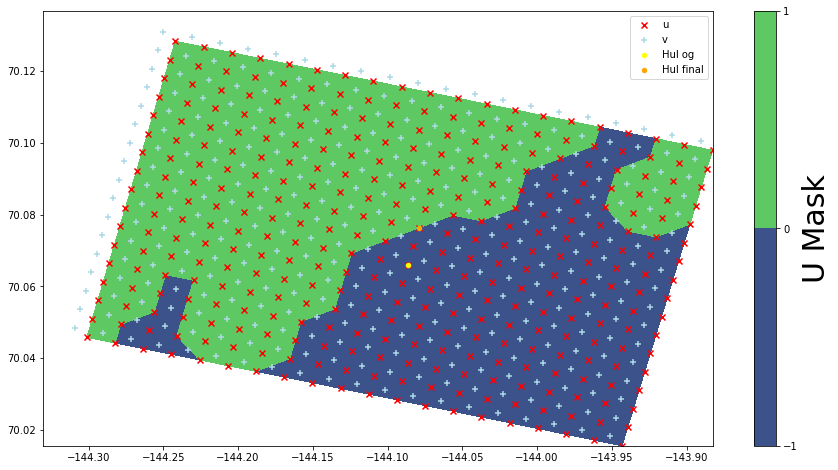

In [176]:
# Make a plot that is a scatter plot of u and v points
# Plot this point on the grid
# Zoom in to see if we are in the mask
fig2, ax2 = plt.subplots(figsize=(15,8))
# Plot the mask
cs2 = ax2.contourf(grid.lon_u[eta_hul_idx-7:eta_hul_idx+10, xi_hul_idx-10:xi_hul_idx+10].values, 
                    grid.lat_u[eta_hul_idx-7:eta_hul_idx+10, xi_hul_idx-10:xi_hul_idx+10].values, 
                    grid.mask_u[eta_hul_idx-7:eta_hul_idx+10, xi_hul_idx-10:xi_hul_idx+10].values, lev1)

# Plot the u points
ax2.scatter(grid.lon_u[eta_hul_idx-7:eta_hul_idx+10, xi_hul_idx-10:xi_hul_idx+10].values, 
            grid.lat_u[eta_hul_idx-7:eta_hul_idx+10, xi_hul_idx-10:xi_hul_idx+10].values,
            color='red', marker='x', label='u')

# Plot the v points
ax2.scatter(grid.lon_v[eta_hul_idx-7:eta_hul_idx+10, xi_hul_idx-10:xi_hul_idx+10].values, 
            grid.lat_v[eta_hul_idx-7:eta_hul_idx+10, xi_hul_idx-10:xi_hul_idx+10].values,
            color='lightblue', marker='+', label='v')


# Hulahula
ax2.scatter(grid.lon_u[eta_hul_idx, xi_hul_idx].values, grid.lat_u[eta_hul_idx, xi_hul_idx].values, 
            marker='.', s=80, color='yellow', label='Hul og')

# Point 1 - u face
eta_hul_idx_test1 = 40
xi_hul_idx_test1 = 489

ax2.scatter(grid.lon_u[eta_hul_idx_test1, xi_hul_idx_test1].values, 
            grid.lat_u[eta_hul_idx_test1, xi_hul_idx_test1].values, 
            marker='.', s=80, color='orange', label='Hul final')

ax2.legend()

cbar2 = plt.colorbar(cs2).set_label('U Mask', size=30)

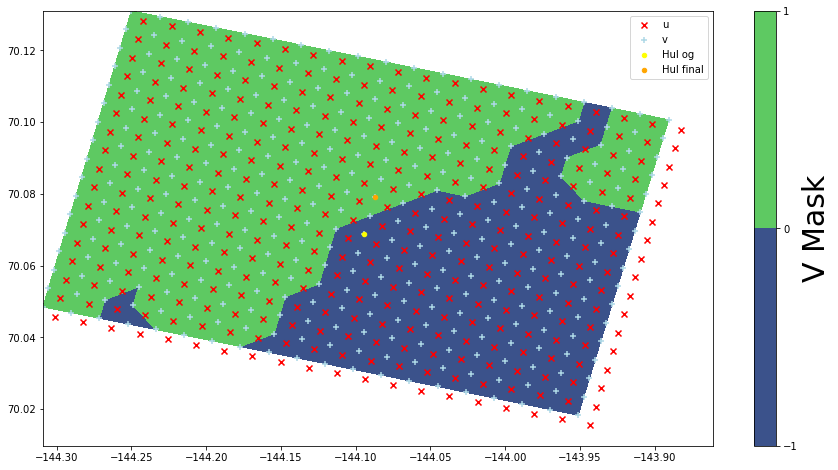

In [177]:
# NEW TO BE ON V AND NOT IN MASK

# Make a plot that is a scatter plot of u and v points
# Plot this point on the grid
# Zoom in to see if we are in the mask
fig2, ax2 = plt.subplots(figsize=(15,8))
# Plot the mask
cs2 = ax2.contourf(grid.lon_v[eta_hul_idx-7:eta_hul_idx+10, xi_hul_idx-10:xi_hul_idx+10].values, 
                    grid.lat_v[eta_hul_idx-7:eta_hul_idx+10, xi_hul_idx-10:xi_hul_idx+10].values, 
                    grid.mask_v[eta_hul_idx-7:eta_hul_idx+10, xi_hul_idx-10:xi_hul_idx+10].values, lev1)

# Plot the u points
ax2.scatter(grid.lon_u[eta_hul_idx-7:eta_hul_idx+10, xi_hul_idx-10:xi_hul_idx+10].values, 
            grid.lat_u[eta_hul_idx-7:eta_hul_idx+10, xi_hul_idx-10:xi_hul_idx+10].values,
            color='red', marker='x', label='u')

# Plot the v points
ax2.scatter(grid.lon_v[eta_hul_idx-7:eta_hul_idx+10, xi_hul_idx-10:xi_hul_idx+10].values, 
            grid.lat_v[eta_hul_idx-7:eta_hul_idx+10, xi_hul_idx-10:xi_hul_idx+10].values,
            color='lightblue', marker='+', label='v')


# Hulahula
ax2.scatter(grid.lon_v[eta_hul_idx, xi_hul_idx].values, grid.lat_v[eta_hul_idx, xi_hul_idx].values, 
            marker='.', s=80, color='yellow', label='Hul og')

# Point 1 - u face
eta_hul_idx_test1 = 40
xi_hul_idx_test1 = 489

ax2.scatter(grid.lon_v[eta_hul_idx_test1, xi_hul_idx_test1].values, 
            grid.lat_v[eta_hul_idx_test1, xi_hul_idx_test1].values, 
            marker='.', s=80, color='orange', label='Hul final')

ax2.legend()

cbar2 = plt.colorbar(cs2).set_label('V Mask', size=30)

In [178]:
# Check that these spots are in the mask
# Point 1 - u
print(grid.mask_u[eta_hul_idx_test1,xi_hul_idx_test1].values)
# If so, save it to the list of river indices (these indices are determined by the order in this notebook) = NOT robust
#eta_riv_arr[18] = eta_hul_idx_test1
#xi_riv_arr[18] = xi_hul_idx_test1

0.0


In [179]:
# Check that these spots are in the mask - NEW
# Point 1 - v
print(grid.mask_v[eta_hul_idx_test1,xi_hul_idx_test1].values)
# If so, save it to the list of river indices (these indices are determined by the order in this notebook) = NOT robust
eta_riv_arr[18] = eta_hul_idx_test1
xi_riv_arr[18] = xi_hul_idx_test1

1.0


In [180]:
# Set the river_direction
# "river runoff grid-cell face flag"
# where river_direction:flag_values = "0, 1, 2" 
# river_direction:flag_meanings = "flow across u-face, flow across v-face, flow across w-face"
#riv_dir_hul1 = 0 # OG
riv_dir_hul1 = 1 # NEW

# Add this to the list 
riv_direction_arr[18] = riv_dir_hul1

In [181]:
# Set river_transport which is the direction of the flow across the u or v face
# This is also where we put "river runoff vertically integrated mass transport"
# river_transport(river_time, river)

# Make a fake time series for each point
#Q_hul1 = np.full((time_tmp_len), -1000) # m3/s, negative for negative u direction -50

# Replace this fake time series with real data
Q_hul1 = (mean_river_dis.river_transport[182:307,11].values)/len_river_cells_hul

# Add this to the list 
riv_transport_arr[:,18] = Q_hul1

In [182]:
# Set river_vshape
# "sets the fractional distribution of the river_transport 
# among the vertical cells and must sum to 1.0 over the vertical"
# "If the river source is in shallow water several grid cells up a 
# river tributary then a simple uniform vertical distribution 
# (all river_Vshape values = 1/s_rho) usually works well"

# Do uniform distribution over all depths 
#riv_vshape_hul = np.full((s_rho_len), 1/s_rho_len)

# Read in the vshape for this cell
# Use the indices from above - these are u/v indices but v_shape 
# is n terms of rho indices but hopefully they are close enough 
# that it doesn't matter too much but keep note of this 
riv_vshape_hul = vshape_all[:, eta_hul_idx_test1, xi_hul_idx_test1]

# Add this to the array
riv_vshape_arr[:,18] = riv_vshape_hul

In [183]:
# Set river runoff potential temperature 
# river_temp(river_time, s_rho, river) 
# river_temp:long_name = "river runoff potential temperature" 
# river_temp:units = "Celsius" 
# river_temp:time = "river_time" 

# This looks like it can vary vertically and can be a timeseries 
#riv_temp_hul = np.full((time_tmp_len, s_rho_len), 11)
# Make this the same in each layer 
riv_temp_hul = np.empty((time_tmp_len, s_rho_len))
for i in range(s_rho_len):
    riv_temp_hul[:,i] = riv_temp

# Add this to the array 
riv_temp_arr[:,:,18] = riv_temp_hul

In [184]:
# Set the river runoff salinity
# river_salt(river_time, s_rho, river) 
# river_salt:long_name = "river runoff salinity" 
# river_salt:time = "river_time"
# units: PSS (nondimensional)

# Just like temp, this can vary vertically and over time
riv_salt_hul = np.full((time_tmp_len, s_rho_len), 0)

# Add this to the array
riv_salt_arr[:,:,18] = riv_salt_hul

In [185]:
# Set the river mud
# 'river_mud_'                                       ! Input
#   'river runoff suspended sediment concentration'
#   'kilogram meter-3'                               ! [kg/m3]
#   'river_sediment, scalar, series'
#   'river_time'

# --- Guesstimate Version ---
# # 10 kg/s / discharge m3/s = kg/m3, picking 10 as a random average 
# # for all rivers and all sediment classes
# # mud class 01
# riv_mud_01_hul = 10 / Q_hul1 # when there is real data, may need one for each cell
# #riv_mud_01_hul = np.full((time_tmp_len), 0.00001)

# # mud class 02
# riv_mud_02_hul = 10 / Q_hul1 # when there is real data, may need one for each cell
# #riv_mud_02_hul = np.full((time_tmp_len), 0.00001)

# --- Lamb and Toniolo 2016 Version ---
riv_mud_hul_tmp = calc_river_ssc(Q_hul1)
# Convert output from mg/L to kg/m3
riv_mud_hul = riv_mud_hul_tmp/1000

# Divide the total river sediment discharge by two 
# so that half belongs to each mud class
riv_mud_01_hul = riv_mud_hul/2
riv_mud_02_hul = riv_mud_hul/2

# Add these to the arrays (can definitely shorten this but oh well)
# mud 01
riv_mud_01_arr[:,18] = riv_mud_01_hul

# mud 02
riv_mud_02_arr[:,18] = riv_mud_02_hul

In [186]:
# Set the river sand
# 'river_sand_'                                      ! Input
#   'river runoff suspended sediment concentration'
#   'kilogram meter-3'                               ! [kg/m3]
#   'river_sediment, scalar, series'
#   'river_time'

# --- Guesstimate Version ---
# 10 kg/s / discharge m3/s = kg/m3, picking 10 as a random average 
# for all rivers and all sediment classes
# *Set all of these to 0 since sand might be too big to be carried by the river*

# sand class 01
riv_sand_01_hul = 0 / Q_hul1 # when there is real data, may need one for each cell
#riv_sand_01_hul = np.full((time_tmp_len), 0.0001)

# sand class 02
riv_sand_02_hul = 0 / Q_hul1 # when there is real data, may need one for each cell
#riv_sand_02_hul = np.full((time_tmp_len), 0.0001)

# sand class 03
riv_sand_03_hul = 0 / Q_hul1 # when there is real data, may need one for each cell
#riv_sand_03_hul = np.full((time_tmp_len), 0.0)

# Add this to the array
# sand 01 
riv_sand_01_arr[:,18] = riv_sand_01_hul

# sand 02
riv_sand_02_arr[:,18] = riv_sand_02_hul

# sand 03
riv_sand_03_arr[:,18] = riv_sand_03_hul

In [187]:
# Set the river id number
# This number will match the one in the info for the netcdf
# Hulahula
riv_id_hul = 12 #13

# Add this to the array
riv_id_arr[18] = riv_id_hul

In [188]:
# Set the river flag ('river runoff tracer flag')
# rdir.flag_values = '0, 1, 2, 3'
# rdir.flag_meanings = 'all tracers are off, only temperature is on, 
# only salinity is on, both temperature and salinity are on'
riv_flag_hul = 3

# Add this to the array
riv_flag_arr[18] = riv_flag_hul

## Jago River 
Location: 70.1088, -143.2918  
Width: 921 m

In [189]:
# Find this river in the mean discharge dataset
print(mean_river_dis.rivers)

(1) Kalikpik, (2) Fish Creek, (3) Colville, (4) Sakonowyak, (5) Kukpuk, (6) Kuparuk, (7) Putuligayuk, (8) Sagavanirktok, (9) Staines (10) Canning, (11) Katakturuk, (12) Hulahula, (13) Jago, (14) Siksik


In [190]:
# Jago River (70.1088, -143.2918), 921 m
# Set the number of cells it will take 
# 921 m / 750 m = 1.23 ~ 1 cells
len_river_cells_jag = 1

# Find it manually
eta_jag_idx = 58
xi_jag_idx = 527

# Needs to be on u or v point, depending what makes sense here
print('Jago Lat v: ', grid.lat_v[eta_jag_idx, xi_jag_idx].values)
print('Jago Lon v: ', grid.lon_v[eta_jag_idx, xi_jag_idx].values)

Jago Lat v:  70.10931742606864
Jago Lon v:  -143.3007382705922


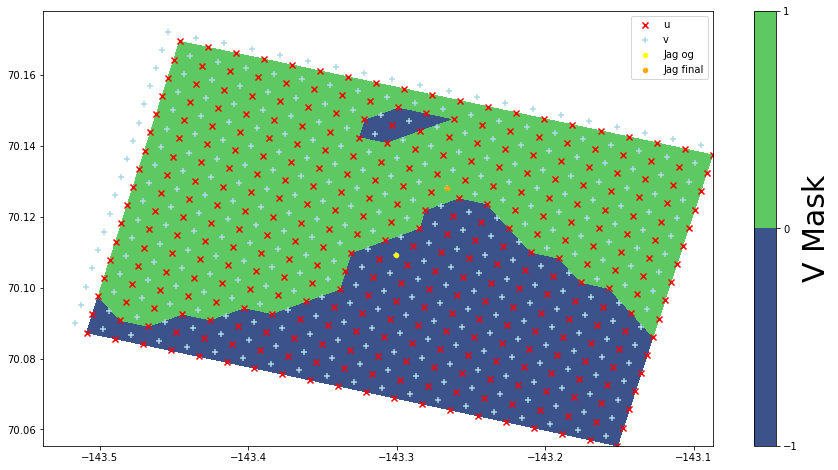

In [191]:
# Make a plot that is a scatter plot of u and v points
# Plot this point on the grid
# Zoom in to see if we are in the mask
fig2, ax2 = plt.subplots(figsize=(15,8))
# Plot the mask
cs2 = ax2.contourf(grid.lon_u[eta_jag_idx-7:eta_jag_idx+10, xi_jag_idx-10:xi_jag_idx+10].values, 
                    grid.lat_u[eta_jag_idx-7:eta_jag_idx+10, xi_jag_idx-10:xi_jag_idx+10].values, 
                    grid.mask_u[eta_jag_idx-7:eta_jag_idx+10, xi_jag_idx-10:xi_jag_idx+10].values, lev1)

# Plot the u points
ax2.scatter(grid.lon_u[eta_jag_idx-7:eta_jag_idx+10, xi_jag_idx-10:xi_jag_idx+10].values, 
            grid.lat_u[eta_jag_idx-7:eta_jag_idx+10, xi_jag_idx-10:xi_jag_idx+10].values,
            color='red', marker='x', label='u')

# Plot the v points
ax2.scatter(grid.lon_v[eta_jag_idx-7:eta_jag_idx+10, xi_jag_idx-10:xi_jag_idx+10].values, 
            grid.lat_v[eta_jag_idx-7:eta_jag_idx+10, xi_jag_idx-10:xi_jag_idx+10].values,
            color='lightblue', marker='+', label='v')


# Jago
ax2.scatter(grid.lon_v[eta_jag_idx, xi_jag_idx].values, grid.lat_v[eta_jag_idx, xi_jag_idx].values, 
            marker='.', s=80, color='yellow', label='Jag og')

# Point 1 - v face
eta_jag_idx_test1 = 62 #61
xi_jag_idx_test1 = 528

ax2.scatter(grid.lon_v[eta_jag_idx_test1, xi_jag_idx_test1].values, 
            grid.lat_v[eta_jag_idx_test1, xi_jag_idx_test1].values, 
            marker='.', s=80, color='orange', label='Jag final')

ax2.legend()

cbar2 = plt.colorbar(cs2).set_label('V Mask', size=30)

In [192]:
# Check that these spots are in the mask
# Point 1 - v
print(grid.mask_v[eta_jag_idx_test1,xi_jag_idx_test1].values)
# If so, save it to the list of river indices (these indices are determined by the order in this notebook) = NOT robust
eta_riv_arr[19] = eta_jag_idx_test1
xi_riv_arr[19] = xi_jag_idx_test1

1.0


In [193]:
# Set the river_direction
# "river runoff grid-cell face flag"
# where river_direction:flag_values = "0, 1, 2" 
# river_direction:flag_meanings = "flow across u-face, flow across v-face, flow across w-face"
# Set this for each of the 5 points
riv_dir_jag1 = 1

# Add this to the list 
riv_direction_arr[19] = riv_dir_jag1

In [194]:
# Set river_transport which is the direction of the flow across the u or v face
# This is also where we put "river runoff vertically integrated mass transport"
# river_transport(river_time, river)

# Make a fake time series for each point
#Q_jag1 = np.full((time_tmp_len), 1000) # m3/s # 10

# Replace this fake time series with real data
Q_jag1 = (mean_river_dis.river_transport[182:307,12].values)/len_river_cells_jag

# Add this to the list 
riv_transport_arr[:,19] = Q_jag1

In [195]:
# Set river_vshape
# "sets the fractional distribution of the river_transport 
# among the vertical cells and must sum to 1.0 over the vertical"
# "If the river source is in shallow water several grid cells up a 
# river tributary then a simple uniform vertical distribution 
# (all river_Vshape values = 1/s_rho) usually works well"

# Do uniform distribution over all depths 
#riv_vshape_jag = np.full((s_rho_len), 1/s_rho_len)

# Read in the vshape for this cell
# Use the indices from above - these are u/v indices but v_shape 
# is n terms of rho indices but hopefully they are close enough 
# that it doesn't matter too much but keep note of this 
riv_vshape_jag = vshape_all[:, eta_jag_idx_test1, xi_jag_idx_test1]

# Add this to the array
riv_vshape_arr[:,19] = riv_vshape_jag

In [196]:
# Set river runoff potential temperature 
# river_temp(river_time, s_rho, river) 
# river_temp:long_name = "river runoff potential temperature" 
# river_temp:units = "Celsius" 
# river_temp:time = "river_time" 

# This looks like it can vary vertically and can be a timeseries 
#riv_temp_jag = np.full((time_tmp_len, s_rho_len), 11)
# Make this the same in each layer 
riv_temp_jag = np.empty((time_tmp_len, s_rho_len))
for i in range(s_rho_len):
    riv_temp_jag[:,i] = riv_temp

# Add this to the array 
riv_temp_arr[:,:,19] = riv_temp_jag

In [197]:
# Set the river runoff salinity
# river_salt(river_time, s_rho, river) 
# river_salt:long_name = "river runoff salinity" 
# river_salt:time = "river_time"
# units: PSS (nondimensional)

# Just like temp, this can vary vertically and over time
riv_salt_jag = np.full((time_tmp_len, s_rho_len), 0)

# Add this to the array
riv_salt_arr[:,:,19] = riv_salt_jag

In [198]:
# Set the river mud
# 'river_mud_'                                       ! Input
#   'river runoff suspended sediment concentration'
#   'kilogram meter-3'                               ! [kg/m3]
#   'river_sediment, scalar, series'
#   'river_time'

# --- Guesstimate Version ---
# # 10 kg/s / discharge m3/s = kg/m3, picking 10 as a random average 
# # for all rivers and all sediment classes
# # mud class 01
# riv_mud_01_jag = 10 / Q_jag1 # when there is real data, may need one for each cell
# #riv_mud_01_jag = np.full((time_tmp_len), 0.00001)

# # mud class 02
# riv_mud_02_jag = 10 / Q_jag1 # when there is real data, may need one for each cell
# #riv_mud_02_jag = np.full((time_tmp_len), 0.00001)

# --- Lamb and Toniolo 2016 Version ---
riv_mud_jag_tmp = calc_river_ssc(Q_jag1)
# Convert output from mg/L to kg/m3
riv_mud_jag = riv_mud_jag_tmp/1000

# Divide the total river sediment discharge by two 
# so that half belongs to each mud class
riv_mud_01_jag = riv_mud_jag/2
riv_mud_02_jag = riv_mud_jag/2

# Add these to the arrays (can definitely shorten this but oh well)
# mud 01
riv_mud_01_arr[:,19] = riv_mud_01_jag

# mud 02
riv_mud_02_arr[:,19] = riv_mud_02_jag

In [199]:
# Set the river sand
# 'river_sand_'                                      ! Input
#   'river runoff suspended sediment concentration'
#   'kilogram meter-3'                               ! [kg/m3]
#   'river_sediment, scalar, series'
#   'river_time'

# --- Guesstimate Verison ---
# 10 kg/s / discharge m3/s = kg/m3, picking 10 as a random average 
# for all rivers and all sediment classes
# *Set all of these to 0 since sand might be too big to be carried by the river*

# sand class 01
riv_sand_01_jag = 0 / Q_jag1 # when there is real data, may need one for each cell
#riv_sand_01_jag = np.full((time_tmp_len), 0.0001)

# sand class 02
riv_sand_02_jag = 0 / Q_jag1 # when there is real data, may need one for each cell
#riv_sand_02_jag = np.full((time_tmp_len), 0.0001)

# sand class 03
riv_sand_03_jag = 0 / Q_jag1 # when there is real data, may need one for each cell
#riv_sand_03_jag = np.full((time_tmp_len), 0.0)

# Add this to the array
# sand 01 
riv_sand_01_arr[:,19] = riv_sand_01_jag

# sand 02
riv_sand_02_arr[:,19] = riv_sand_02_jag

# sand 03
riv_sand_03_arr[:,19] = riv_sand_03_jag

In [200]:
# Set the river id number
# This number will match the one in the info for the netcdf
# Jago
riv_id_jag = 13 #14

# Add this to the array
riv_id_arr[19] = riv_id_jag

In [201]:
# Set the river flag ('river runoff tracer flag')
# rdir.flag_values = '0, 1, 2, 3'
# rdir.flag_meanings = 'all tracers are off, only temperature is on, 
# only salinity is on, both temperature and salinity are on'
riv_flag_jag = 3

# Add this to the array
riv_flag_arr[19] = riv_flag_jag

## Siksik River 
Location: 69.9501, -142.4938  
Width: 176.5 m

In [202]:
# Find this river in the mean discharge dataset
print(mean_river_dis.rivers)

(1) Kalikpik, (2) Fish Creek, (3) Colville, (4) Sakonowyak, (5) Kukpuk, (6) Kuparuk, (7) Putuligayuk, (8) Sagavanirktok, (9) Staines (10) Canning, (11) Katakturuk, (12) Hulahula, (13) Jago, (14) Siksik


In [203]:
# Siksik River (69.9501, -142.4938), 176.5 m
# Set the number of cells it will take 
# 176.5 m / 750 m = ~ 1 cells
len_river_cells_sik = 1

# Find it manually
eta_sik_idx = 43
xi_sik_idx = 573

# Needs to be on u or v point, depending what makes sense here
print('Siksik Lat u: ', grid.lat_u[eta_sik_idx, xi_sik_idx].values)
print('Siksik Lon u: ', grid.lon_u[eta_sik_idx, xi_sik_idx].values)

Siksik Lat u:  69.95016198717653
Siksik Lon u:  -142.49164069847996


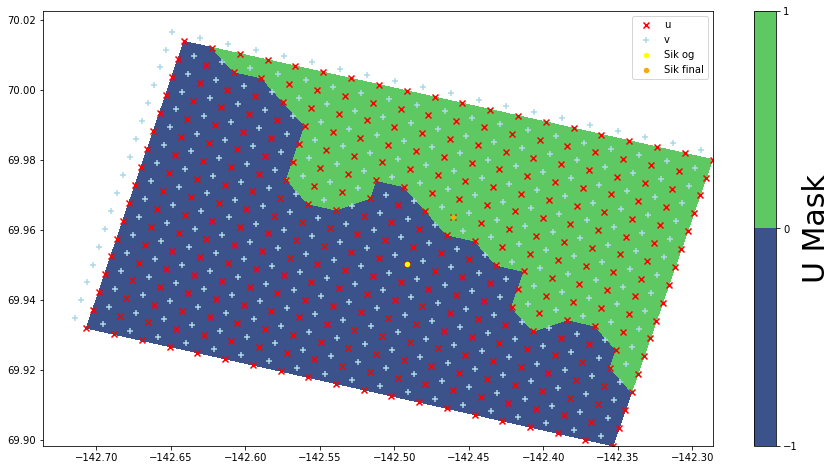

In [204]:
# Make a plot that is a scatter plot of u and v points
# Plot this point on the grid
# Zoom in to see if we are in the mask
fig2, ax2 = plt.subplots(figsize=(15,8))
# Plot the mask
cs2 = ax2.contourf(grid.lon_u[eta_sik_idx-7:eta_sik_idx+10, xi_sik_idx-10:xi_sik_idx+10].values, 
                    grid.lat_u[eta_sik_idx-7:eta_sik_idx+10, xi_sik_idx-10:xi_sik_idx+10].values, 
                    grid.mask_u[eta_sik_idx-7:eta_sik_idx+10, xi_sik_idx-10:xi_sik_idx+10].values, lev1)

# Plot the u points
ax2.scatter(grid.lon_u[eta_sik_idx-7:eta_sik_idx+10, xi_sik_idx-10:xi_sik_idx+10].values, 
            grid.lat_u[eta_sik_idx-7:eta_sik_idx+10, xi_sik_idx-10:xi_sik_idx+10].values,
            color='red', marker='x', label='u')

# Plot the v points
ax2.scatter(grid.lon_v[eta_sik_idx-7:eta_sik_idx+10, xi_sik_idx-10:xi_sik_idx+10].values, 
            grid.lat_v[eta_sik_idx-7:eta_sik_idx+10, xi_sik_idx-10:xi_sik_idx+10].values,
            color='lightblue', marker='+', label='v')


# Siksik
ax2.scatter(grid.lon_u[eta_sik_idx, xi_sik_idx].values, grid.lat_u[eta_sik_idx, xi_sik_idx].values, 
            marker='.', s=80, color='yellow', label='Sik og')

# Point 1 - v face
eta_sik_idx_test1 = 46
xi_sik_idx_test1 = 574 #573

ax2.scatter(grid.lon_u[eta_sik_idx_test1, xi_sik_idx_test1].values, 
            grid.lat_u[eta_sik_idx_test1, xi_sik_idx_test1].values, 
            marker='.', s=80, color='orange', label='Sik final')

ax2.legend()

cbar2 = plt.colorbar(cs2).set_label('U Mask', size=30)

In [205]:
# Check that these spots are in the mask
# Point 1 - u
print(grid.mask_u[eta_sik_idx_test1,xi_sik_idx_test1].values)
# If so, save it to the list of river indices (these indices are determined by the order in this notebook) = NOT robust
eta_riv_arr[20] = eta_sik_idx_test1
xi_riv_arr[20] = xi_sik_idx_test1

1.0


In [206]:
# Set the river_direction
# "river runoff grid-cell face flag"
# where river_direction:flag_values = "0, 1, 2" 
# river_direction:flag_meanings = "flow across u-face, flow across v-face, flow across w-face"
# Set this for each of the 5 points
riv_dir_sik1 = 0

# Add this to the list 
riv_direction_arr[20] = riv_dir_sik1

In [207]:
# Set river_transport which is the direction of the flow across the u or v face
# This is also where we put "river runoff vertically integrated mass transport"
# river_transport(river_time, river)

# Make a fake time series for each point
#Q_sik1 = np.full((time_tmp_len), 1000) # m3/s # 5

# Replace this fake time series with real data
Q_sik1 = (mean_river_dis.river_transport[182:307,13].values)/len_river_cells_sik

# Add this to the list 
riv_transport_arr[:,20] = Q_sik1

In [208]:
# Set river_vshape
# "sets the fractional distribution of the river_transport 
# among the vertical cells and must sum to 1.0 over the vertical"
# "If the river source is in shallow water several grid cells up a 
# river tributary then a simple uniform vertical distribution 
# (all river_Vshape values = 1/s_rho) usually works well"

# Do uniform distribution over all depths 
#riv_vshape_sik = np.full((s_rho_len), 1/s_rho_len)

# Read in the vshape for this cell
# Use the indices from above - these are u/v indices but v_shape 
# is n terms of rho indices but hopefully they are close enough 
# that it doesn't matter too much but keep note of this 
riv_vshape_sik = vshape_all[:, eta_sik_idx_test1, xi_sik_idx_test1]

# Add this to the array
riv_vshape_arr[:,20] = riv_vshape_sik

In [209]:
# Set river runoff potential temperature 
# river_temp(river_time, s_rho, river) 
# river_temp:long_name = "river runoff potential temperature" 
# river_temp:units = "Celsius" 
# river_temp:time = "river_time" 

# This looks like it can vary vertically and can be a timeseries 
#riv_temp_sik = np.full((time_tmp_len, s_rho_len), 11)
# Make this the same in each layer 
riv_temp_sik = np.empty((time_tmp_len, s_rho_len))
for i in range(s_rho_len):
    riv_temp_sik[:,i] = riv_temp

# Add this to the array 
riv_temp_arr[:,:,20] = riv_temp_sik

In [210]:
# Set the river runoff salinity
# river_salt(river_time, s_rho, river) 
# river_salt:long_name = "river runoff salinity" 
# river_salt:time = "river_time"
# units: PSS (nondimensional)

# Just like temp, this can vary vertically and over time
riv_salt_sik = np.full((time_tmp_len, s_rho_len), 0)

# Add this to the array
riv_salt_arr[:,:,20] = riv_salt_sik

In [211]:
# Set the river mud
# 'river_mud_'                                       ! Input
#   'river runoff suspended sediment concentration'
#   'kilogram meter-3'                               ! [kg/m3]
#   'river_sediment, scalar, series'
#   'river_time'

# --- Guesstimate Version ---
# # 10 kg/s / discharge m3/s = kg/m3, picking 10 as a random average 
# # for all rivers and all sediment classes
# # mud class 01
# riv_mud_01_sik = 10 / Q_sik1 # when there is real data, may need one for each cell
# #riv_mud_01_sik = np.full((time_tmp_len), 0.00001)

# # mud class 02
# riv_mud_02_sik = 10 / Q_sik1 # when there is real data, may need one for each cell
# #riv_mud_02_sik = np.full((time_tmp_len), 0.00001)

# --- Lamb and Toniolo 2016 Version ---
riv_mud_sik_tmp = calc_river_ssc(Q_sik1)
# Convert output from mg/L to kg/m3
riv_mud_sik = riv_mud_sik_tmp/1000

# Divide the total river sediment discharge by two 
# so that half belongs to each mud class
riv_mud_01_sik = riv_mud_sik/2
riv_mud_02_sik = riv_mud_sik/2

# Add these to the arrays (can definitely shorten this but oh well)
# mud 01
riv_mud_01_arr[:,20] = riv_mud_01_sik

# mud 02
riv_mud_02_arr[:,20] = riv_mud_02_sik

In [212]:
# Set the river sand
# 'river_sand_'                                      ! Input
#   'river runoff suspended sediment concentration'
#   'kilogram meter-3'                               ! [kg/m3]
#   'river_sediment, scalar, series'
#   'river_time'

# --- Guesstimate Version ---
# 10 kg/s / discharge m3/s = kg/m3, picking 10 as a random average 
# for all rivers and all sediment classes
# *Set all of these to 0 since sand might be too big to be carried by the river*

# sand class 01
riv_sand_01_sik = 0 / Q_sik1 # when there is real data, may need one for each cell
#riv_sand_01_sik = np.full((time_tmp_len), 0.0001)

# sand class 02
riv_sand_02_sik = 0 / Q_sik1 # when there is real data, may need one for each cell
#riv_sand_02_sik = np.full((time_tmp_len), 0.0001)

# sand class 03
riv_sand_03_sik = 0 / Q_sik1 # when there is real data, may need one for each cell
#riv_sand_03_sik = np.full((time_tmp_len), 0.0)

# Add this to the array
# sand 01 
riv_sand_01_arr[:,20] = riv_sand_01_sik

# sand 02
riv_sand_02_arr[:,20] = riv_sand_02_sik

# sand 03
riv_sand_03_arr[:,20] = riv_sand_03_sik

In [213]:
# Set the river id number
# This number will match the one in the info for the netcdf
# Siksik
riv_id_sik = 14 #15

# Add this to the array
riv_id_arr[20] = riv_id_sik

In [214]:
# Set the river flag ('river runoff tracer flag')
# rdir.flag_values = '0, 1, 2, 3'
# rdir.flag_meanings = 'all tracers are off, only temperature is on, 
# only salinity is on, both temperature and salinity are on'
riv_flag_sik = 3

# Add this to the array
riv_flag_arr[20] = riv_flag_sik

## Make the NetCDF

In [ ]:
# Make the netcdf
# Name of the netcdf file. This is up to you.
file_name = '/Users/brun1463/Desktop/Research_Lab/Kaktovik_Alaska_2020/Model_Inputs/Forcing_files/river_forcing_file_kaktovik_shelf_radr_data_2020_002.nc'

# Create and write to a netcdf file
nc = Dataset(file_name, 'w', format='NETCDF4')

# Create a variable for grid mapping
gridmap_varname = 'grid_mapping'

# Global attributes-- the dictionary.
global_defaults = dict(rivers      = '(1) Kalikpik River, (2) Colville River, (3) Sagavanirktok, (4) Fish Creek, (5) Sakonowyak, (6) Kukpuk' +
                       ' (7) Kuparuk, (8) Putuligayuk, (9) Staines, (10) Canning, (11) Katakturuk, (12) Hulahula, (13) Jago,' + 
                       ' (14) Siksik',
                       title       = 'River Discharge Interpolated to Kaktovik Shelf Grid', 
                       type        = 'ROMS river input file',
                       Institution = 'University of Colorado Boulder, Dept. of Atmospheric and Oceanic Sciences',
                       Source      = 'Artifical (for now)',
                       date        =  str(datetime.today()))

# Create dictionary for model
d = {}
d = global_defaults

# print d
for att, value in d.items():
    setattr(nc, att, value)

In [ ]:
# Create the dimensions
nc.createDimension('river_time', None)
nc.createDimension('s_rho',  s_rho_len)
nc.createDimension('river',  len_river_cells) #is this right?

In [ ]:
#nc.close()
#print(np.shape(riv_transport_list))

In [ ]:
# Create the variables
# River_time
river_time = nc.createVariable('river_time', 'd', ('river_time'), zlib=True)
river_time.long_name = 'river runoff time'
river_time.units = 'seconds since 2000-01-01 00:00:00'
river_time[:] = time_tmp[:]

# River
river = nc.createVariable('river', 'd', ('river'), zlib=True)
river.long_name = 'river runoff identification number'
river[:] = riv_id_arr[:]

# River_direction
rdir = nc.createVariable('river_direction', 'd', ('river'), zlib=True)
rdir.long_name = 'river runoff grid-cell face flag'
rdir.flag_values = '0, 1, 2'
rdir.flag_meanings = 'flow across u-face, flow across v-face, flow across w-face'
rdir[:] = riv_direction_arr[:]
#rdir[:] = np.full(num_river_cells, river_dir)


# Position of each river cell in the xi-direction
xpos = nc.createVariable('river_Xposition', 'd', ('river'), zlib=True)
xpos.long_name = 'river XI-position'
xpos.LuvSrc = 'T'
xpos.LuvSrc_meaning = 'i-index grid-cell of u- or v-face source/sink'
xpos.LwSrc_meaning = 'i-index grid-cell of w-face source/sink'
xpos[:] = xi_riv_arr[:]
#xpos[:] = river_cells_xi[:]

# Position of each river cell in the eta-direction
epos = nc.createVariable('river_Eposition', 'd', ('river'), zlib=True)
epos.long_name = 'river ETA-position'
epos.LuvSrc_True_meaning = 'j-index grid-cell of u- or v-face source/sink'
epos.LwSrc_True_meaning = 'j-index grid-cell of w-face source/sink'
epos[:] = eta_riv_arr[:]
#epos[:] = river_cells_eta[:]

# River_Vshape
vshape = nc.createVariable('river_Vshape', 'd', ('s_rho', 'river'), zlib=True)
vshape.long_name = 'river runoff mass transport vertical profile'
vshape.requires = 'must sum to 1 over s_rho coordinate'
vshape[:] = riv_vshape_arr[:,:]
#vshape[:,:] = Vshape_frac[:,:]

# River_transport
transport = nc.createVariable('river_transport', 'd', ('river_time', 'river'), zlib=True)
transport.long_name = 'river runoff vertically integrated mass transport'
transport.units = 'meter3 second-1'
transport.positive = 'LuvSrc=T flow in positive u,v direction, LwSrc=T flow into grid-cell'
transport.negative = 'LuvSrc=T flow in negative u,v direction, LwSrc=T flow out of grid-cell'
transport.time = 'river_time'
transport[:,:] = riv_transport_arr[:,:]
#transport[:,:] = Q_roms[:,:]

# River_temp
temp = nc.createVariable('river_temp', 'd', ('river_time', 's_rho', 'river'), zlib=True)
temp.long_name = 'river runoff potential temperature'
temp.units = 'Celsius'
temp.time = 'river_time'
temp[:,:,:] = riv_temp_arr[:,:,:]
#temp[:,:,:] = river_temp_roms[:,:,:]

# River_salt
salt = nc.createVariable('river_salt', 'd', ('river_time', 's_rho', 'river'), zlib=True)
salt.long_name = 'river runoff salinity'
salt.time = 'river_time'
salt[:,:,:] = riv_salt_arr[:,:,:]
#salt[:,:,:] = salt_roms[:,:,:]

# River mud 01
mud_01 = nc.createVariable('river_mud_01', 'd', ('river_time', 'river'), zlib=True)
mud_01.long_name = 'river runoff suspended sediment concentration'
mud_01.time = 'river_time'
mud_01.units = 'kilogram meter-3'
mud_01[:,:] = riv_mud_01_arr[:,:]

# River mud 02
mud_02 = nc.createVariable('river_mud_02', 'd', ('river_time', 'river'), zlib=True)
mud_02.long_name = 'river runoff suspended sediment concentration'
mud_02.time = 'river_time'
mud_02.units = 'kilogram meter-3'
mud_02[:,:] = riv_mud_02_arr[:,:]

# River sand 01
sand_01 = nc.createVariable('river_sand_01', 'd', ('river_time', 'river'), zlib=True)
sand_01.long_name = 'river runoff suspended sediment concentration'
sand_01.time = 'river_time'
sand_01.units = 'kilogram meter-3'
sand_01[:,:] = riv_sand_01_arr[:,:]

# River sand 02
sand_02 = nc.createVariable('river_sand_02', 'd', ('river_time', 'river'), zlib=True)
sand_02.long_name = 'river runoff suspended sediment concentration'
sand_02.time = 'river_time'
sand_02.units = 'kilogram meter-3'
sand_02[:,:] = riv_sand_02_arr[:,:]

# River sand 03
sand_03 = nc.createVariable('river_sand_03', 'd', ('river_time', 'river'), zlib=True)
sand_03.long_name = 'river runoff suspended sediment concentration'
sand_03.time = 'river_time'
sand_03.units = 'kilogram meter-3'
sand_03[:,:] = riv_sand_03_arr[:,:]

# River_flag
flag = nc.createVariable('river_flag', 'd', ('river'), zlib=True)
flag.long_name = 'river runoff tracer flag'
flag.flag_values = '0, 1, 2, 3'
flag.flag_meanings = 'all tracers are off, only temperature is on, only salinity is on, both temperature and salinity are on'
flag[:] = riv_flag_arr[:]
#flag[:] = np.full(num_river_cells, 0)

nc.close()
print('done')

In [ ]:
#nc.close()

# --------------------------------------- Start Tina's --------------------------------------

# Create a ROMS forcing file for river discharge using USGS data
OG: There are three main rivers that discharge near Kaktovik Lagoon, Alaska: 1) the Hulahula River, 2) the Okpilak River, and the 3) Jago River. The Hulahula River is guaged by the United States Geological Survey (USGS), with daily discharge measurements since May 23 2011 and drainage area (https://waterdata.usgs.gov/monitoring-location/15980000/#parameterCode=00065&period=P7D). The Okpilak and the Jago rivers are unguaged, so we will estimate their basin areas and inflow using the drainage area ratio and Hulahula data. To do this, we assume that all basins have similar precipitation, relief, geology.  

### Set-up

In [ ]:
# Import packages
import pandas as pd
import matplotlib.pyplot as plt
import datetime
from depths import *
from netCDF4 import Dataset
import numpy as np
import xarray as xr
import cmocean as cm

In [ ]:
# Assign values to the vertical parameteres
Vtransform = 2
Vstretching = 3
theta_s = 1
theta_b = 2
hc = 5
N = 20   # number of vertical layers

In [ ]:
## Read in the model grid
model_grid = xr.open_dataset('/Users/brun1463/Desktop/Research_Lab/Kaktovik_Alaska/Code/KakAKgrd_shelf_big010_smooth006.nc')
#rotation_angle = ?
rotation_angle = np.rad2deg(model_grid.angle[0,0].values)

# Save the dimension lengths into ROMS recognized variables, Mp and Lp
Mp = len(model_grid.eta_rho) # length of the eta-dimension
Lp = len(model_grid.xi_rho) # length of the xi-dimension

# Check dimension shapes
print('eta_len: ', Mp)
print('xi_len: ', Lp)

# Save latitude and longitude
lat_tmp = model_grid.lat_rho.values
lon_tmp = model_grid.lon_rho.values

# Save the length of length of latitude and longitude
lat_len = len(model_grid.lat_rho)
lon_len = len(model_grid.lon_rho)

In [ ]:
# TEMP
print(np.shape(model_grid.eta_rho))
print(np.shape(model_grid.xi_rho))

In [ ]:
np.degrees(model_grid.angle.data)

### 1 Get Hulahula River discharge
**Data Description**
<br>*Source:* USGS Water Resources (https://www.usgs.gov/mission-areas/water-resources)
<br>*Station Info:* Hulahula River near Kaktovik, AK (station 15980000).
<br>*Time Period:* 2019
<br>*Variable downloaded:* discharge (units: cubic feet per second, cfs)
<br><br>Link: https://nwis.waterdata.usgs.gov/nwis/dv?cb_00060=on&format=html&site_no=15980000&referred_module=sw&period=&begin_date=2019-01-01&end_date=2019-12-31


**Data preparation**
The data is averaged over a day. Discharge is converted from cfs to m3/s.

**Extra:**
Data is also downloaded for the Mackenzie River to the east in Canada and the Colville River to the west. Daily discharge for the Colville River at Kettle Falls, WA(station 12409000) was downloaded from USGS Water Resources (https://waterdata.usgs.gov/nwis/uv?site_no=12409000, last access: 7 June 2022). Daily discharge for the Mackenzie River at the Arctic Red River junction (station 10LC014) was downloaded from the government of Canada (https://wateroffice.ec.gc.ca/search/historical_e.html, last access: 23 June 2022).

In [ ]:
## Hulahula River discharge
rdata = pd.read_csv('/Users/brun1463/Desktop/Research_Lab/Kaktovik_Alaska/River_forcing_files/data/hulahulaDischarge.csv') # UPDATE PATH
rdata.datetime = pd.to_datetime(rdata.datetime)
rdata = rdata.set_index('datetime')
rdata = rdata[rdata.index.year==2019]
rdata = rdata.resample('1D').mean()
rdata.discharge = rdata.discharge * 0.028316847 # in m3/s


## Colville River discharge 
keys=['agency','site_no', 'datetime', 'timezone', 'discharge', 'qual_code']
cdata = pd.read_csv('/Users/brun1463/Desktop/Research_Lab/Kaktovik_Alaska/River_forcing_files/data/colvilleDischarge.csv', header=None,names=keys) # UPDATE PATH
cdata.datetime = pd.to_datetime(cdata.datetime)
cdata = cdata.set_index('datetime')
cdata = cdata[cdata.index.year==2019]
cdata = cdata.resample('1D').mean()
cdata.discharge = cdata.discharge * 0.028316847 # in m3/s

## Mackenzie River discharge (for comparison)
mdata = pd.read_csv('/Users/brun1463/Desktop/Research_Lab/Kaktovik_Alaska/River_forcing_files/data/mackenzieDischarge.csv', header=1) # UPDATE PATH
# Daily Discharge (m3/s) (PARAM = 1) and Daily Water Level (m) (PARAM = 2)
mdata = mdata[mdata.PARAM==1]
mdata['Date'] = pd.to_datetime(mdata['Date'])
mdata = mdata[mdata.Date.dt.year==2019]
mdata = mdata.set_index('Date')
mdata = mdata.resample('1D').mean()

## Canning River discharge (unsure...)


## Kuparuk River discharge (USGS)


## Sagavanirktok River discharge (USGS)


# # Source: BLE LTER
# # Data from: https://portal.edirepository.org/nis/mapbrowse?packageid=knb-lter-ble.3.1
# # Contains hourly measurements for Elson Lagoon, Kaktovik Lagoon, and Jago Lagoon

# LTER = pd.read_csv('BLE_LTER_hydrography_CTD.csv')
# LTER['datetime'] = pd.to_datetime(LTER.date_time)
# LTER = LTER[LTER.datetime.dt.year==2019]
# LTER = LTER.set_index('datetime')

# kak1 = LTER[LTER.station=='KALD1']
# kak1 = kak1.resample('1D').mean()

# kak2 = LTER[LTER.station=='KALD2']
# kak2 = kak2.resample('1D').mean()

**Preview river discharge and compare the Hulahula River to the nearby Mackenzie River in northern Canada and the Colville River in northern Alaska.**

In [ ]:
fig, ax = plt.subplots(nrows=2, figsize=(12,5), sharex=True)
plt.suptitle('discharge (m3/s)', fontsize=15)
ax[0].plot(mdata.Value, color='k', linewidth=1, label='Mackenzie River', alpha=0.5)
ax[0].plot(rdata.discharge, color='#759EB8', linewidth=3, label='Hulahula River')
ax[0].set_xlim(mdata.index[0],mdata.index[-1])
ax[0].set_ylim(-1000,20000)
ax[0].legend()

ax[1].plot(cdata.discharge, color='k',linewidth=1, label='Colville River', alpha=0.5)
ax[1].plot(rdata.discharge, color='#759EB8', linewidth=3, label='Hulahula River')
ax[1].set_xlabel('months in 2019')
ax[1].set_xlim(mdata.index[0],mdata.index[-1])
ax[1].set_ylim(-10,300)
ax[1].legend();

### 2 Estimate drainage area for the Okpilak and Jago rivers
Here, we estimate the Okpilak and Jago drainage area from the Hulahula's (687 $mi^{2}$ (~1779 $km^{2}$)).
<br><br>
The gauge is upstream of the river mouth, so the actual inflow at the river mouth is larger than the measured value at the guage. We are currently not doing this, but we may increase the basin area to account for the area between the gauage and the river mouth. **Again, scaling is currently not used.**

In [ ]:
# Hulahula drainage basin area from USGS in square miles
hula_drainage_area_USGS = 687 # mi2
hula_area = round((hula_drainage_area_USGS*2.58999),2) # convert mi2 to km2 for our use

# Estimate the Okpilak drainage area from the new Hulahula drainage area
okpilak_scale = 0.67 # value you want to scale by (here ~1/3)
okpilak_area = round(hula_area*okpilak_scale,2) # estimate the okpilak drainage area

# Estimate the Jago drainage area from the new Hulahula drainage area 
jago_scale = 0.85 # value you want to scale by (here ~85%)
jago_area = round(hula_area*jago_scale,2) # estimate the jago drainage area

# check the areas in km^2
print('Hulahula River Basin:', hula_area)
print('Okpilak River Basin:', okpilak_area)
print('Jago River Basin:', jago_area)

### 3 Calculate river discharge for the Okpilak River and Jago River.
**Summary of methods I've come across in literature:**
1. Drainage area ratio. Hortness (2006) recommends that this approach be used when the ratio of drainage areas is between 0.5 and 1.5.
2. Maintenance of variance extension method (Hirsh, 1979)
3. Nonlinear spatial interpolation method (?).
4. Map-correlation method (Archfield and Vogel, 2010)

The drainage area ratio method is implemented here due to data availability. The equation used is: 
<br>$Q_u=\frac{A_u}{A_g}\times (Q_g)$
> where $Q_u$ is the daily streamflow at the ungauged river, $A_u$ is the drainage area of the ungauged river, $A_g$ is the drainage area of the reference river, the Hulahula River, and $Q_g$ is the daily streamflow at the gauged site.

In [ ]:
# Save time and discharge variables
time = rdata.index
dis_units = 'm3/s '
Q_hula = rdata.discharge # save Hulahula discharge to a new variable

# Use the drainage area ratio to estimate river discharge
Q_okpilak = (okpilak_area/hula_area) * Q_hula # estimate discharge for the Okpilak River
Q_jago = (jago_area/hula_area) * Q_hula # estimate discharge for the Jago River
Q_total = Q_hula+Q_jago+Q_okpilak # sum to get the total

# Check the drainage basin ratios:
print('okpilak/hulhula:', round((okpilak_area/hula_area),3),
      '\njago/hulahula:', round((jago_area/hula_area),3))

print('\nmaximum discharge:')
rdata[rdata.discharge==rdata.discharge.max()]

**Plot discharge for the Hulahula River, Okpilak River, and Jago River.**

In [ ]:
fig, ax = plt.subplots(figsize=(15,3)) # set up new figure
ax.plot(time, Q_total, color='#759EB8', linewidth=4) # total
# ax.plot(time, Q_hula, color='#56A3A6', linewidth=6, label='Hulahula Discharge', alpha=0.5) # Hulahula
# ax.plot(time, Q_jago, color='#4F6D7A',  linewidth=4, label='Jago Discharge') # Jago
# ax.plot(time, Q_okpilak, color='#E3B505', linewidth=3,  label='Okpilak Discharge') # Okpilak

# Format
# ax.set_xlabel('2019')
ax.set_ylabel('Discharge ($m3/s$)',fontsize=12)

ax.set_xlim(time[0], time[-1])
ax.set_ylim(0,801)
# plt.grid(True)
plt.legend();

### 4 Decide on the location of the river grid cells and calculate discharge per cell.
We will use our ROMS grid to decide where we want our river indices. The first part of the script is just set-up to create a more user-friendly plot. Then, play around with the indices until you're happy enough that they represent your rivers.
<br><br>
Where should these indices be located? They should be land cells that immediately boarder ocean (aka one side of this cell should be our "coastline"). If the river index is accidentally placed on land, the mask will remove these values and there won't be any freshwater influx. If an index is in the ocean, you will still get freshwater inflow but you will also get unrealistic hypersaline water inflow in the opposite direction due to salt conservation. With correct settings, this hypersaline water is masked out.

In [ ]:
#  Create the plot ---
def transformCoord(x_points, y_points, angle):
    x_rot = np.full_like(x_points, 1)
    y_rot = np.full_like(y_points, 1)
    
    for xi in range(np.shape(x_points)[0]):
        for yi in range(np.shape(x_points)[1]):
            vector=complex(x_points[xi,yi], y_points[xi,yi])  # vector = x+ sqrt(-1)*y
            rot_vec=vector*np.exp(complex(0.0 ,-np.radians(angle)))  #rot_vec=vector *e^(sqrt(-1)*ang_rad)
            
            x_rot[xi, yi] = rot_vec.real # save the real number, which is x
            y_rot[xi, yi] = rot_vec.imag # save the imaginary number, which is y
            
    return x_rot, y_rot

# Rotate the coordinates to create a straight plot
rot_x_rho, rot_y_rho = transformCoord(model_grid.x_rho, model_grid.y_rho, rotation_angle)

In [ ]:
## Create the plot:
fig, ax = plt.subplots(figsize=(15,4.2))
#ax.axis('equal')
# ax.invert_yaxis()
# ax.invert_xaxis()

# Plot bathymetry and outline land.
#cs1=ax.contourf(rot_x_rho, rot_y_rho, model_grid.h,cmap=cm.cm.ice_r, extend='max', alpha=0.5) # add bathymetry, mask topography
#ax.contour(rot_x_rho, rot_y_rho, model_grid.mask_rho, level=[0], cmap=cm.cm.ice_r, extend='max') # outline land
cs1=ax.contourf(model_grid.x_rho.values, model_grid.y_rho.values, model_grid.h,cmap=cm.cm.ice_r, extend='max', alpha=0.5) # add bathymetry, mask topography
ax.contour(model_grid.x_rho.values, model_grid.y_rho.values, model_grid.mask_rho, cmap=cm.cm.ice_r, extend='max') # outline land

# Format
ax.set_xlabel('Distance (km)', fontsize=12)
ax.set_ylabel('Distance (km)', fontsize=12)

# cbar = fig.colorbar(cs1, orientation='horizontal', aspect=30, pad=0.2) # add the colorbar under the fig that's thin (aspect) and pushed a bit further under the fig (pad)
# cbar.set_label(label='Depth (m)', size='large', labelpad=0.5) # add a large label 
# cbar.ax.invert_yaxis() # swap the colorbar so it begins with zero



## **Here are your indices:** (remeber: plot y,x)
#ax.plot(rot_x_rho[49, 114:127],  rot_y_rho[49, 114:127],  linewidth=5, color='#9C1407', label='Hulahula')
#ax.plot(rot_x_rho[49, 127:140],  rot_y_rho[49, 127:140],  linewidth=5, color='#F68E5F', label='Okpilak')
#ax.plot(rot_x_rho[161, 547:560], rot_y_rho[161, 547:560], linewidth=5, color='#EABB1F', label='Jago')
ax.plot(model_grid.x_rho[29, 114:127].values,  model_grid.y_rho[29, 114:127].values,  linewidth=5, color='#9C1407', label='Hulahula')
ax.plot(model_grid.x_rho[60, 515:518].values,  model_grid.y_rho[49, 515:518].values,  linewidth=5, color='#F68E5F', label='Okpilak')
ax.plot(model_grid.x_rho[60, 520:530].values, model_grid.y_rho[60, 520:530].values, linewidth=5, color='#EABB1F', label='Jago')

plt.legend();


In [ ]:
# Set arrays for the locations of the rivers
# Hulahula xi, eta, and number of cells (xi, eta)
hulahula_cells_xi  = np.arange(114, 127, 1) # xi array for Hulahula
hulahula_cells_eta = np.full(len(hulahula_cells_xi), 49) # eta array for Hulahula
num_hulahula_cols = len(hulahula_cells_xi) # amount of cells

# Okpilak xi, eta, and number of cells
okpilak_cells_xi  = np.arange(127, 140, 1)
okpilak_cells_eta = np.full(len(okpilak_cells_xi), 49)
num_okpilak_cols = len(okpilak_cells_xi)

# Jago xi, eta, and number of cells
jago_cells_xi  = np.arange(547, 560, 1)
jago_cells_eta = np.full(len(jago_cells_xi), 161)
num_jago_cols = len(jago_cells_xi)

# All river xi, eta, and number of cells
river_cells_xi  = np.concatenate((hulahula_cells_xi, okpilak_cells_xi, jago_cells_xi))
river_cells_eta =  np.concatenate((hulahula_cells_eta, okpilak_cells_eta, jago_cells_eta))
all_river_cells = np.arange(0, len(river_cells_xi+1), 1)
num_river_cells = len(all_river_cells)


## Divide the total discharge by the number of columns in river
Q_hula_per_col = Q_hula / num_hulahula_cols
Q_okpilak_per_col = Q_okpilak / num_okpilak_cols
Q_jago_per_col = Q_jago / num_jago_cols

## Tile river discharge for each river cell that defines that river
Q_hula_cells = np.tile(Q_hula_per_col, (num_hulahula_cols,1))
Q_okpilak_cells = np.tile(Q_okpilak_per_col, (num_okpilak_cols,1))
Q_jago_cells = np.tile(Q_jago_per_col, (num_jago_cols,1))

# Create a ROMS ready discharge variable in the shape: river_time, river (365, 39)
Q_roms = np.concatenate((Q_hula_cells, Q_okpilak_cells, Q_jago_cells)) # combine the river discharge
Q_roms = np.transpose(Q_roms) # corrects the shape
print(np.shape(Q_roms)) # check the shape

#### Set direction of water flow
<br>

Here, we're going to set where water is flowing out of our indices. Should it be moving left/right in your grid (u) or should it be moving up/down (v)? 
1. If you want it to move in the horizontally in the **u-direction**, set this value to **0**.
1. If you want it to move in the horizontally in the **v-direction**, set this value to **1**.
1. If you want it to move in the vertically in the **w-direction**, set this value to **2**.

If you choose the horizontal direction (u or v), set `LuvSrc=T` and `LwSrc=F` in the ROMS `.in.` file. If you choose ther vertical direction (w), set set `LuvSrc=F` and `LwSrc=T`. This will turn on freshwater inflow.
<br><br>
Finally, we need to set the *actual* direction it's moving. If it's moving up or right, you don't need to do anything. If it's moving down or left, multiply your discharge by $-1$.

In [ ]:
#    --(v+)--
#   |       |
# u(-)    u(+)
#  |       |
#  --(v-)--

river_dir = 1

# # If your flow is down or to the left:
# Q_roms = Q_roms*(-1)

### 5 Calculate the depth of each vertical layer in the grid to create the Vshape variable.
This script was created by Brianna Undzis at the University of Colorado Boulder in 2022. Here, it has been modified for Jupyter Notebook and adpated for these rivers, but the code otherwise remains the same. Our ROMS coordinates are xi ($\xi$) and eta ($\eta$).

In [ ]:
## Calculate vertically-integrated discharge 
## Calculate the fraction of discharge you want to come from each cell in each layer
#  We need the depths of each column to calculate rows, so let's save those
h_hula = model_grid.h.isel(xi_rho=slice(hulahula_cells_xi[0],hulahula_cells_xi[-1]+1)).isel(eta_rho=hulahula_cells_eta[0]).values
h_okpi = model_grid.h.isel(xi_rho=slice(okpilak_cells_xi[0],okpilak_cells_xi[-1]+1)).isel(eta_rho=okpilak_cells_eta[0]).values
h_jago =  model_grid.h.isel(xi_rho=slice(jago_cells_xi[0],jago_cells_xi[-1]+1)).isel(eta_rho=jago_cells_eta[0]).values

#  Find the depths of the rho points (shape: 7, 12)
zrho_hula = get_zrho(Vtransform, Vstretching, N, theta_s, theta_b, h_hula, hc) 
zrho_okpi = get_zrho(Vtransform, Vstretching, N, theta_s, theta_b, h_okpi, hc) 
zrho_jago = get_zrho(Vtransform, Vstretching, N, theta_s, theta_b, h_jago, hc) 


# Because we need the depths of each columns, rather than the locations of the rho points,
# we'll add the maximum depth to the rho depths to calculate the last difference
print(np.shape(zrho_hula))
zrho_w_bottom_hula = np.insert(zrho_hula, obj=0, values=-h_hula, axis=0) # should increase N by 1 (ex 7 to 8)
zrho_w_bottom_okpi = np.insert(zrho_okpi, obj=0, values=-h_okpi, axis=0) # should increase N by 1 (ex 7 to 8)
zrho_w_bottom_jago = np.insert(zrho_jago, obj=0, values=-h_jago, axis=0) # should increase N by 1 (ex 7 to 8)
print(np.shape(zrho_w_bottom_hula))

# Calculate the depth of each cell
cell_depths_hula = np.diff(zrho_w_bottom_hula, axis=0) # zrho_w_bottom[0,0]-zrho_w_bottom[1,0] at each cell in every col
cell_depths_okpi = np.diff(zrho_w_bottom_okpi, axis=0) 
cell_depths_jago = np.diff(zrho_w_bottom_jago, axis=0) 
print(np.shape(cell_depths_hula))

# Calculate the fraction that each cell takes up of the total column depth
# frac_col = cell_depths / zrho_w_bottom
frac_col_hula = cell_depths_hula / np.sum(cell_depths_hula[:,0])
frac_col_okpi = cell_depths_okpi / np.sum(cell_depths_okpi[:,0])
frac_col_jago = cell_depths_jago / np.sum(cell_depths_jago[:,0])
print(np.shape(frac_col_hula))

# This value must sum to 1 over the vertical
print(np.sum(frac_col_hula[:,-1]))
print(np.sum(frac_col_okpi[:,-1]))
print(np.sum(frac_col_jago[:,-1]))


# shape: s_rho, river (7, 36)
Vshape_frac = np.concatenate((frac_col_hula, frac_col_okpi, frac_col_jago), axis=1)
print(np.shape(Vshape_frac))

# zrho_w_bottom[:,0] # water column
# print(abs(zrho_w_bottom[0,0]) - abs(zrho_w_bottom[1,0]))
# print(abs(zrho_w_bottom[1,0]) - abs(zrho_w_bottom[2,0]))...

# np.shape(frac_col), np.shape(Q_hula_cells)

### 6 Prepare the river salinity variable.
Due to the limited amount of Arctic data, we will use the common assumption that the incoming freshwater has a salinity of 0 (unitless).

In [ ]:
# Salt 
salt_roms = np.full((len(time), N, num_river_cells), 0) # shape: 'river_time', 's_rho', 'river'
print(np.shape(salt_roms))

### 7 River temperature
There is little data about rivers in the Arctic, so long term monthly mean water temperature for the Mackenzie River was used as a proxy for all three rivers (Yang et al., 2014). The mean water temperatures by month are: January (0°C), February (0°C), March (0.5°C), April(0.1°C), May (6°C), June (12°C), July (16°C), August (15.5°C), September (9.7°C), October (2.5°C), November (0°C), December (0°C). **We may want to consider adjusting our river's temperature since they're smaller.**

**References**
<br>Yang, D., Marsh, P., & Ge, S. (2014). Heat flux calculations for Mackenzie and Yukon Rivers. Polar Science, 8(3), 232-241.

In [ ]:
# Month to month temperature. When done this way, our temperature averages align with the middle of the month.
J2F = np.full(45,0) # for 45 days, temperature is 0°C
F2M = np.linspace(0,0.5,30) # over 30 days, temperature increases from 0°C to 0.5°C
M2A = np.linspace(0.5, 0.1, 30) # over 30 days, temperature decreases from 0.5°C to 0.1°C
A2M = np.linspace(0.1, 6, 31) # over 31 days, temperature increases from 0.1°C to 6°C
M2J = np.linspace(6, 12, 30) # over 30 days, temperature increases from 6°C to 12°C
J2J = np.linspace(12, 16, 31) # over 31 days, temperature increases from 12°C to 16°C
J2A = np.linspace(16, 15.5, 31) # over 31 days, temperature decreases from 16°C to 15.5°C
A2S = np.linspace(15.5, 9.7, 30) # over 30 days, temperature decreases from 15.5°C to 9.7°C
S2O = np.linspace(9.7, 2.5, 31) # over 31 days, temperature decreases from 9.7°C to 2.5°C
O2N = np.linspace(2.5, 0.1, 30) # over 30 days, temperature decreases from 2.5°C to 0.1°C
N2D = np.full(46,0) # for 46 days, temperature is 0°C

river_temp = np.concatenate((J2F, F2M, M2A, A2M, M2J, J2J, J2A, A2S, S2O, O2N, N2D))
print('day check:', len(river_temp))

In [ ]:
# Plot river temperature
fig, ax = plt.subplots(figsize=(12,3))
ax.plot(river_temp, linewidth=2)
ax.set_xlim(1,12)
ax.set_ylim(0,20)
locs = np.linspace(0, len(river_temp), 12)
labs = np.arange(1,13,1)
ax.set_xticks(locs, labs)
ax.set_title('Arctic river temp based on Yang et al.(2014)', fontsize=15)
ax.set_xlabel('month', fontsize=14)
ax.set_ylabel('river temp (°C)', fontsize=14);

In [ ]:
# Prepare temperature file for ROMS (shape: # 'river_time', 's_rho', 'river')
river_temp_roms = np.tile(river_temp, (N,num_river_cells,1)).T
print(np.shape(river_temp_roms))

### 8 Create a time array for ROMS to start on July 1, 2019.

In [ ]:
# create a time dimension based on the imported dataset
day_start = 6574
start_date = time[0]
end_date = time[-1]

elapsed_time = (end_date - start_date).days + day_start

time_ROMS = np.linspace(day_start, elapsed_time, len(Q_hula), endpoint=True)
time_ROMS = np.squeeze(time_ROMS)
print(time_ROMS[0:5])

### 9 Create a ROMS Forcing File

In [ ]:
# Name of the netcdf file. This is up to you.
file_name = 'KakAK_river.nc'

# Create and write to a netcdf file
nc = Dataset(file_name, 'w', format='NETCDF4')

# Create a variable for grid mapping
gridmap_varname = 'grid_mapping'

# Global attributes-- the dictionary.
global_defaults = dict(rivers      = '(1) Hulahula River, (2) Okpilak River (3) Jago River',
                       title       = 'River Discharge Interpolated to Kaktovik Lagoon Grid', 
                       type        = 'ROMS river input file',
                       Institution = 'University of Colorado Boulder, Dept. of Atmospheric and Oceanic Sciences',
                       Source      = 'USGS (2019)',
                       date        =  str(datetime.date.today()))

# Create dictionary for model
d = {}
d = global_defaults

# print d
for att, value in d.items():
    setattr(nc, att, value)

Create the variables and the dimensions for the variables. Variable are created based on information from the ROMS wiki for river runoff. The dimensions are:
1. river_time
2. s_rho: number of vertical layers specified in the .in file
3. river: number of points represented by rivers in the 

<br>Source: https://www.myroms.org/wiki/River_Runoff#River_NetCDF_template

In [ ]:
## Create dimensions
nc.createDimension('river_time', None)
nc.createDimension('s_rho',  7)
nc.createDimension('river',  num_river_cells)


## Create the variables
#  river_time
time_roms = nc.createVariable('river_time', 'd', ('river_time'), zlib=True)
time_roms.long_name = 'river runoff time'
time_roms.units = 'days since 2001-01-01 00:00:00'
time_roms[:] = time_ROMS[:]

#  river
river = nc.createVariable('river', 'd', ('river'), zlib=True)
river.long_name = 'river runoff identification number'
river[:] = all_river_cells[:]

#  river_direction; all rivers here are moving through v
rdir = nc.createVariable('river_direction', 'd', ('river'), zlib=True)
rdir.long_name = 'river runoff grid-cell face flag'
rdir.flag_values = '0, 1, 2'
rdir.flag_meanings = 'flow across u-face, flow across v-face, flow across w-face'
rdir[:] = np.full(num_river_cells, river_dir)

#  position of each river cell in the xi-direction
xpos = nc.createVariable('river_Xposition', 'd', ('river'), zlib=True)
xpos.long_name = 'river XI-position'
xpos.LuvSrc = 'T'
xpos.LuvSrc_meaning = 'i-index grid-cell of u- or v-face source/sink'
# xpos.LwSrc_meaning = 'i-index grid-cell of w-face source/sink'
xpos[:] = river_cells_xi[:]

#  position of each river cell in the eta-direction
epos = nc.createVariable('river_Eposition', 'd', ('river'), zlib=True)
epos.long_name = 'river ETA-position'
epos.LuvSrc_True_meaning = 'j-index grid-cell of u- or v-face source/sink'
# epos.LwSrc_True_meaning = 'j-index grid-cell of w-face source/sink'
epos[:] = river_cells_eta[:]

#  river_Vshape
vshape = nc.createVariable('river_Vshape', 'd', ('s_rho', 'river'), zlib=True)
vshape.long_name = 'river runoff mass transport vertical profile'
vshape.requires = 'must sum to 1 over s_rho coordinate'
vshape[:,:] = Vshape_frac[:,:]

#  river_transport
transport = nc.createVariable('river_transport', 'd', ('river_time', 'river'), zlib=True)
transport.long_name = 'river runoff vertically integrated mass transport'
transport.units = 'meter3 second-1'
transport.positive = 'LuvSrc=T flow in positive u,v direction, LwSrc=T flow into grid-cell'
transport.negative = 'LuvSrc=T flow in negative u,v direction, LwSrc=T flow out of grid-cell'
transport.time = 'river_time'
transport[:,:] = Q_roms[:,:]

#  river_temp
temp = nc.createVariable('river_temp', 'd', ('river_time', 's_rho', 'river'), zlib=True)
temp.long_name = 'river runoff potential temperature'
temp.units = 'Celsius'
temp.time = 'river_time'
temp[:,:,:] = river_temp_roms[:,:,:]

#  river_salt
salt = nc.createVariable('river_salt', 'd', ('river_time', 's_rho', 'river'), zlib=True)
salt.long_name = 'river runoff salinity'
salt.time = 'river_time'
salt[:,:,:] = salt_roms[:,:,:]

#  river_flag
flag = nc.createVariable('river_flag', 'd', ('river'), zlib=True)
flag.long_name = 'river runoff tracer flag'
rdir.flag_values = '0, 1, 2, 3'
rdir.flag_meanings = 'all tracers are off, only temperature is on, only salinity is on, both temperature and salinity are on'
flag[:] = np.full(num_river_cells, 0)

nc.close()
print('done')

# Extra: Chlorophyll

Chlorophyll looks nice plotted against river discharge. The code to load in and plot chlorophyll is included below.

In [ ]:
## Load in

# chl_file = pd.read_csv('NASA_chlorophyll.csv')
# chl = chl_file.drop([0])
# chl.time = pd.to_datetime(chl.time)- pd.to_timedelta(7, unit='d')
# chl = chl.set_index(chl.time)
# chl.chlorophyll = pd.to_numeric(chl.chlorophyll)

# chl_weekly = chl.resample('1M').sum()
# time_weekly = chl.time.resample('1M')

## Plot
#  ax1 = ax.twinx() 
# ax1.plot(chl_weekly.chlorophyll, color='#72A98F', linewidth=15, alpha=0.5)
# ax1.set_ylabel('Chlorophyll mg m-3', color='#72A98F')
# ax1.set_ylim(0,)
# ax1.tick_params(axis='y',labelcolor='#72A98F',size=10)

# plt.tick_params(bottom=False,left=False)
# plt.xlim('2019-01', '2020-01')
# fig.tight_layout();


**Helpful info from depths module documentation:**
<br> get_Vstretching_1:
- If theta_b=0, the refinement is surface intensified as theta_s is increased.
- If theta_b=1, the refinement is both bottom and surface intensified as theta_s is increased.

get_Vstretching_3: intended for very shallow coastal applications, like gravity sediment flows.
- theta_s: surface stretching exponent (0.65 is minimal, 1 is significant amplification)
- theta_b: bottom stretching exponent (0.58 is no amplification, 1 is significant amplication, 3 is super-high)